In [ ]:
#@title Import packages
%pip install scikit-optimize
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import LabelBinarizer
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet, Lasso
from sklearn.preprocessing import MinMaxScaler
from skopt import BayesSearchCV
import matplotlib.pyplot as plt
from itertools import cycle
from xgboost import XGBRegressor
from sklearn.linear_model import RidgeCV, Ridge
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import KFold
import seaborn as sns
from sklearn import metrics
import statsmodels.api as sm
import time
import scipy
from sklearn.metrics import mean_squared_error, r2_score
import math

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.9 MB/s eta 0:00:00


In [ ]:
#@title Functions and methods for Ridge Regression

def coef_pval(coef_array_mean_, X_, y_, y_p):

    n = X_.shape[0]
    t = coef_tval(coef_array_mean_, X_, y_, y_p)
    p = 2 * (1 - scipy.stats.t.cdf(abs(t), n - 1))
    return p


def coef_tval(coef_array_mean_, X_, y_, y_p):

    '''
        coef_tval for OLS of statsmodels
    '''

    a = np.array(coef_array_mean_[0][0]/ coef_se(X_, y_, y_p)[0])
    b = np.array(coef_array_mean_[1::].flatten() / coef_se(X_, y_, y_p)[1:])
    return np.append(a, b)


def coef_se(X_, y_, y_p):

    '''
        coef_se for OLS of statsmodels
    '''
    n = X_.shape[0]

    X1 = np.hstack((np.ones((n, 1)), np.matrix(X_)))
    se_matrix = scipy.linalg.sqrtm(
        metrics.mean_squared_error(y_, y_p) *
        np.linalg.inv(X1.T * X1)
    )
    return np.diagonal(se_matrix)

def Regression_Linear(X, y, min_, max_, n_splits, model):

    import statsmodels.api as sm

    scaler = MinMaxScaler(feature_range=(0.05, 0.95))
    scaling_data = scaler.fit_transform(X)
    X = pd.DataFrame(scaling_data, columns= X.columns, index = X.index)

    for i in range(min_, max_):
        y_labels = []
        y_predicts = []
        #n_splits = 7

        y_pred_ = []
        y_test_ = []
        r_squared_l = []
        rmse_l = []
        mse_l = []

        results_labels_df = pd.DataFrame(columns=['y_labels', 'y_pred', 'ID'])

        r_squared_ = 0
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=i)

        lista_vars = list(X)

        coef_array = np.zeros([len(lista_vars)+1, n_splits])
        coef_t_value = np.zeros([len(lista_vars)+1, n_splits])
        coef_p_value = np.zeros([len(lista_vars)+1, n_splits])

        iter_ = 0
        for train_index, test_index in kf.split(X):

            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train, y_test = y.iloc[train_index], y.iloc[test_index]

            model.fit(X_train, y_train)

            coef_array[0,iter_] = model.intercept_
            coef_array[1::,iter_] = model.coef_

            #coef_t_value[:,iter_] = np.abs(np.round(coef_tval(model, X_test, y_test), 15))
            #coef_p_value[:,iter_] = np.round(coef_pval(model, X_test, y_test), 15)

            y_pred_.extend(model.predict(X_test))
            y_test_.extend(y_test)

            result = np.column_stack((y_test, model.predict(X_test)))
            temp_df = pd.DataFrame(result, columns=['y_labels', 'y_pred'])
            temp_df['ID'] = X_test.index

            results_labels_df = pd.concat([results_labels_df, temp_df], ignore_index=True)


            r_squared_ = r2_score(y_test, model.predict(X_test))

            rmse_l.append(np.round(mean_squared_error(y_test, model.predict(X_test)), 6))
            mse_l.append(np.round(math.sqrt(mean_squared_error(y_test, model.predict(X_test))), 6))
            r_squared_l.append(r_squared_)

            iter_+=1


        n = X.shape[0]
        p = X.shape[1]
        r_squared = r2_score(y_test_, y_pred_)

        k = X.shape[1] - 1
        r_squared_adj = 1 - (1 - r_squared) * (n - 1) / (n - k - 1)

        mse  = (np.round(mean_squared_error(y_test_, y_pred_), 6))
        rmse = (np.round(math.sqrt(mean_squared_error(y_test_, y_pred_)), 6))

        F = (r_squared / p) / ((1 - r_squared) / (n - p - 1))
        p_value = np.round(scipy.stats.f.sf(F, n, (n - p - 1)), 15)

        F2 =r_squared  / (1 - r_squared)

        coef_array_mean = np.zeros([len(lista_vars)+1, 1])
        coef_array_std = np.zeros([len(lista_vars)+1, 1])

        for j in range(len(lista_vars)+1):
            coef_array_mean[j] = coef_array[j,:].mean()
            coef_array_std[j] = coef_array[j,:].std()

        coef_df = pd.DataFrame(
                                index= ['_intercept'] + lista_vars,
                                columns=['Estimate mean', 'Estimate std','t value', 'p value'])

        coef_df['Estimate mean'] = coef_array_mean
        coef_df['Estimate std'] = coef_array_std
        coef_df['t value'] = coef_tval(coef_array_mean, X, y_test_, y_pred_)
        coef_df['p value'] = coef_pval(coef_array_mean, X, y_test_, y_pred_)

        coef_df.loc['_intercept', 'R2'] = r_squared
        coef_df.loc['_intercept', 'R2 adj'] = r_squared_adj
        coef_df.loc['_intercept', 'R2 [+-]'] = 1.96*np.std(r_squared_l)
        coef_df.loc['_intercept', 'F2'] = F2
        coef_df.loc['_intercept', 'mse'] = mse
        coef_df.loc['_intercept', 'mse [+-]']  = 1.96*np.std(mse_l)
        coef_df.loc['_intercept', 'rmse'] = rmse
        coef_df.loc['_intercept', 'rmse [+-]'] = 1.96*np.std(rmse_l)
        coef_df.loc['_intercept', 'outcome var'] = np.var(y)
        #
        coef_df.loc['_intercept', 'F'] = F
        coef_df.loc['_intercept', 'F-p_value'] = p_value


    return [coef_df, r_squared, results_labels_df]

In [ ]:
#@title Dataset processing and cleaning 1
df = pd.read_excel("ATN + NEURO REDLAT 20-03-2025.xlsx")

df.rename(columns={'AB40': 'Aβ40','AB42': 'Aβ42', 'ratioAB42/40': 'Aβ ratio', 'NfL': 'NfL','p-tau181': 'p-tau181', 'p-tau217': 'p-tau217', 'sex ': 'sex', 'Age': 'age', 'Education': 'education', 'Diagnosis': 'diagnosis' }, inplace=True)


df.dropna(subset=['Aβ ratio', 'Aβ40', 'Aβ42', 'NfL', 'p-tau181', 'p-tau217', 'diagnosis', 'sex', 'age', 'education'], inplace=True)


df['mmse_educ'] = df['mmse_total']*df['education']


df_CN = df[df['diagnosis'] == 'CN'].copy()
Q1 = df_CN['mmse_educ'].quantile(0.25)
Q3 = df_CN['mmse_educ'].quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_CN = df_CN[(df_CN['mmse_educ'] >= lower_bound) & (df_CN['mmse_educ'] <= upper_bound)]
df_CN.reset_index(inplace = True, drop = True)
df_CN.shape


df_AD = df[df['diagnosis'] == 'AD'].copy()
Q1 = df_AD['mmse_educ'].quantile(0.25)
Q3 = df_AD['mmse_educ'].quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_AD = df_AD[(df_AD['mmse_educ'] >= lower_bound) & (df_AD['mmse_educ'] <= upper_bound)]
df_AD.reset_index(inplace = True, drop = True)
df_AD.shape


df_FTD = df[df['diagnosis'] == 'FTD'].copy()
Q1 = df_FTD['mmse_educ'].quantile(0.25)
Q3 = df_FTD['mmse_educ'].quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_FTD = df_FTD[(df_FTD['mmse_educ'] >= lower_bound) & (df_FTD['mmse_educ'] <= upper_bound)]
df_FTD.reset_index(inplace = True, drop = True)
df_FTD.shape


df = pd.concat([df_CN, df_AD, df_FTD], axis = 0)

df.reset_index(inplace = True, drop = True)

In [ ]:
#@title Dataset processing and cleaning 2

df_neuro_complete = pd.read_excel("Copia de ATN + NEURO REDLAT 21-03-2025(1).xlsx")

df_neuro_complete = df_neuro_complete[['record_id','cog_craft_verb_delayed', 'cog_tmt_b', 'mmse_total', 'udsfaq_total']]

df_neuro_complete['cog_tmt_b'] = np.where(df_neuro_complete['cog_tmt_b'] > 300, np.nan, df_neuro_complete['cog_tmt_b'])
df_neuro_complete['cog_craft_verb_delayed'] = np.where(df_neuro_complete['cog_craft_verb_delayed'] > 44, np.nan, df_neuro_complete['cog_craft_verb_delayed'])

df_neuro_complete.dropna(inplace = True)
df_neuro_complete.reset_index(inplace = True, drop = True)

df_neuro_complete = df_neuro_complete.rename(columns = {'cog_craft_verb_delayed': 'Memoria', 'cog_tmt_b': 'ExecutiveFunction', 'mmse_total':'Global cognition', 'udsfaq_total':'Funcionalidad'})

df = pd.merge(df, df_neuro_complete, on = 'record_id', how = 'inner')
df;

# Estos se invierten para tener las mismas direcciones
df['ExecutiveFunction'] = df['ExecutiveFunction'].max() - df['ExecutiveFunction']
df['Funcionalidad'] = df['Funcionalidad'].max() - df['Funcionalidad']


df.to_excel("ATN + NEURO REDLAT 20-03-2025_complete.xlsx")

df= pd.read_excel("ATN + NEURO REDLAT 20-03-2025_complete.xlsx")

df.diagnosis.value_counts()

Ridge
val. score: 0.1616724985137511
test score: 0.09687153980811936
best parameters: OrderedDict({'alpha': 0.01, 'max_iter': 100000, 'solver': 'sag'})
---------------------------------------------

ExecutiveFunction -212.8936591293847
Ridge
val. score: 0.17206979975505723
test score: -0.21951167908211833
best parameters: OrderedDict({'alpha': 0.01, 'max_iter': 100000, 'solver': 'auto'})
---------------------------------------------

Memoria -20.397228242200928
Ridge
val. score: 0.08656473976298722
test score: -0.009627347565811295
best parameters: OrderedDict({'alpha': 0.01, 'max_iter': 1000, 'solver': 'sag'})
---------------------------------------------

Global cognition -11.935286042188897
Ridge
val. score: 0.020168195377576675
test score: 0.2728549794418932
best parameters: OrderedDict({'alpha': 0.01, 'max_iter': 1000000, 'solver': 'sag'})
---------------------------------------------

Funcionalidad -12.211292034518916


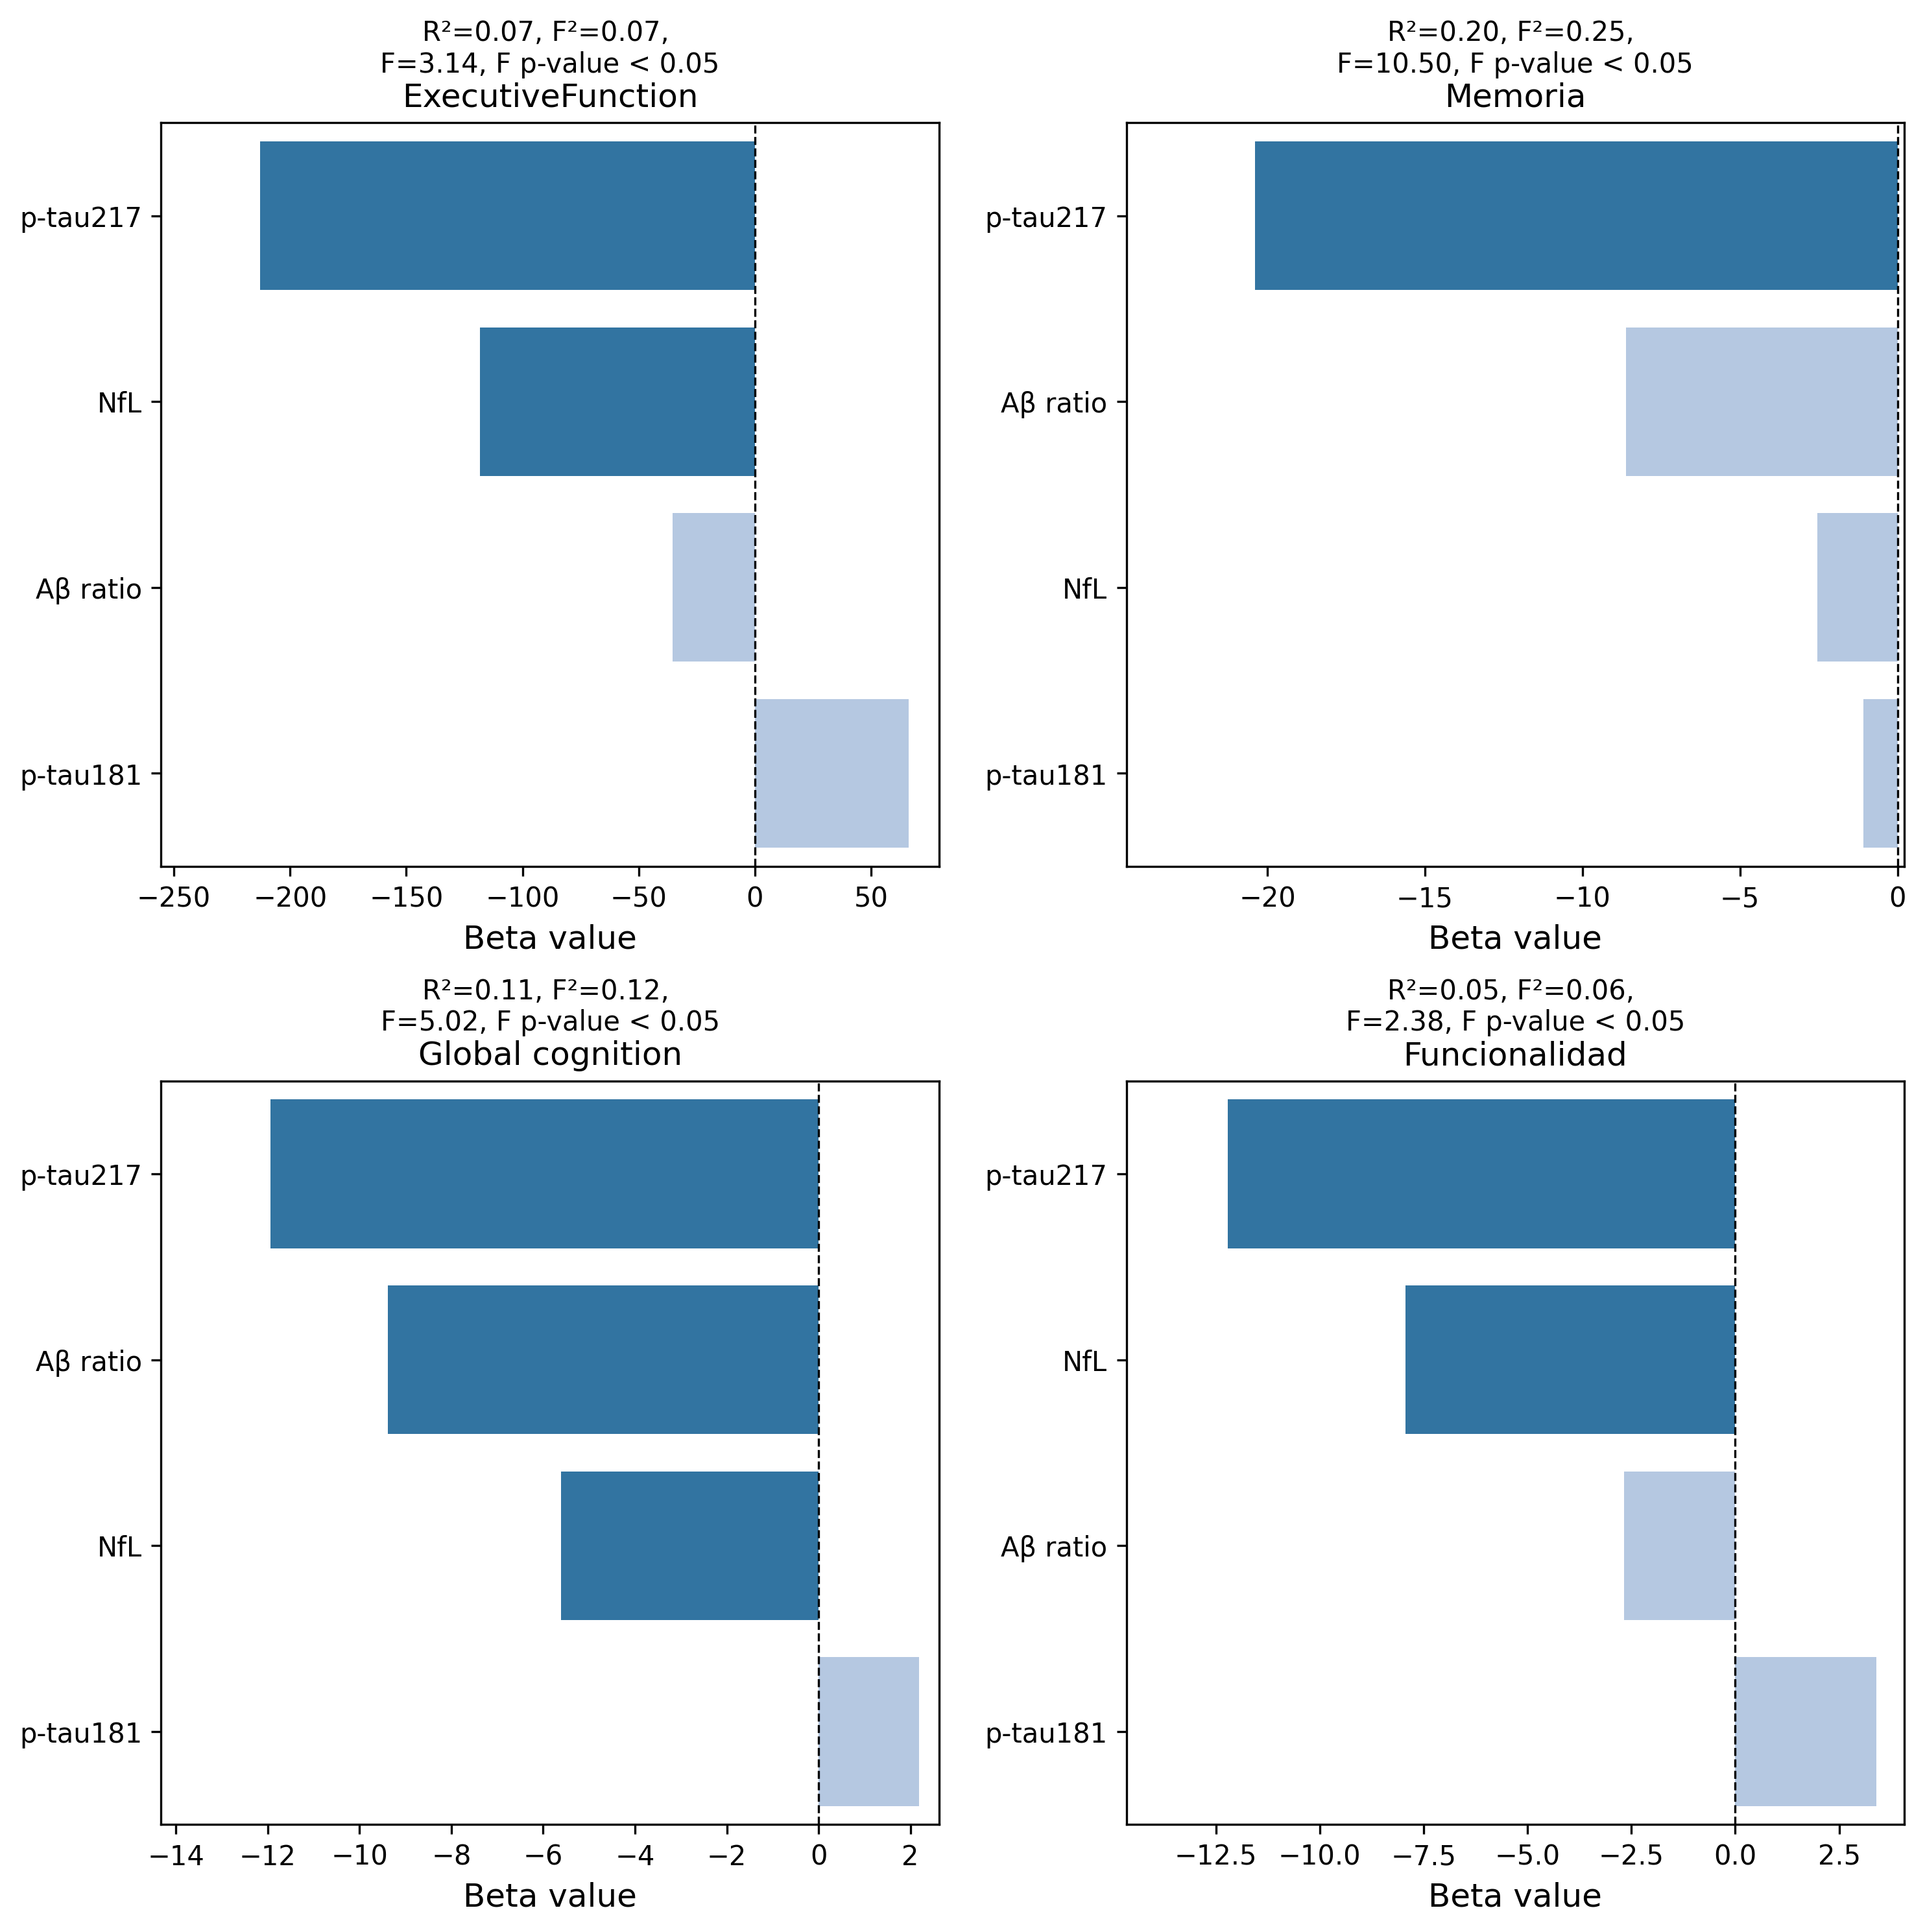

In [ ]:
#@title Matched Analysis - CNxAD (Age, sex, education)

df2=pd.read_csv('CN_AD_matched_hernan.csv')
# Select only 'record_id' and 'ApoE_add' from df2
df2_macthed_cn_ad = df2[['record_id']]

# Merge df with df2_comorbidity on 'record_id'
df=pd.merge(df, df2_macthed_cn_ad, on='record_id', how='inner')


df.diagnosis.value_counts()
#CN = 92, AD =81

df_cn = df.copy() # Ensure all columns from df are copied


interest_vars = ['Aβ ratio', 'NfL', 'p-tau181', 'p-tau217']#, 'age', 'sex', 'education']
k_feature = interest_vars

# Define the outcome variables:
outcome_vars = ['ExecutiveFunction', 'Memoria', 'Global cognition', 'Funcionalidad']

fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=300) # Changed subplot layout to 2x2
axes = axes.flatten()

#for obj_var in  ['Memoria', 'ExecutiveFunction', 'Global cognition', 'Funcionalidad']:
for i, obj_var in enumerate(['ExecutiveFunction', 'Memoria',  'Global cognition', 'Funcionalidad']):
    X_  = df_cn[interest_vars]
    y   = df_cn[obj_var]

    from skopt import BayesSearchCV

    X_train, X_test, y_train, y_test = train_test_split(X_, y, train_size=0.80, test_size=.20, random_state=0)

    scaler = MinMaxScaler(feature_range=(0.05, 0.95))
    scaling_data = scaler.fit_transform(X_train)
    X_s = pd.DataFrame(scaling_data, columns= X_train.columns, index = X_train.index)
    X_train =  X_s.copy()

    scaler = MinMaxScaler(feature_range=(0.05, 0.95))
    scaling_data = scaler.fit_transform(X_test)
    X_s = pd.DataFrame(scaling_data, columns= X_test.columns, index = X_test.index)
    X_test =  X_s.copy()



    opt_Ridge = BayesSearchCV(
        Ridge(),
        {
            'alpha': ( 0.0001, 0.01, 0.001),
            'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
            'max_iter': (1000, 10000, 100000, 1000000),
            #'tol:' : (1e-6, 1e-3, 1e+1),
            #'n_estimators': (100, 1000),

        },
        n_iter=10,
        cv=3
    )

    opt_Ridge.fit(X_train, y_train)

    print('Ridge')
    print("val. score: %s" % opt_Ridge.best_score_)
    print("test score: %s" % opt_Ridge.score(X_test, y_test))
    print("best parameters: %s" % str(opt_Ridge.best_params_))
    print('---------------------------------------------\n')


    [coef_df_Ridge, r_squared_Ridge, results_labels_df_Ridge] = Regression_Linear(X_, y, 1, 10, n_splits = 5, model = Ridge(**opt_Ridge.best_params_))
    coef_df_Ridge

    coef_df_Ridge.to_excel("Regresion_CN_AD" + obj_var + ".xlsx")

    df_betas = coef_df_Ridge.iloc[1:, [0, 3]].sort_values(by='Estimate mean', ascending=True)  # Selecting only 'Estimate mean' column and sorting by 'Estimate mean'

    df_betas['label'] = df_betas.index

    ax = axes[i]
    sns.barplot(x='Estimate mean', y='label', data=df_betas, orient='h', ax=ax, palette=np.where(df_betas['p value'] < 0.05, '#1f77b4', '#aec7e8')) # '#1f77b4', '#aec7e8' '#FFD700', '#FFEE99' '#9467bd', '#c5b0d5'Color based on significance

    ax.set_xlabel('Beta value', fontsize=12)
    ax.set_ylabel('')
    ax.set_title(obj_var, fontsize=12)
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        pass

    # Add a vertical line at x=0
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)

    # Adjust x-axis limits to accommodate labels and zero line
    min_beta = df_betas['Estimate mean'].min()
    max_beta = df_betas['Estimate mean'].max()
    ax.set_xlim(min(min_beta, 0) - abs(min_beta)*0.2, max(max_beta, 0) + abs(max_beta)*0.2)


    # Add R², F², and F values at the top of each subplot
    f_pvalue_text = f"F p-value < 0.05" if coef_df_Ridge.loc['_intercept', 'F-p_value'] < 0.05 else f"F p-value >= 0.05"
    ax.text(0.5, 1.1, f"R²={r_squared_Ridge:.2f}, F²={coef_df_Ridge.loc['_intercept', 'F2']:.2f}, \nF={coef_df_Ridge.loc['_intercept', 'F']:.2f}, {f_pvalue_text}",
            ha='center', va='center', fontsize=10, transform=ax.transAxes)

    print(obj_var, df_betas.iloc[0,0])

# Remove any unused subplots
for j in range(len(['Memoria', 'ExecutiveFunction', 'Global cognition', 'Funcionalidad']), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout, save and show the figure
plt.tight_layout()
plt.savefig("Regression_CN_AD.pdf", format="pdf", bbox_inches="tight")
plt.show()

Ridge
val. score: 0.17477951757021806
test score: -0.6965337666297469
best parameters: OrderedDict({'alpha': 0.01, 'max_iter': 10000, 'solver': 'svd'})
---------------------------------------------

ExecutiveFunction -323.0722430612268
Ridge
val. score: 0.03867957512774134
test score: 0.10032420241565154
best parameters: OrderedDict({'alpha': 0.01, 'max_iter': 1000000, 'solver': 'saga'})
---------------------------------------------

Memoria -13.10108285930875
Ridge
val. score: 0.09732528461862844
test score: -0.224844853236694
best parameters: OrderedDict({'alpha': 0.01, 'max_iter': 10000, 'solver': 'saga'})
---------------------------------------------

Global cognition -15.802297887669969
Ridge
val. score: 0.07679859301336782
test score: -0.3001622597002178
best parameters: OrderedDict({'alpha': 0.01, 'max_iter': 1000000, 'solver': 'sag'})
---------------------------------------------

Funcionalidad -19.672459877975925


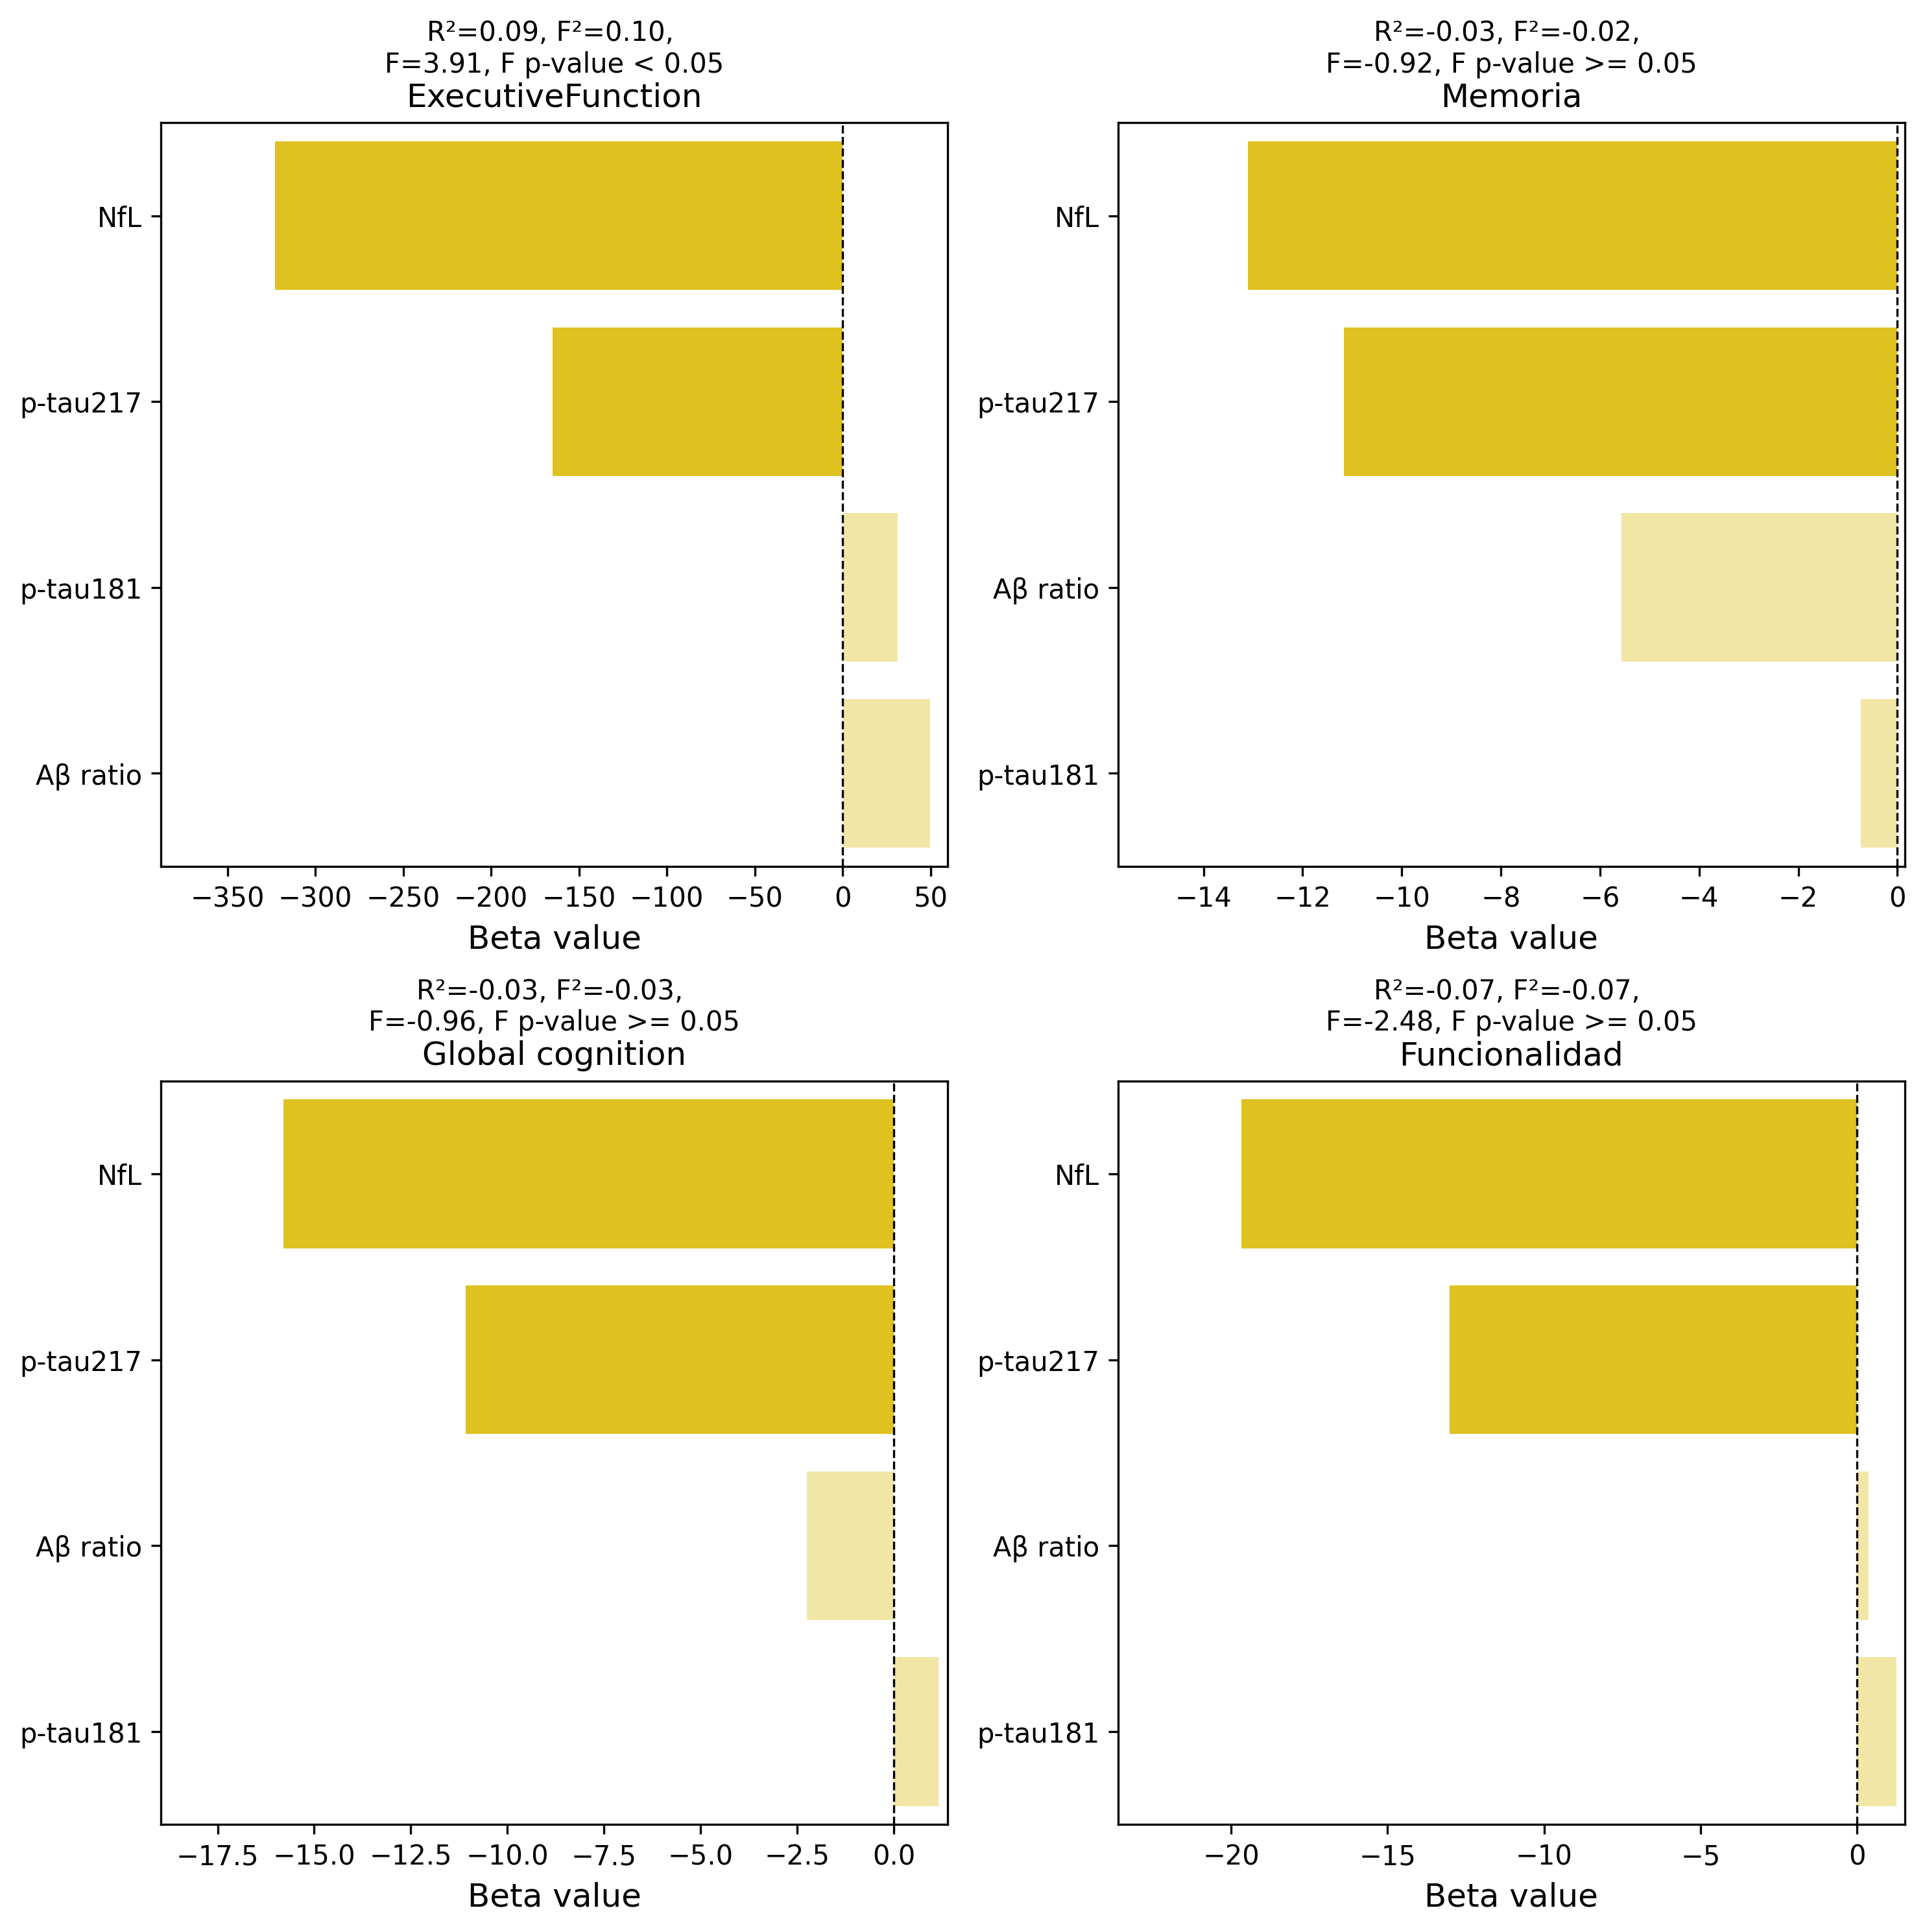

In [ ]:
#@title Matched Analysis - CN x FTD (Age, sex, education)

df2=pd.read_csv('CN_FTD_matched_hernan_matched.csv')
# Select only 'record_id' and 'ApoE_add' from df2
df2_macthed_cn_ftd = df2[['record_id']]

# Merge df with df2_comorbidity on 'record_id'
df=pd.merge(df, df2_macthed_cn_ftd, on='record_id', how='inner')


df.diagnosis.value_counts()
#CN = 78, FTD =78

df_cn = df.copy() # Ensure all columns from df are copied


interest_vars = ['Aβ ratio', 'NfL', 'p-tau181', 'p-tau217']#, 'age', 'sex', 'education']
k_feature = interest_vars

# Define the outcome variables:
outcome_vars = ['ExecutiveFunction', 'Memoria', 'Global cognition', 'Funcionalidad']

fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=300) # Changed subplot layout to 2x2
axes = axes.flatten()

#for obj_var in  ['Memoria', 'ExecutiveFunction', 'Global cognition', 'Funcionalidad']:
for i, obj_var in enumerate(['ExecutiveFunction', 'Memoria',  'Global cognition', 'Funcionalidad']):
    X_  = df_cn[interest_vars]
    y   = df_cn[obj_var]

    from skopt import BayesSearchCV

    X_train, X_test, y_train, y_test = train_test_split(X_, y, train_size=0.80, test_size=.20, random_state=0)

    scaler = MinMaxScaler(feature_range=(0.05, 0.95))
    scaling_data = scaler.fit_transform(X_train)
    X_s = pd.DataFrame(scaling_data, columns= X_train.columns, index = X_train.index)
    X_train =  X_s.copy()

    scaler = MinMaxScaler(feature_range=(0.05, 0.95))
    scaling_data = scaler.fit_transform(X_test)
    X_s = pd.DataFrame(scaling_data, columns= X_test.columns, index = X_test.index)
    X_test =  X_s.copy()



    opt_Ridge = BayesSearchCV(
        Ridge(),
        {
            'alpha': ( 0.0001, 0.01, 0.001),
            'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
            'max_iter': (1000, 10000, 100000, 1000000),
            #'tol:' : (1e-6, 1e-3, 1e+1),
            #'n_estimators': (100, 1000),

        },
        n_iter=10,
        cv=3
    )

    opt_Ridge.fit(X_train, y_train)

    print('Ridge')
    print("val. score: %s" % opt_Ridge.best_score_)
    print("test score: %s" % opt_Ridge.score(X_test, y_test))
    print("best parameters: %s" % str(opt_Ridge.best_params_))
    print('---------------------------------------------\n')


    [coef_df_Ridge, r_squared_Ridge, results_labels_df_Ridge] = Regression_Linear(X_, y, 1, 10, n_splits = 5, model = Ridge(**opt_Ridge.best_params_))
    coef_df_Ridge

    coef_df_Ridge.to_excel("Regresion_CN_AD" + obj_var + ".xlsx")

    df_betas = coef_df_Ridge.iloc[1:, [0, 3]].sort_values(by='Estimate mean', ascending=True)  # Selecting only 'Estimate mean' column and sorting by 'Estimate mean'

    df_betas['label'] = df_betas.index

    ax = axes[i]
    sns.barplot(x='Estimate mean', y='label', data=df_betas, orient='h', ax=ax, palette=np.where(df_betas['p value'] < 0.05, '#FFD700', '#FFEE99')) # '#1f77b4', '#aec7e8' '#FFD700', '#FFEE99' '#9467bd', '#c5b0d5'Color based on significance

    ax.set_xlabel('Beta value', fontsize=12)
    ax.set_ylabel('')
    ax.set_title(obj_var, fontsize=12)
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        pass

    # Add a vertical line at x=0
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)

    # Adjust x-axis limits to accommodate labels and zero line
    min_beta = df_betas['Estimate mean'].min()
    max_beta = df_betas['Estimate mean'].max()
    ax.set_xlim(min(min_beta, 0) - abs(min_beta)*0.2, max(max_beta, 0) + abs(max_beta)*0.2)


    # Add R², F², and F values at the top of each subplot
    f_pvalue_text = f"F p-value < 0.05" if coef_df_Ridge.loc['_intercept', 'F-p_value'] < 0.05 else f"F p-value >= 0.05"
    ax.text(0.5, 1.1, f"R²={r_squared_Ridge:.2f}, F²={coef_df_Ridge.loc['_intercept', 'F2']:.2f}, \nF={coef_df_Ridge.loc['_intercept', 'F']:.2f}, {f_pvalue_text}",
            ha='center', va='center', fontsize=10, transform=ax.transAxes)

    print(obj_var, df_betas.iloc[0,0])

# Remove any unused subplots
for j in range(len(['Memoria', 'ExecutiveFunction', 'Global cognition', 'Funcionalidad']), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout, save and show the figure
plt.tight_layout()
plt.savefig("Regression_CN_AD.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [ ]:

#@title Merge all generated xlsx into one single Excel file
import os
import pandas as pd

# Install xlsxwriter if not already installed
%pip install xlsxwriter

# Get a list of all .xlsx files starting with "Regresion_CN_AD" in the current directory
excel_files = [f for f in os.listdir('.') if f.startswith('Regresion_CN_AD') and f.endswith('.xlsx')]

# Create a Pandas Excel writer using XlsxWriter as the engine.
output_filename = 'Merged_Regression_CN_AD_Results.xlsx'
writer = pd.ExcelWriter(output_filename, engine='xlsxwriter')

# Loop through each Excel file and add it to a new sheet in the merged Excel file
for excel_file in excel_files:
    try:
        df_to_merge = pd.read_excel(excel_file)
        # Use the filename (without extension) as the sheet name and shorten it
        # by removing the common prefix 'Regresion_CN_AD'
        sheet_name = os.path.splitext(excel_file)[0].replace('Regresion_CN_AD', '')
        # Ensure the sheet name is not empty after replacement
        if not sheet_name:
            sheet_name = os.path.splitext(excel_file)[0] # Fallback to full name if only prefix was present
        # Trim to ensure it's within Excel's 31 char limit if still too long, though replacement should fix it
        sheet_name = sheet_name[:31]

        df_to_merge.to_excel(writer, sheet_name=sheet_name, index=False)
        print(f"Added {excel_file} to sheet: {sheet_name}")
    except Exception as e:
        print(f"Could not read {excel_file}: {e}")

# Close the Pandas Excel writer and save the Excel file
writer.close()
print(f"All regression results merged into {output_filename}")

Added Regresion_CN_ADGlobal cognition.xlsx to sheet: Global cognition
Added Regresion_CN_ADMemoria.xlsx to sheet: Memoria
Added Regresion_CN_ADExecutiveFunction.xlsx to sheet: ExecutiveFunction
Added Regresion_CN_ADFuncionalidad.xlsx to sheet: Funcionalidad
All regression results merged into Merged_Regression_CN_AD_Results.xlsx


In [ ]:
# @title APOE Analysis


df2=pd.read_excel('atn_new.xlsx')
df2.rename(columns={'id': 'record_id'}, inplace=True)

# Select only 'record_id' and 'ApoE_add' from df2
df2_apoe = df2[['record_id', 'ApoE_add']]



# Merge df with df2_comorbidity on 'record_id'
df=pd.merge(df, df2_apoe, on='record_id', how='inner')

# Drop rows where 'ApoE_add' is NaN
df.dropna(subset=['ApoE_add'], inplace=True)
df.reset_index(inplace=True, drop=True)


df_cn = df[df['diagnosis']!='AD'].copy() # Ensure all columns from df are copied



df.diagnosis.value_counts()

interest_vars = ['Aβ ratio', 'NfL', 'p-tau181', 'p-tau217','ApoE_add']#, 'age', 'sex', 'education']
k_feature = interest_vars

# Define the outcome variables:
outcome_vars = ['ExecutiveFunction', 'Memoria', 'Global cognition', 'Funcionalidad']

fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=300) # Changed subplot layout to 2x2
axes = axes.flatten()

#for obj_var in  ['Memoria', 'ExecutiveFunction', 'Global cognition', 'Funcionalidad']:
for i, obj_var in enumerate(['ExecutiveFunction', 'Memoria',  'Global cognition', 'Funcionalidad']):
    X_  = df_cn[interest_vars]
    y   = df_cn[obj_var]

    from skopt import BayesSearchCV

    X_train, X_test, y_train, y_test = train_test_split(X_, y, train_size=0.80, test_size=.20, random_state=0)

    scaler = MinMaxScaler(feature_range=(0.05, 0.95))
    scaling_data = scaler.fit_transform(X_train)
    X_s = pd.DataFrame(scaling_data, columns= X_train.columns, index = X_train.index)
    X_train =  X_s.copy()

    scaler = MinMaxScaler(feature_range=(0.05, 0.95))
    scaling_data = scaler.fit_transform(X_test)
    X_s = pd.DataFrame(scaling_data, columns= X_test.columns, index = X_test.index)
    X_test =  X_s.copy()



    opt_Ridge = BayesSearchCV(
        Ridge(),
        {
            'alpha': ( 0.0001, 0.01, 0.001),
            'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
            'max_iter': (1000, 10000, 100000, 1000000),
            #'tol:' : (1e-6, 1e-3, 1e+1),
            #'n_estimators': (100, 1000),

        },
        n_iter=10,
        cv=3
    )

    opt_Ridge.fit(X_train, y_train)

    print('Ridge')
    print("val. score: %s" % opt_Ridge.best_score_)
    print("test score: %s" % opt_Ridge.score(X_test, y_test))
    print("best parameters: %s" % str(opt_Ridge.best_params_))
    print('---------------------------------------------\n')


    [coef_df_Ridge, r_squared_Ridge, results_labels_df_Ridge] = Regression_Linear(X_, y, 1, 10, n_splits = 5, model = Ridge(**opt_Ridge.best_params_))
    coef_df_Ridge

    coef_df_Ridge.to_excel("Regresion_CN_AD" + obj_var + ".xlsx")

    df_betas = coef_df_Ridge.iloc[1:, [0, 3]].sort_values(by='Estimate mean', ascending=True)  # Selecting only 'Estimate mean' column and sorting by 'Estimate mean'

    df_betas['label'] = df_betas.index

    ax = axes[i]
    sns.barplot(x='Estimate mean', y='label', data=df_betas, orient='h', ax=ax, palette=np.where(df_betas['p value'] < 0.05, '#FFD700', '#FFEE99')) # '#1f77b4', '#aec7e8' '#FFD700', '#FFEE99'Color based on significance

    ax.set_xlabel('Beta value', fontsize=12)
    ax.set_ylabel('')
    ax.set_title(obj_var, fontsize=12)
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        pass

    # Add a vertical line at x=0
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)

    # Adjust x-axis limits to accommodate labels and zero line
    min_beta = df_betas['Estimate mean'].min()
    max_beta = df_betas['Estimate mean'].max()
    ax.set_xlim(min(min_beta, 0) - abs(min_beta)*0.2, max(max_beta, 0) + abs(max_beta)*0.2)


    # Add R², F², and F values at the top of each subplot
    f_pvalue_text = f"F p-value < 0.05" if coef_df_Ridge.loc['_intercept', 'F-p_value'] < 0.05 else f"F p-value >= 0.05"
    ax.text(0.5, 1.1, f"R²={r_squared_Ridge:.2f}, F²={coef_df_Ridge.loc['_intercept', 'F2']:.2f}, \nF={coef_df_Ridge.loc['_intercept', 'F']:.2f}, {f_pvalue_text}",
            ha='center', va='center', fontsize=10, transform=ax.transAxes)

    print(obj_var, df_betas.iloc[0,0])

# Remove any unused subplots
for j in range(len(['Memoria', 'ExecutiveFunction', 'Global cognition', 'Funcionalidad']), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout, save and show the figure
plt.tight_layout()
plt.savefig("Regression_CN_AD.pdf", format="pdf", bbox_inches="tight")
plt.show()

,count
diagnosis,
CN,165
AD,126
FTD,79


Ridge
val. score: 0.14000449165432927
test score: -0.09169115748016976
best parameters: OrderedDict({'alpha': 0.01, 'max_iter': 10000, 'solver': 'svd'})
---------------------------------------------

ExecutiveFunction -404.60025631852443
Ridge
val. score: 0.00961802403049102
test score: -0.06624223298579479
best parameters: OrderedDict({'alpha': 0.01, 'max_iter': 100000, 'solver': 'saga'})
---------------------------------------------

Memoria -18.360120970478697
Ridge
val. score: 0.05507439508177544
test score: 0.2629415491999939
best parameters: OrderedDict({'alpha': 0.01, 'max_iter': 100000, 'solver': 'svd'})
---------------------------------------------

Global cognition -17.360127887839724
Ridge
val. score: 0.05360409500442912
test score: 0.019833141039664492
best parameters: OrderedDict({'alpha': 0.01, 'max_iter': 1000000, 'solver': 'saga'})
---------------------------------------------

Funcionalidad -24.761126109384318


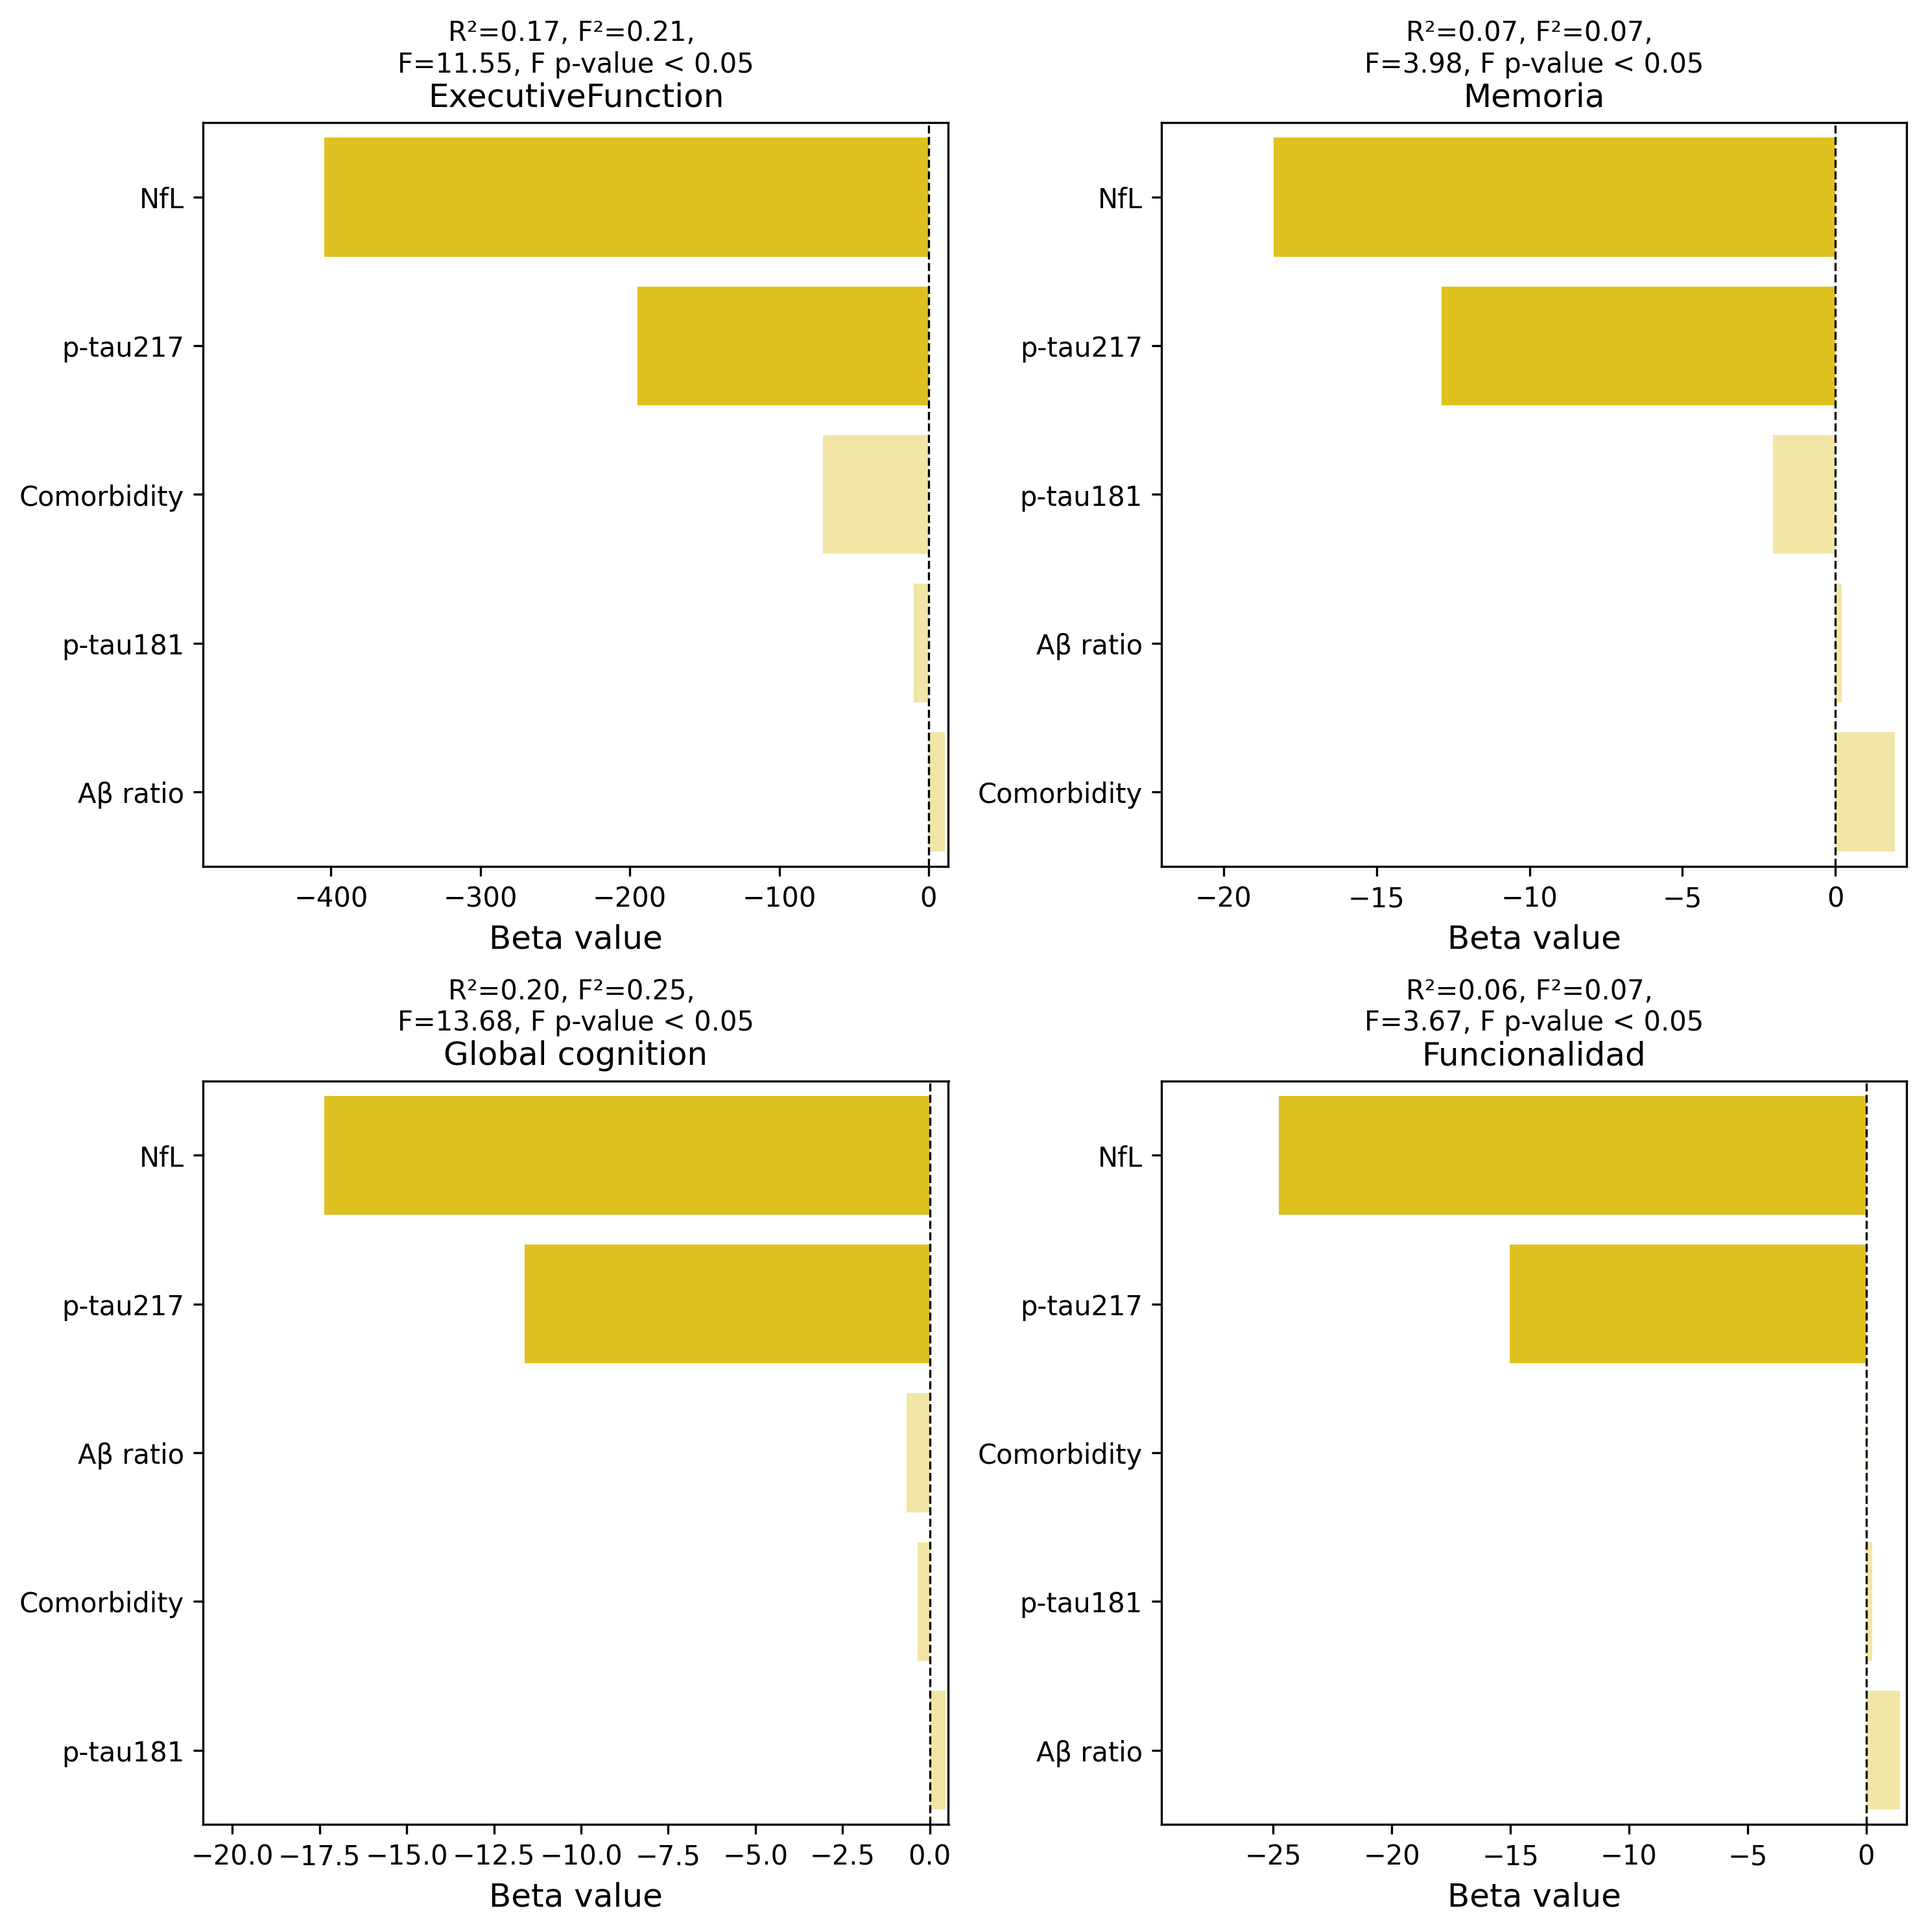

In [ ]:
# @title Comorbidity Analysis

df2= pd.read_excel('Comorbilidades_new.xlsx')


# Select only 'record_id' and 'Comorbidity' from df2
df2_comorbidity = df2[['record_id', 'Comorbidity']]

# Merge df with df2_comorbidity on 'record_id'
df=pd.merge(df, df2_comorbidity, on='record_id', how='inner')



df_cn = df[df['diagnosis']!='AD'].copy() # Ensure all columns from df are copied

df_cn.diagnosis.value_counts()

interest_vars = ['Aβ ratio', 'NfL', 'p-tau181', 'p-tau217','Comorbidity']#, 'age', 'sex', 'education']
k_feature = interest_vars

# Define the outcome variables:
outcome_vars = ['ExecutiveFunction', 'Memoria', 'Global cognition', 'Funcionalidad']

fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=300) # Changed subplot layout to 2x2
axes = axes.flatten()

#for obj_var in  ['Memoria', 'ExecutiveFunction', 'Global cognition', 'Funcionalidad']:
for i, obj_var in enumerate(['ExecutiveFunction', 'Memoria',  'Global cognition', 'Funcionalidad']):
    X_  = df_cn[interest_vars]
    y   = df_cn[obj_var]

    from skopt import BayesSearchCV

    X_train, X_test, y_train, y_test = train_test_split(X_, y, train_size=0.80, test_size=.20, random_state=0)

    scaler = MinMaxScaler(feature_range=(0.05, 0.95))
    scaling_data = scaler.fit_transform(X_train)
    X_s = pd.DataFrame(scaling_data, columns= X_train.columns, index = X_train.index)
    X_train =  X_s.copy()

    scaler = MinMaxScaler(feature_range=(0.05, 0.95))
    scaling_data = scaler.fit_transform(X_test)
    X_s = pd.DataFrame(scaling_data, columns= X_test.columns, index = X_test.index)
    X_test =  X_s.copy()



    opt_Ridge = BayesSearchCV(
        Ridge(),
        {
            'alpha': ( 0.0001, 0.01, 0.001),
            'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
            'max_iter': (1000, 10000, 100000, 1000000),
            #'tol:' : (1e-6, 1e-3, 1e+1),
            #'n_estimators': (100, 1000),

        },
        n_iter=10,
        cv=3
    )

    opt_Ridge.fit(X_train, y_train)

    print('Ridge')
    print("val. score: %s" % opt_Ridge.best_score_)
    print("test score: %s" % opt_Ridge.score(X_test, y_test))
    print("best parameters: %s" % str(opt_Ridge.best_params_))
    print('---------------------------------------------\n')


    [coef_df_Ridge, r_squared_Ridge, results_labels_df_Ridge] = Regression_Linear(X_, y, 1, 10, n_splits = 5, model = Ridge(**opt_Ridge.best_params_))
    coef_df_Ridge

    coef_df_Ridge.to_excel("Regresion_CN_AD" + obj_var + ".xlsx")

    df_betas = coef_df_Ridge.iloc[1:, [0, 3]].sort_values(by='Estimate mean', ascending=True)  # Selecting only 'Estimate mean' column and sorting by 'Estimate mean'

    df_betas['label'] = df_betas.index

    ax = axes[i]
    sns.barplot(x='Estimate mean', y='label', data=df_betas, orient='h', ax=ax, palette=np.where(df_betas['p value'] < 0.05, '#FFD700', '#FFEE99')) # '#FFD700', '#FFEE99'Color based on significance

    ax.set_xlabel('Beta value', fontsize=12)
    ax.set_ylabel('')
    ax.set_title(obj_var, fontsize=12)
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        pass

    # Add a vertical line at x=0
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)

    # Adjust x-axis limits to accommodate labels and zero line
    min_beta = df_betas['Estimate mean'].min()
    max_beta = df_betas['Estimate mean'].max()
    ax.set_xlim(min(min_beta, 0) - abs(min_beta)*0.2, max(max_beta, 0) + abs(max_beta)*0.2)


    # Add R², F², and F values at the top of each subplot
    f_pvalue_text = f"F p-value < 0.05" if coef_df_Ridge.loc['_intercept', 'F-p_value'] < 0.05 else f"F p-value >= 0.05"
    ax.text(0.5, 1.1, f"R²={r_squared_Ridge:.2f}, F²={coef_df_Ridge.loc['_intercept', 'F2']:.2f}, \nF={coef_df_Ridge.loc['_intercept', 'F']:.2f}, {f_pvalue_text}",
            ha='center', va='center', fontsize=10, transform=ax.transAxes)

    print(obj_var, df_betas.iloc[0,0])

# Remove any unused subplots
for j in range(len(['Memoria', 'ExecutiveFunction', 'Global cognition', 'Funcionalidad']), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout, save and show the figure
plt.tight_layout()
plt.savefig("Regression_CN_AD.pdf", format="pdf", bbox_inches="tight")
plt.show()



```
# Isto está formatado como código
```

## CN vs AD coivariate countries

In [ ]:
df_cn = df[df['diagnosis']!='FTD'].copy() # Ensure all columns from df are copied

df_cn.diagnosis.value_counts()

,count
diagnosis,
CN,186
AD,148


In [ ]:
df_cn['Funcionalidad'].corr(df_cn['age'])

np.float64(-0.3935795072332416)

In [ ]:
df_cn = df[df['diagnosis']!='FTD'].copy()

interest_vars = ['Aβ ratio', 'NfL', 'p-tau181', 'p-tau217']#, 'age', 'sex', 'education']
k_feature = interest_vars

# Define the outcome variables:
outcome_vars = ['ExecutiveFunction', 'Memoria', 'Global cognition', 'Funcionalidad']

# Select the necessary columns including interest_vars, Country, and outcome_vars
cols_to_keep = interest_vars + ['Country'] + outcome_vars
df_cn = df_cn[cols_to_keep].copy()

# Convert interest_vars to float and drop rows with NaNs in these columns and outcome_vars
df_cn[interest_vars] = df_cn[interest_vars].astype(float)
df_cn.dropna(inplace=True, subset= interest_vars + outcome_vars + ['Country'])


# Create dummy variables for 'Country'
df_cn_dummies = pd.get_dummies(df_cn['Country'], prefix='Country')

# Concatenate the original DataFrame (excluding the original 'Country' column) with the dummy variables
df_cn = pd.concat([df_cn.drop(columns=['Country']), df_cn_dummies], axis=1)

# Update interest_vars to include the new dummy variable columns and the original interest_vars
interest_vars = interest_vars + list(df_cn_dummies.columns)


df_cn.reset_index(inplace=True, drop = True)
df_cn.shape

(334, 14)

Ridge
val. score: 0.14466480806566018
test score: 0.14003348685568373
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 1000000), ('solver', 'cholesky')])
---------------------------------------------

ExecutiveFunction -266.07526793761775
Ridge
val. score: 0.22454222254210243
test score: -0.07164495301848639
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 1000), ('solver', 'cholesky')])
---------------------------------------------

Memoria -21.758535751716018
Ridge
val. score: 0.17131893610561647
test score: 0.20094688677120032
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 1000000), ('solver', 'sag')])
---------------------------------------------

Global cognition -13.409410493872272
Ridge
val. score: 0.11305203538589943
test score: -0.03369322274500641
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 1000000), ('solver', 'sag')])
---------------------------------------------

Funcionalidad -15.21758553639152


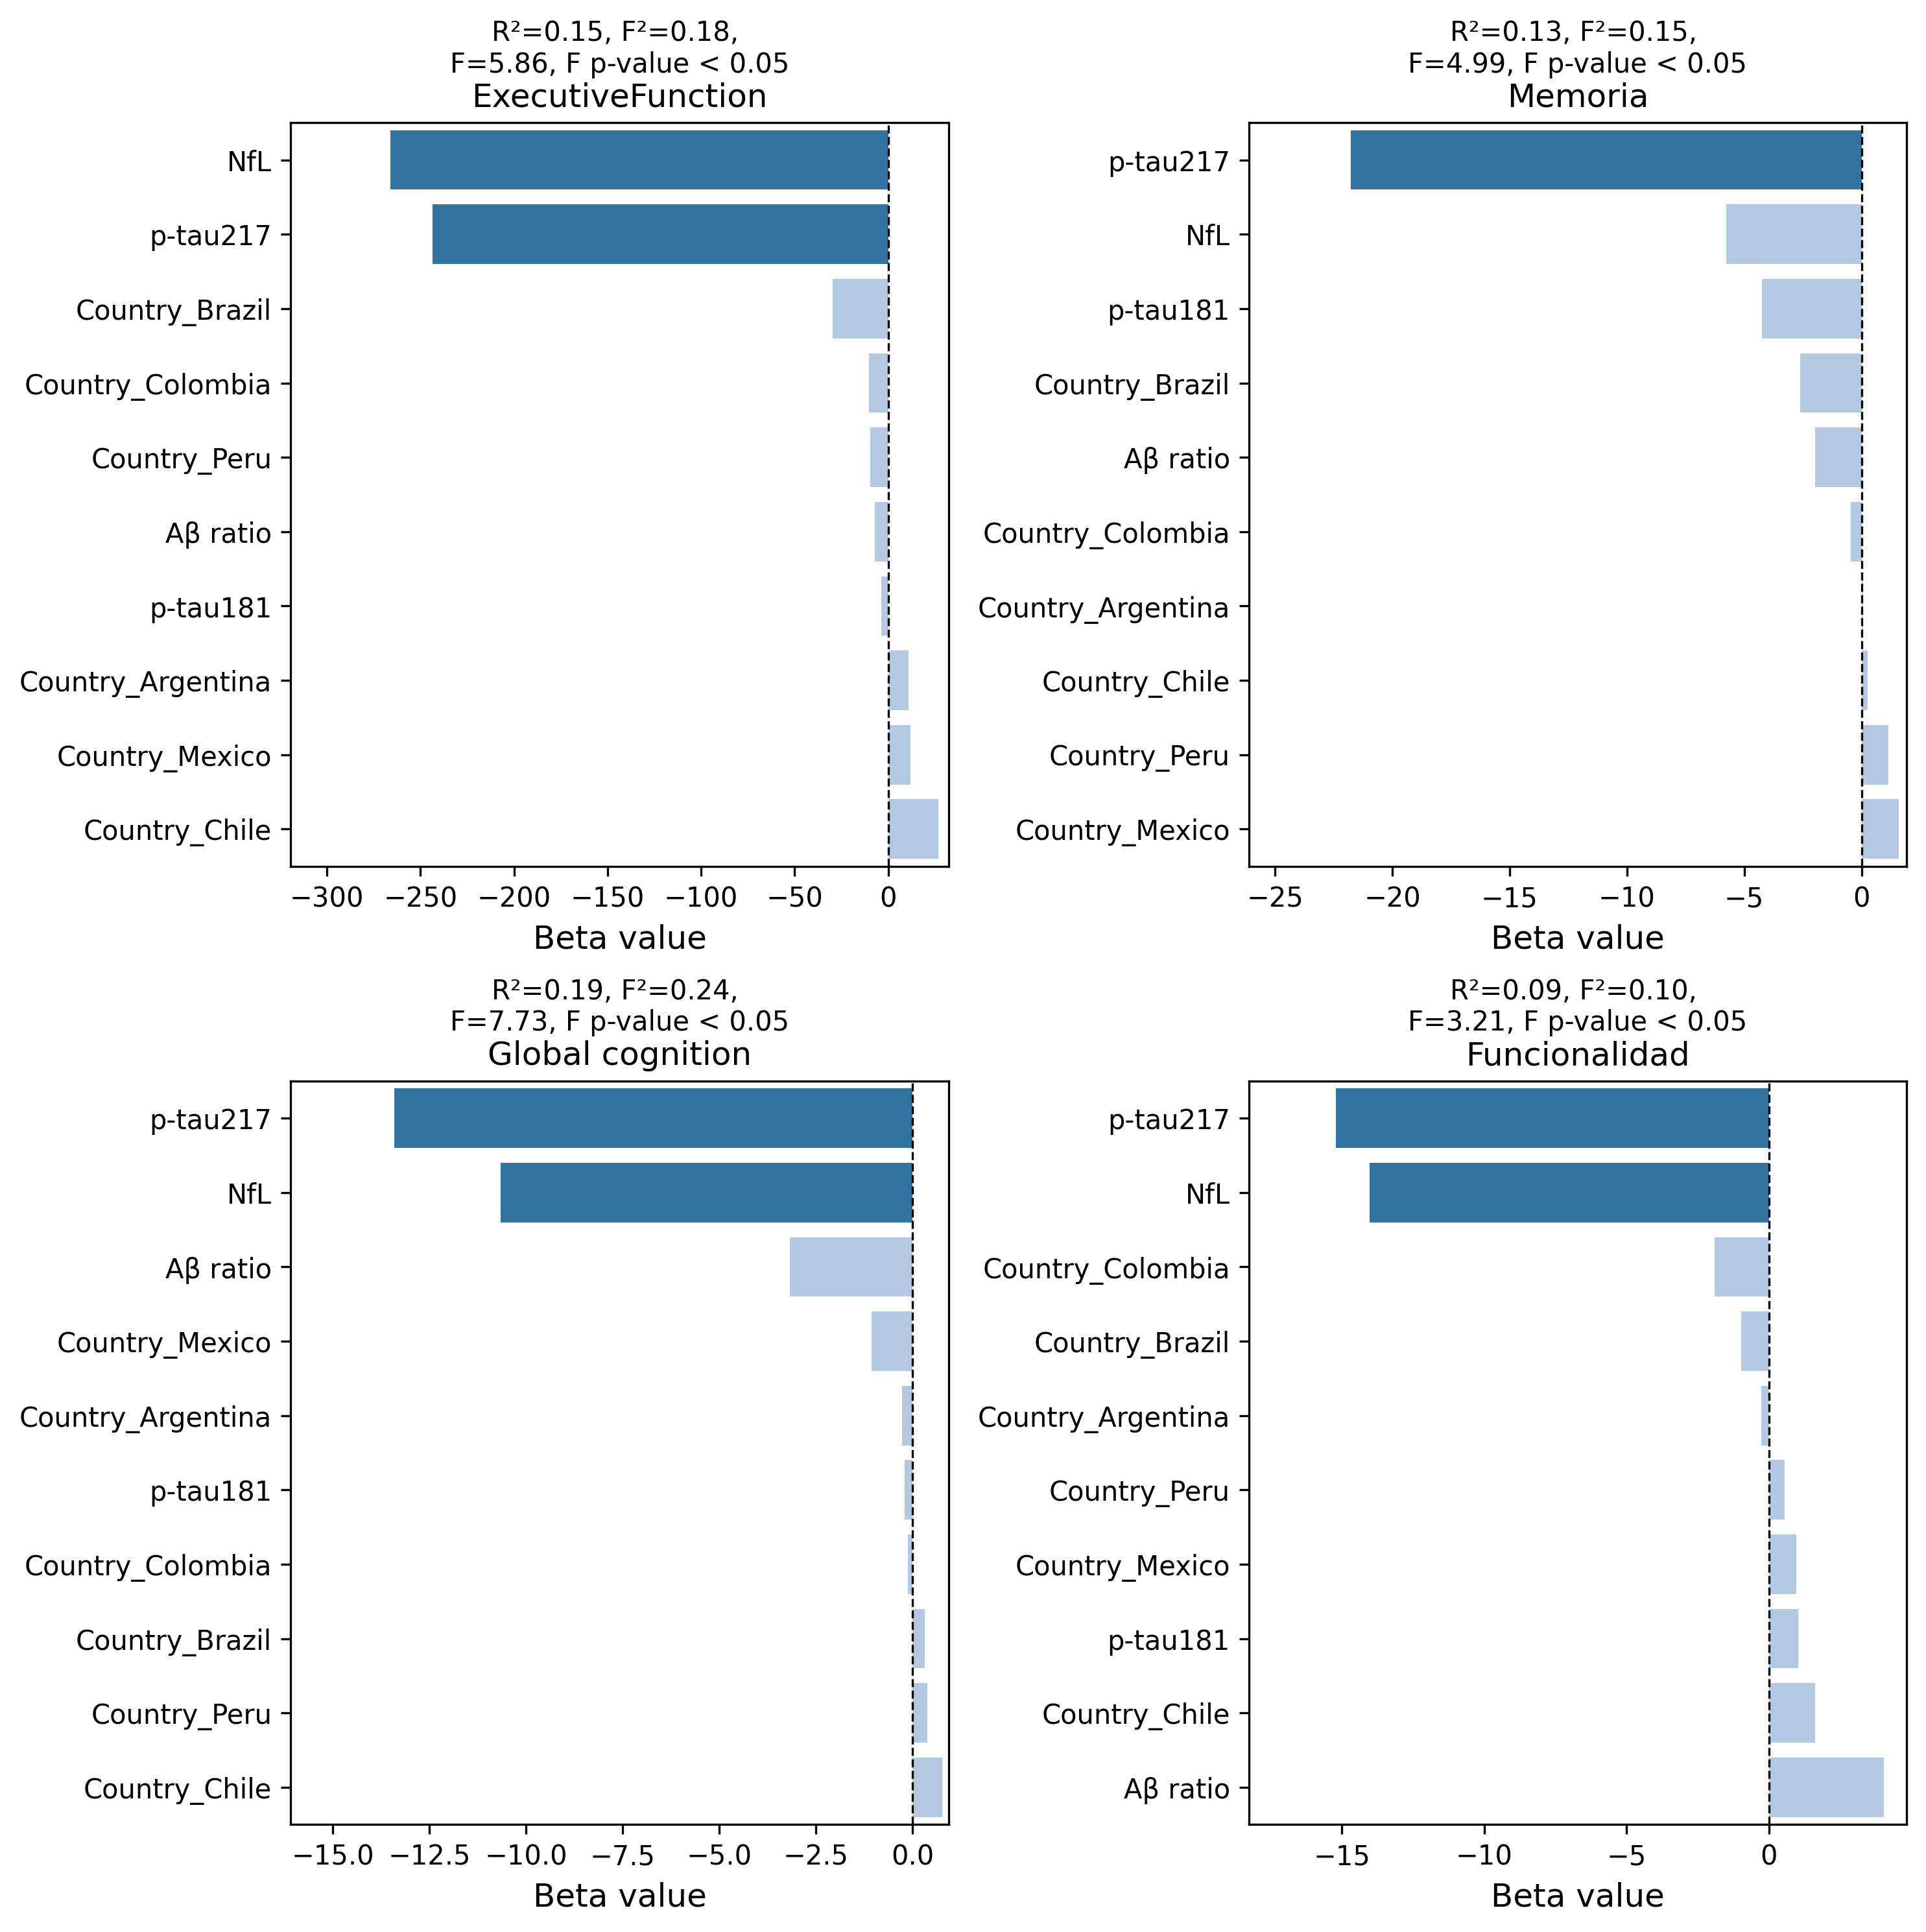

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=300) # Changed subplot layout to 2x2
axes = axes.flatten()

#for obj_var in  ['Memoria', 'ExecutiveFunction', 'Global cognition', 'Funcionalidad']:
for i, obj_var in enumerate(['ExecutiveFunction', 'Memoria',  'Global cognition', 'Funcionalidad']):
    X_  = df_cn[interest_vars]
    y   = df_cn[obj_var]

    from skopt import BayesSearchCV

    X_train, X_test, y_train, y_test = train_test_split(X_, y, train_size=0.80, test_size=.20, random_state=0)

    scaler = MinMaxScaler(feature_range=(0.05, 0.95))
    scaling_data = scaler.fit_transform(X_train)
    X_s = pd.DataFrame(scaling_data, columns= X_train.columns, index = X_train.index)
    X_train =  X_s.copy()

    scaler = MinMaxScaler(feature_range=(0.05, 0.95))
    scaling_data = scaler.fit_transform(X_test)
    X_s = pd.DataFrame(scaling_data, columns= X_test.columns, index = X_test.index)
    X_test =  X_s.copy()



    opt_Ridge = BayesSearchCV(
        Ridge(),
        {
            'alpha': ( 0.0001, 0.01, 0.001),
            'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
            'max_iter': (1000, 10000, 100000, 1000000),
            #'tol:' : (1e-6, 1e-3, 1e+1),
            #'n_estimators': (100, 1000),

        },
        n_iter=10,
        cv=3
    )

    opt_Ridge.fit(X_train, y_train)

    print('Ridge')
    print("val. score: %s" % opt_Ridge.best_score_)
    print("test score: %s" % opt_Ridge.score(X_test, y_test))
    print("best parameters: %s" % str(opt_Ridge.best_params_))
    print('---------------------------------------------\n')


    [coef_df_Ridge, r_squared_Ridge, results_labels_df_Ridge] = Regression_Linear(X_, y, 1, 10, n_splits = 5, model = Ridge(**opt_Ridge.best_params_))
    coef_df_Ridge

    coef_df_Ridge.to_excel("Regresion_CN_AD" + obj_var + ".xlsx")

    df_betas = coef_df_Ridge.iloc[1:, [0, 3]].sort_values(by='Estimate mean', ascending=True)  # Selecting only 'Estimate mean' column and sorting by 'Estimate mean'

    df_betas['label'] = df_betas.index

    ax = axes[i]
    sns.barplot(x='Estimate mean', y='label', data=df_betas, orient='h', ax=ax, palette=np.where(df_betas['p value'] < 0.05, '#1f77b4', '#aec7e8')) # Color based on significance

    ax.set_xlabel('Beta value', fontsize=12)
    ax.set_ylabel('')
    ax.set_title(obj_var, fontsize=12)
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        pass

    # Add a vertical line at x=0
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)

    # Adjust x-axis limits to accommodate labels and zero line
    min_beta = df_betas['Estimate mean'].min()
    max_beta = df_betas['Estimate mean'].max()
    ax.set_xlim(min(min_beta, 0) - abs(min_beta)*0.2, max(max_beta, 0) + abs(max_beta)*0.2)


    # Add R², F², and F values at the top of each subplot
    f_pvalue_text = f"F p-value < 0.05" if coef_df_Ridge.loc['_intercept', 'F-p_value'] < 0.05 else f"F p-value >= 0.05"
    ax.text(0.5, 1.1, f"R²={r_squared_Ridge:.2f}, F²={coef_df_Ridge.loc['_intercept', 'F2']:.2f}, \nF={coef_df_Ridge.loc['_intercept', 'F']:.2f}, {f_pvalue_text}",
            ha='center', va='center', fontsize=10, transform=ax.transAxes)

    print(obj_var, df_betas.iloc[0,0])

# Remove any unused subplots
for j in range(len(['Memoria', 'ExecutiveFunction', 'Global cognition', 'Funcionalidad']), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout, save and show the figure
plt.tight_layout()
plt.savefig("Regression_CN_AD.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
## Nota: En las gráficas invertí Excecutive Function y Functionality para mantener las mismas direcciones que las demás y mantener la lógica

In [ ]:
# @title CN + AD covariating countries, age, sex, ed

df_cn = df[df['diagnosis']!='FTD'].copy() # Ensure all columns from df are copied

df_cn.diagnosis.value_counts()


,count
diagnosis,
CN,186
AD,148


In [ ]:
df_all_adjusted = df.copy() # Create a new dataframe for the adjusted analysis

biomarker_vars = ['Aβ ratio', 'NfL', 'p-tau181', 'p-tau217']
# Add sex, age, and education to the list of variables
additional_vars = ['sex', 'age', 'education']

df_all_adjusted[biomarker_vars] = df_all_adjusted[biomarker_vars].astype(float)
# Ensure additional variables are also in float format if necessary, or handle appropriately
df_all_adjusted[additional_vars] = df_all_adjusted[additional_vars].astype(float)


# Include 'Country' in the list of interest variables and create dummy variables
df_all_dummies_adjusted = pd.get_dummies(df_all_adjusted['Country'], prefix='Country')

# Concatenate the original DataFrame (excluding the original 'Country' column) with the dummy variables
df_all_adjusted = pd.concat([df_all_adjusted.drop(columns=['Country']), df_all_dummies_adjusted], axis=1)

# Combine biomarker variables, additional variables, and country dummy variables into interest_vars
interest_vars_adjusted = biomarker_vars + additional_vars + list(df_all_dummies_adjusted.columns)

df_all_adjusted.dropna(inplace=True, subset= interest_vars_adjusted + ['ExecutiveFunction', 'Memoria',  'Global cognition', 'Funcionalidad'])

df_all_adjusted.reset_index(inplace=True, drop = True)
df_all_adjusted.shape

(427, 261)

Ridge
val. score: 0.3371504370268676
test score: 0.28511304517498304
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 100000), ('solver', 'saga')])
---------------------------------------------

ExecutiveFunction -240.89603431473378
Ridge
val. score: 0.2306506425736509
test score: 0.20937165324887208
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 1000000), ('solver', 'sag')])
---------------------------------------------

Memoria -16.56615154111036
Ridge
val. score: 0.2989726442471283
test score: -0.18410670809530294
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 1000), ('solver', 'lsqr')])
---------------------------------------------

Global cognition -13.440716238436561
Ridge
val. score: 0.10157400276197585
test score: 0.2002523721317211
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 1000), ('solver', 'saga')])
---------------------------------------------

Funcionalidad -13.662720734939697


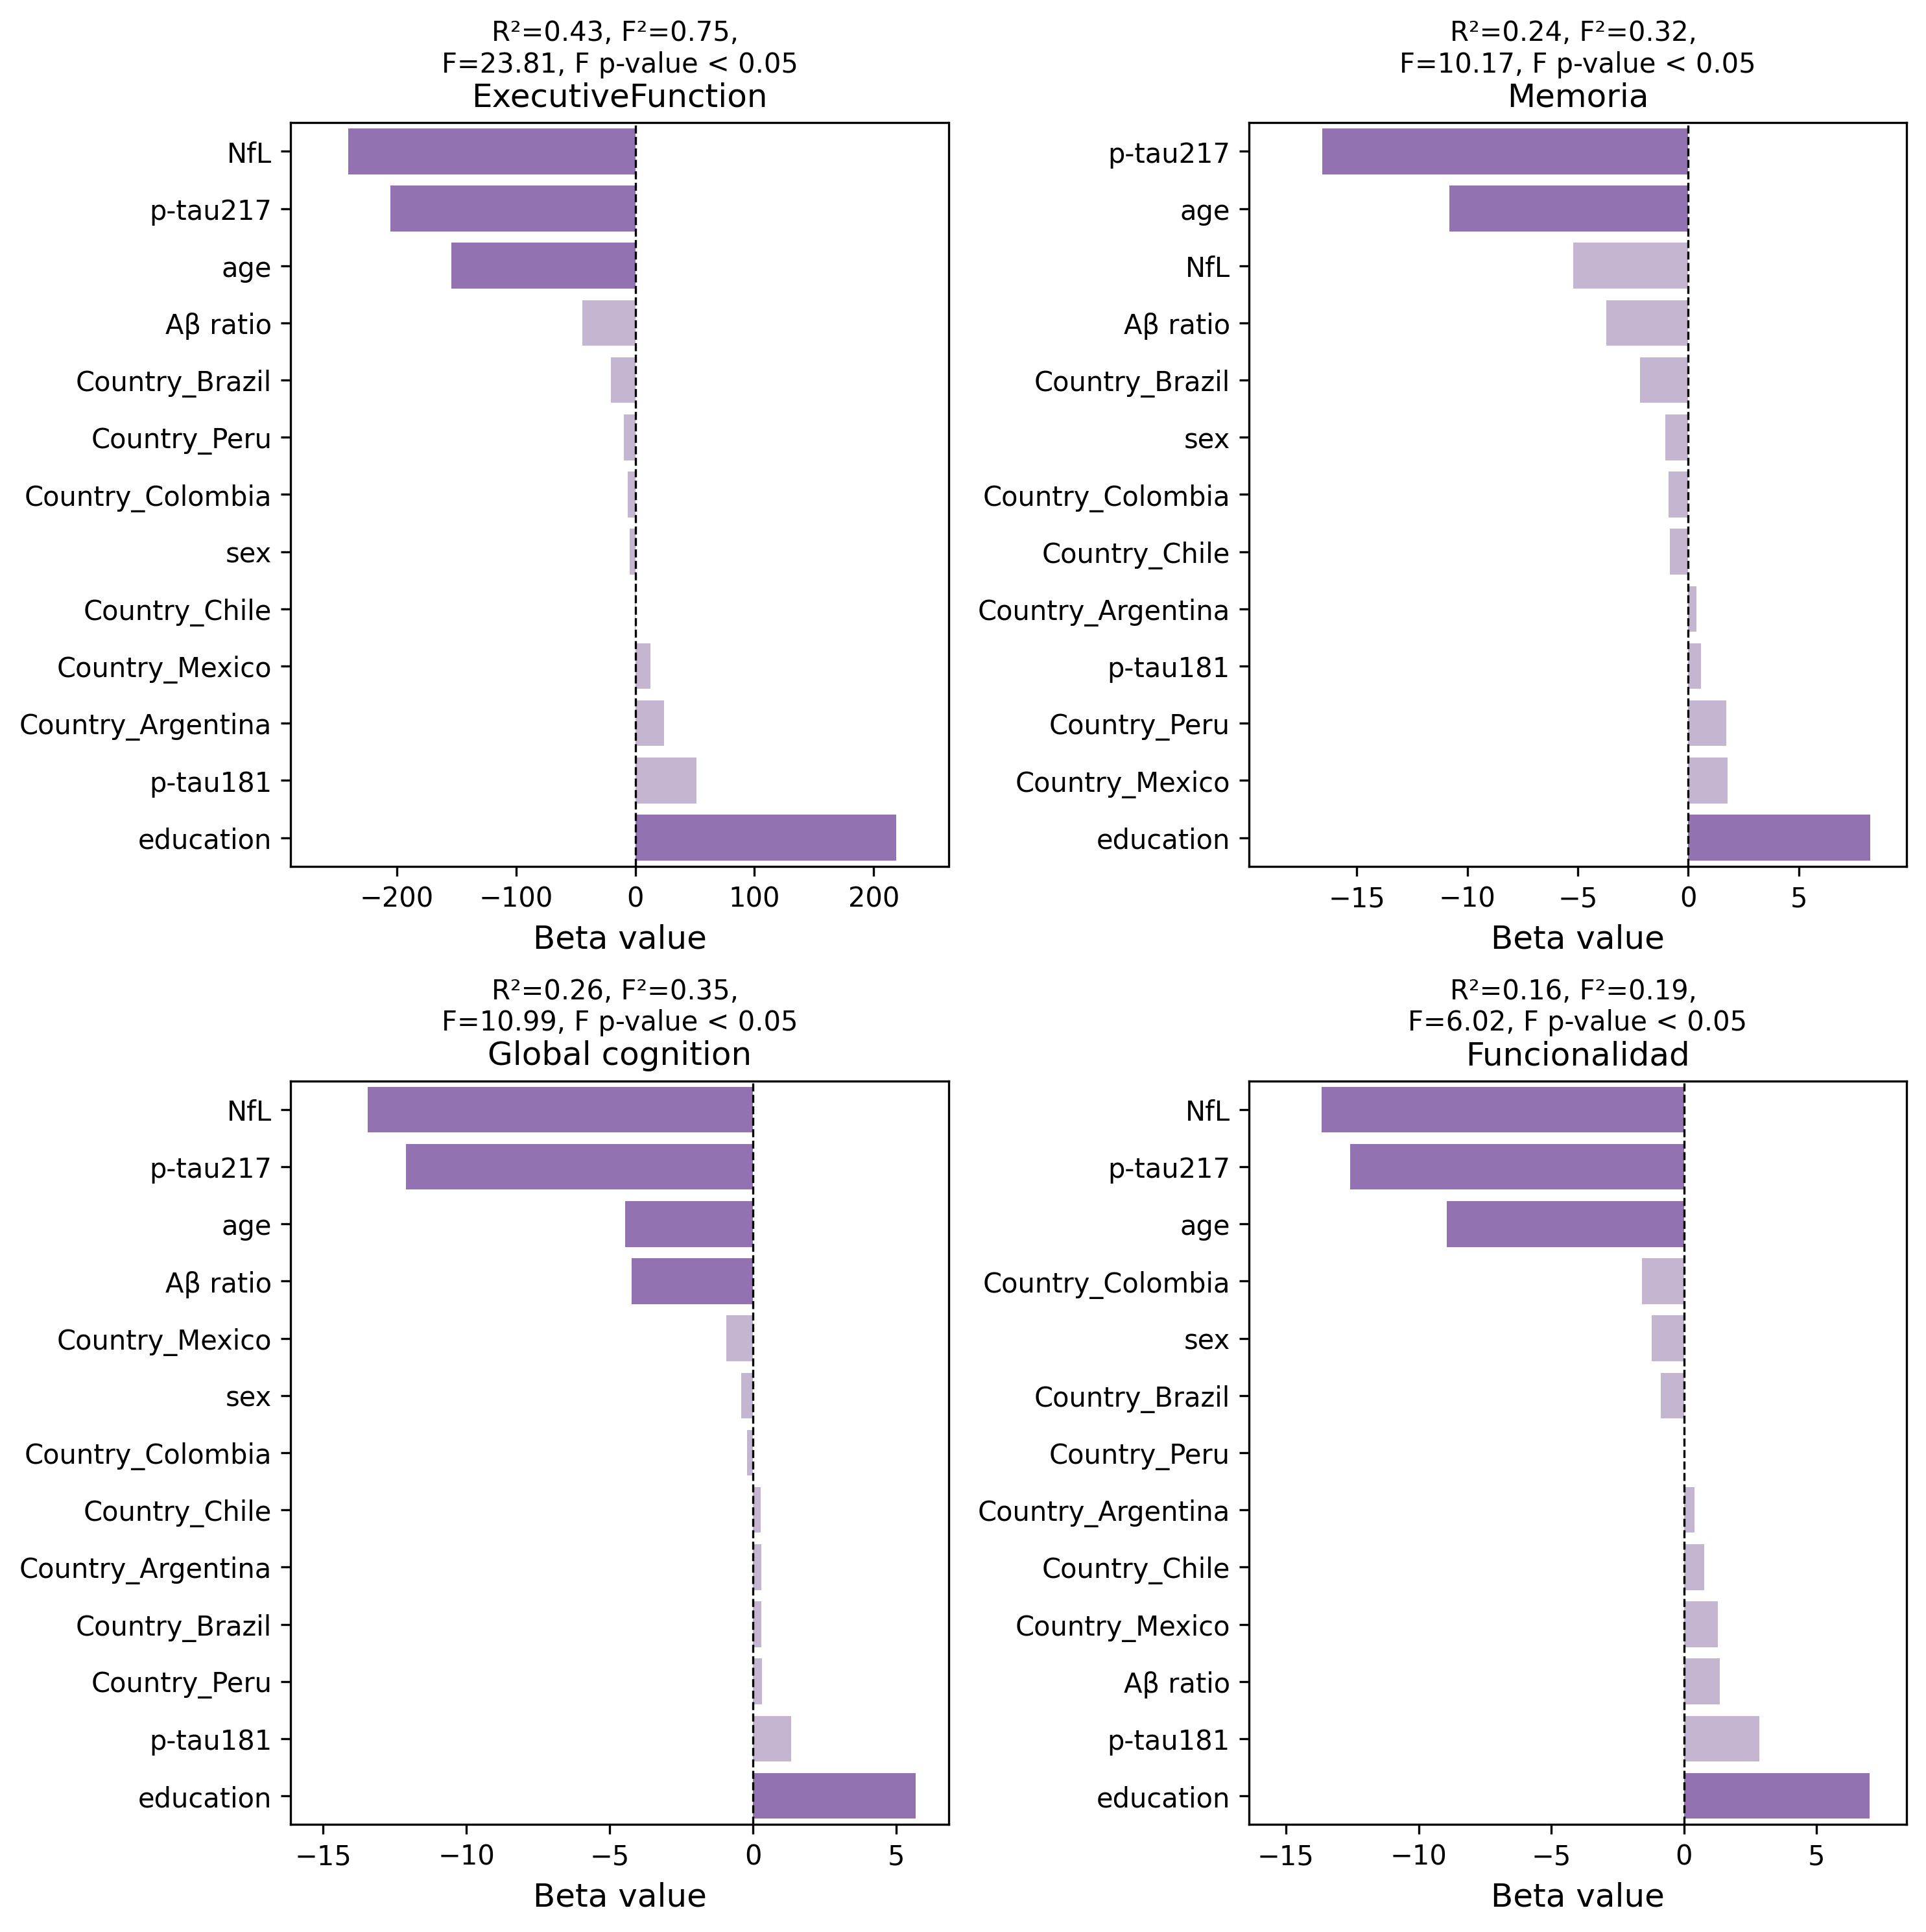

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=300) # Changed subplot layout to 2x2
axes = axes.flatten()

# Define interest_vars outside the loop, including the additional variables
interest_vars_analysis_adjusted = ['Aβ ratio', 'NfL', 'p-tau181', 'p-tau217', 'sex', 'age', 'education'] + list(df_all_dummies_adjusted.columns)

#for obj_var in  ['Memoria', 'ExecutiveFunction', 'Global cognition', 'Funcionalidad']:
for i, obj_var in enumerate(['ExecutiveFunction', 'Memoria',  'Global cognition', 'Funcionalidad']):
    X_  = df_all_adjusted[interest_vars_analysis_adjusted]
    y   = df_all_adjusted[obj_var]

    from skopt import BayesSearchCV

    X_train, X_test, y_train, y_test = train_test_split(X_, y, train_size=0.80, test_size=.20, random_state=0)

    scaler = MinMaxScaler(feature_range=(0.05, 0.95))
    scaling_data = scaler.fit_transform(X_train)
    X_s = pd.DataFrame(scaling_data, columns= X_train.columns, index = X_train.index)
    X_train =  X_s.copy()

    scaler = MinMaxScaler(feature_range=(0.05, 0.95))
    scaling_data = scaler.fit_transform(X_test)
    X_s = pd.DataFrame(scaling_data, columns= X_test.columns, index = X_test.index)
    X_test =  X_s.copy()



    opt_Ridge = BayesSearchCV(
        Ridge(),
        {
            'alpha': ( 0.0001, 0.01, 0.001),
            'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
            'max_iter': (1000, 10000, 100000, 1000000),
            #'tol:' : (1e-6, 1e-3, 1e+1),
            #'n_estimators': (100, 1000),

        },
        n_iter=10,
        cv=3
    )

    opt_Ridge.fit(X_train, y_train)

    print('Ridge')
    print("val. score: %s" % opt_Ridge.best_score_)
    print("test score: %s" % opt_Ridge.score(X_test, y_test))
    print("best parameters: %s" % str(opt_Ridge.best_params_))
    print('---------------------------------------------\n')


    [coef_df_Ridge, r_squared_Ridge, results_labels_df_Ridge] = Regression_Linear(X_, y, 1, 10, n_splits = 5, model = Ridge(**opt_Ridge.best_params_))
    coef_df_Ridge

    coef_df_Ridge.to_excel("Regresion_CN_AD_adjusted_all" + obj_var + ".xlsx")

    df_betas = coef_df_Ridge.iloc[1:, [0, 3]].sort_values(by='Estimate mean', ascending=True)  # Selecting only 'Estimate mean' column and sorting by 'Estimate mean'

    df_betas['label'] = df_betas.index


    ax = axes[i]
    sns.barplot(x='Estimate mean', y='label', data=df_betas, orient='h', ax=ax, palette=np.where(df_betas['p value'] < 0.05, '#9467bd', '#c5b0d5')) # Color based on significance (purple tones)


    ax.set_xlabel('Beta value', fontsize=12)
    ax.set_ylabel('')
    ax.set_title(obj_var, fontsize=12)
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        pass


    # Add a vertical line at x=0
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)

    # Adjust x-axis limits to accommodate labels and zero line
    min_beta = df_betas['Estimate mean'].min()
    max_beta = df_betas['Estimate mean'].max()
    ax.set_xlim(min(min_beta, 0) - abs(min_beta)*0.2, max(max_beta, 0) + abs(max_beta)*0.2)


    # Add R², F², and F values at the top of each subplot
    f_pvalue_text = f"F p-value < 0.05" if coef_df_Ridge.loc['_intercept', 'F-p_value'] < 0.05 else f"F p-value >= 0.05"
    ax.text(0.5, 1.1, f"R²={r_squared_Ridge:.2f}, F²={coef_df_Ridge.loc['_intercept', 'F2']:.2f}, \nF={coef_df_Ridge.loc['_intercept', 'F']:.2f}, {f_pvalue_text}",
            ha='center', va='center', fontsize=10, transform=ax.transAxes)


    print(obj_var, df_betas.iloc[0,0])

# Remove any unused subplots
for j in range(len(['Memoria', 'ExecutiveFunction', 'Global cognition', 'Funcionalidad']), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout, save and show the figure
plt.tight_layout()
plt.savefig("Regression_CN_AD_adjusted_counrties_agesexed.pdf", format="pdf", bbox_inches="tight")
plt.show()

## CN vs FTD covariate countries

In [ ]:
df_cn = df[df['diagnosis']!='AD'].copy() # Ensure all columns from df are copied

df_cn.diagnosis.value_counts()

,count
diagnosis,
CN,186
FTD,93


In [ ]:
df_cn['ExecutiveFunction'].corr(df_cn['age'])

,record_id,site,Country,cdr_date,cdr_examiner,cdr_means,cdr_memory,cdr_orient,cdr_prblm,cdr_cmnaff,...,p-tau217,sex,age,education,diagnosis,mmse_educ,Memoria,ExecutiveFunction,Global cognition,Funcionalidad
0,AF023,Avila,Mexico,2021-08-28,DDuron,1.0,0.0,0.0,0.0,0.0,...,0.194,1.0,72.0,6.0,CN,168.0,11.0,0.0,28.0,33.0
1,AF025,Avila,Mexico,2021-08-29,DDuron,1.0,0.0,0.0,0.0,0.0,...,0.112,2.0,75.0,16.0,CN,464.0,11.0,103.0,29.0,33.0
2,AF033,Avila,Mexico,2021-11-15,DDuron,1.0,0.0,0.0,0.0,0.0,...,0.157,1.0,57.0,16.0,CN,448.0,18.0,231.0,28.0,33.0
3,AF039,Avila,Mexico,2021-11-24,DDuron,1.0,0.0,0.0,0.0,0.0,...,0.154,1.0,64.0,25.0,CN,700.0,12.0,239.0,28.0,33.0
4,AF045,Avila,Mexico,2021-12-01,DDuron,1.0,0.0,0.0,0.0,0.0,...,0.185,2.0,62.0,18.0,CN,540.0,11.0,0.0,30.0,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
422,RE041,NaN,Brazil,2023-07-28 00:00:00,LASaraiva,1.0,1.0,1.0,1.0,1.0,...,0.194,2.0,59.0,14.0,FTD,364.0,0.0,211.0,26.0,20.0
423,RE049,NaN,Brazil,2023-12-07 00:00:00,LASaraiva,1.0,0.5,0.0,1.0,1.0,...,0.059,1.0,51.0,11.0,FTD,275.0,15.0,0.0,25.0,17.0
424,RE054,NaN,Brazil,2023-11-24 00:00:00,LASaraiva,1.0,0.5,0.5,1.0,1.0,...,0.058,2.0,67.0,20.0,FTD,540.0,5.0,0.0,27.0,23.0
425,RE067,NaN,Brazil,2024-03-22 00:00:00,LASaraiva,1.0,1.0,0.5,0.5,0.5,...,0.177,2.0,79.0,4.0,FTD,100.0,11.0,70.0,25.0,30.0


In [ ]:
df_cn = df[df['diagnosis']!='AD'].copy()


biomarker_vars = ['Aβ ratio', 'NfL', 'p-tau181', 'p-tau217' ]#, 'age', 'sex', 'education']

df_cn[biomarker_vars] = df_cn[biomarker_vars].astype(float)

# Include 'Country' in the list of interest variables and create dummy variables
#interest_vars_with_country = interest_vars + ['Country']
df_cn_dummies = pd.get_dummies(df_cn['Country'], prefix='Country')

# Concatenate the original DataFrame (excluding the original 'Country' column) with the dummy variables
df_cn = pd.concat([df_cn.drop(columns=['Country']), df_cn_dummies], axis=1)

# Combine biomarker variables and country dummy variables into interest_vars
interest_vars = biomarker_vars + list(df_cn_dummies.columns)

# df_cn.dropna(inplace=True, subset= interest_vars)
df_cn.dropna(inplace=True, subset= interest_vars + ['ExecutiveFunction', 'Memoria',  'Global cognition', 'Funcionalidad'])

df_cn.reset_index(inplace=True, drop = True)
df_cn.shape

(279, 261)

Ridge
val. score: 0.12520625400572397
test score: 0.18131584193604722
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 1000000), ('solver', 'sparse_cg')])
---------------------------------------------

ExecutiveFunction -366.23958589078745
Ridge
val. score: 0.02487587634834491
test score: -0.13687191064491322
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 1000), ('solver', 'saga')])
---------------------------------------------

Memoria -16.533461375894458
Ridge
val. score: 0.048218502322139645
test score: 0.12349022345201277
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 100000), ('solver', 'saga')])
---------------------------------------------

Global cognition -16.540591258953903
Ridge
val. score: 0.04336347720080058
test score: -0.015180637076574355
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 1000000), ('solver', 'sag')])
---------------------------------------------

Funcionalidad -23.30745644896448


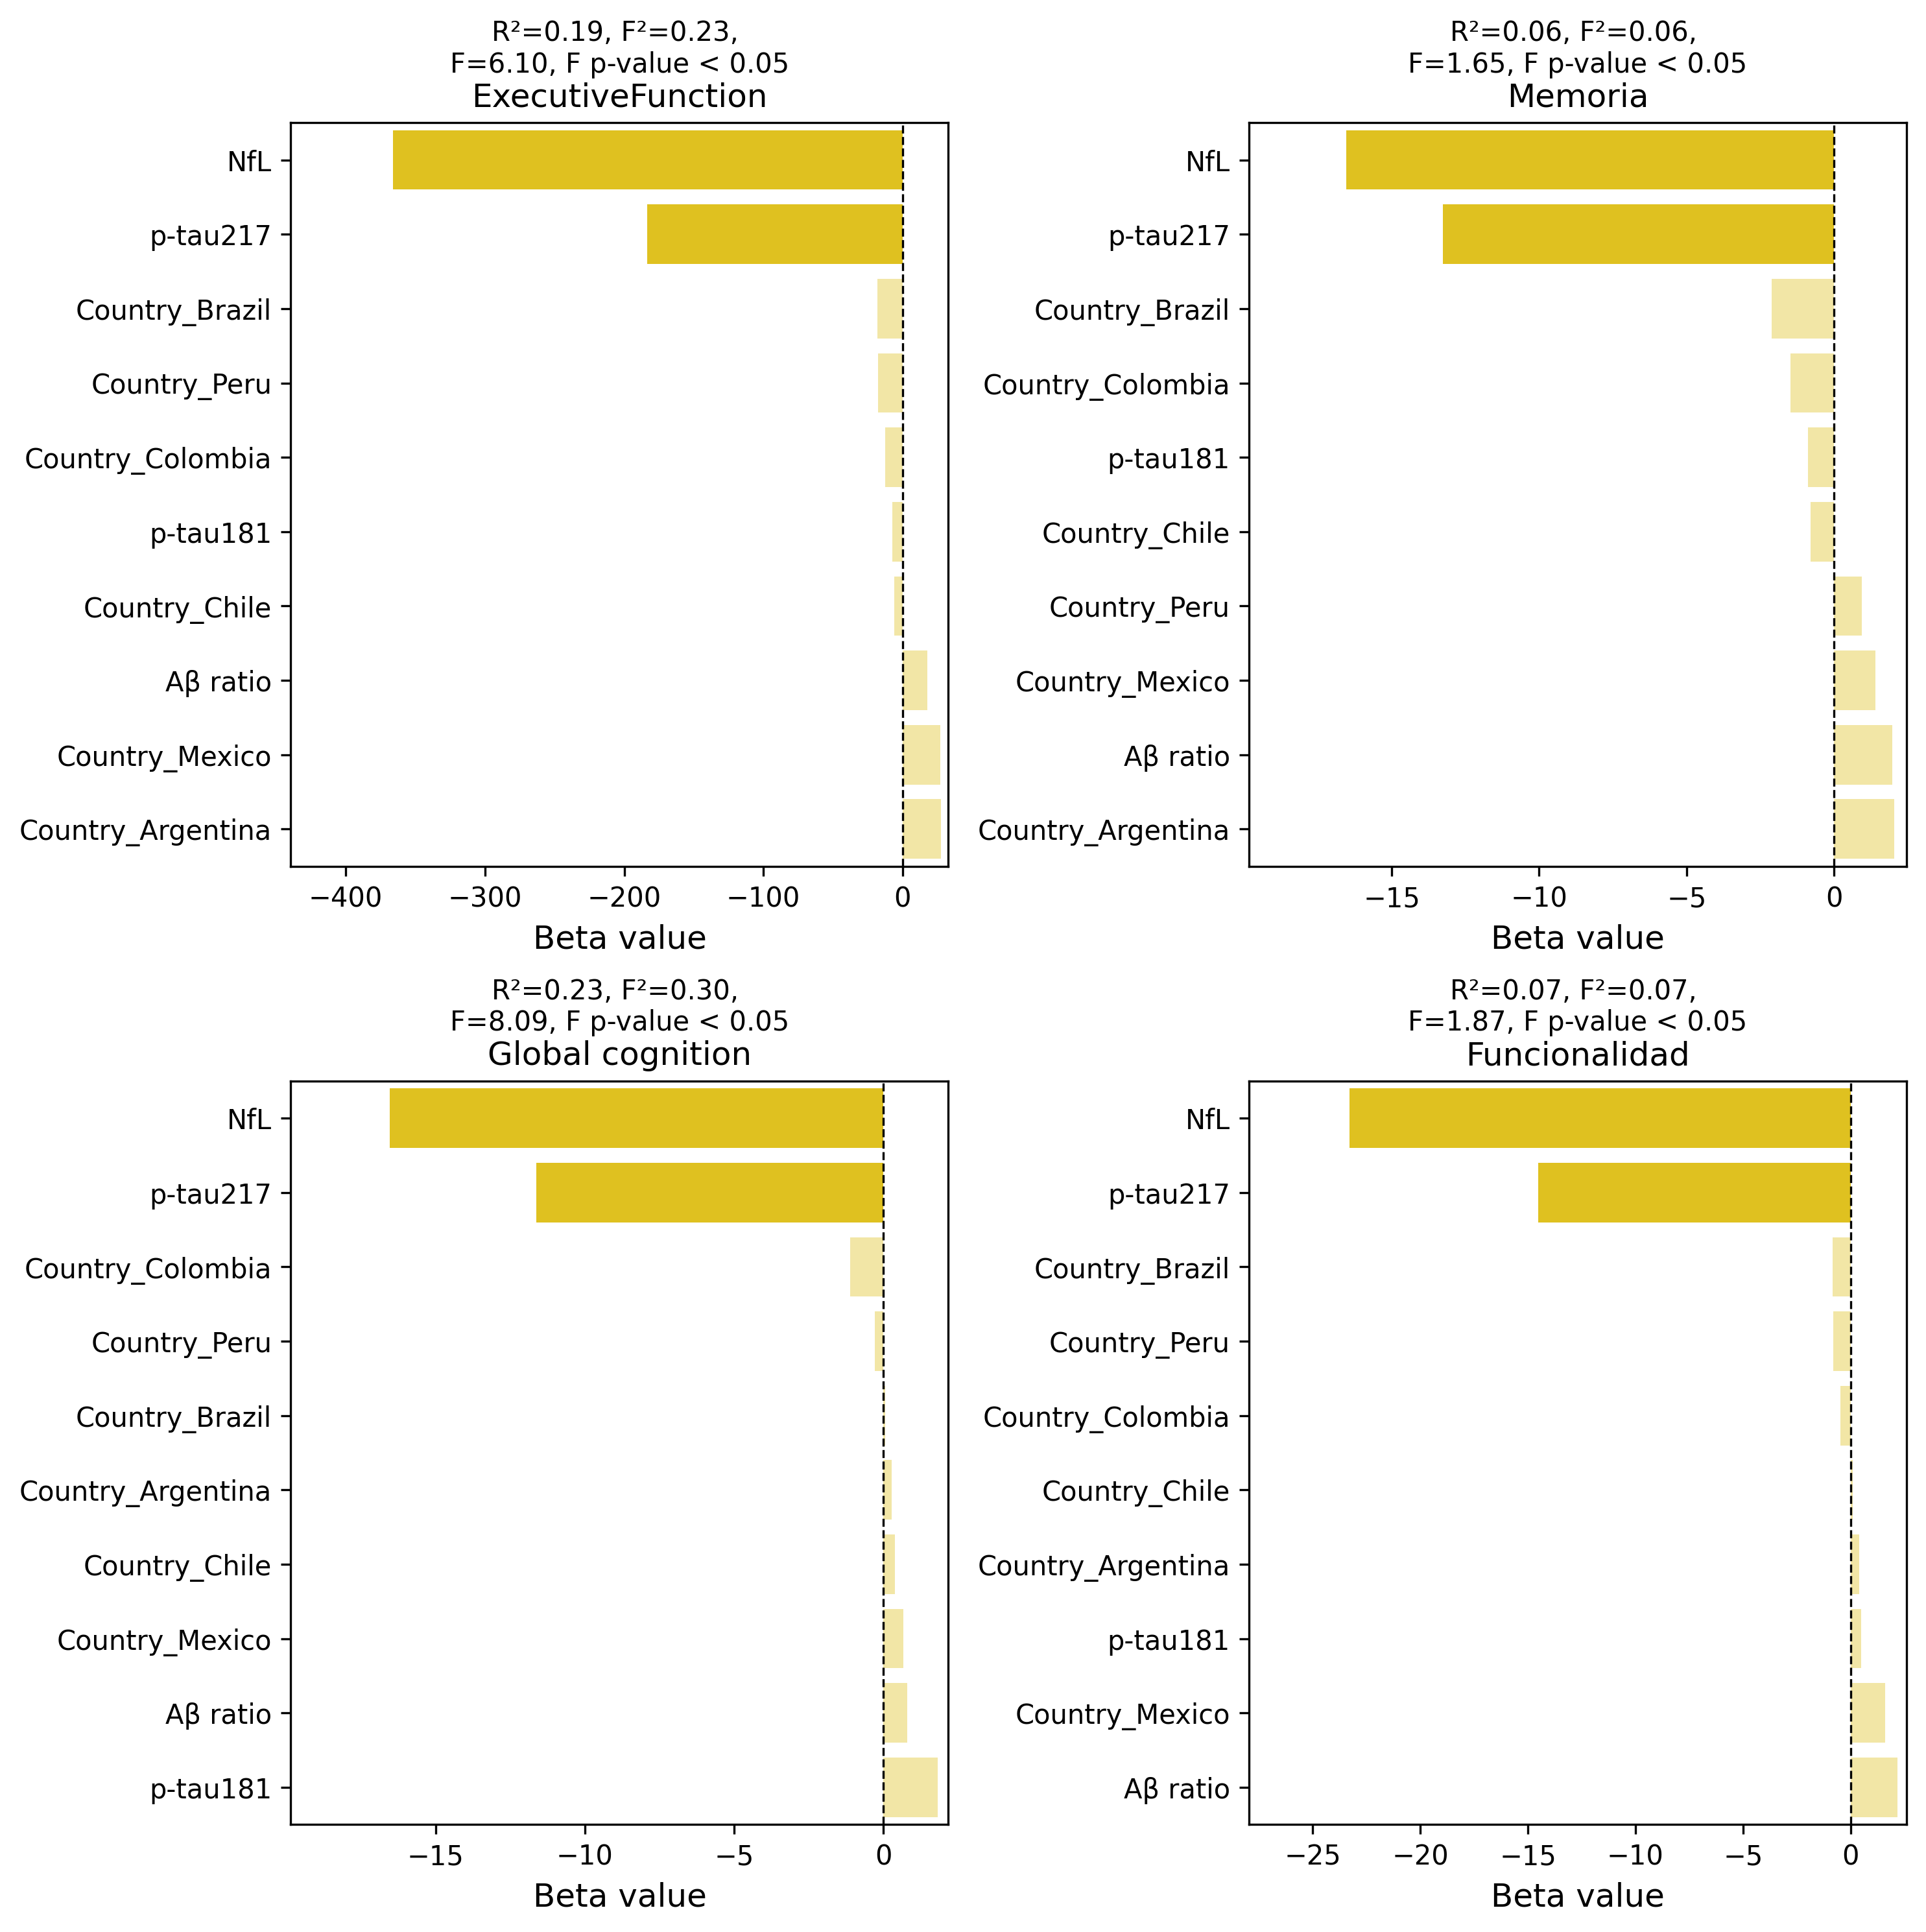

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=300) # Changed subplot layout to 2x2
axes = axes.flatten()

# Define interest_vars outside the loop
interest_vars_analysis = ['Aβ ratio', 'NfL', 'p-tau181', 'p-tau217'] + list(df_cn_dummies.columns)

#for obj_var in  ['Memoria', 'ExecutiveFunction', 'Global cognition', 'Funcionalidad']:
for i, obj_var in enumerate(['ExecutiveFunction', 'Memoria',  'Global cognition', 'Funcionalidad']):
    X_  = df_cn[interest_vars_analysis]
    y   = df_cn[obj_var]

    from skopt import BayesSearchCV

    X_train, X_test, y_train, y_test = train_test_split(X_, y, train_size=0.80, test_size=.20, random_state=0)

    scaler = MinMaxScaler(feature_range=(0.05, 0.95))
    scaling_data = scaler.fit_transform(X_train)
    X_s = pd.DataFrame(scaling_data, columns= X_train.columns, index = X_train.index)
    X_train =  X_s.copy()

    scaler = MinMaxScaler(feature_range=(0.05, 0.95))
    scaling_data = scaler.fit_transform(X_test)
    X_s = pd.DataFrame(scaling_data, columns= X_test.columns, index = X_test.index)
    X_test =  X_s.copy()



    opt_Ridge = BayesSearchCV(
        Ridge(),
        {
            'alpha': ( 0.0001, 0.01, 0.001),
            'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
            'max_iter': (1000, 10000, 100000, 1000000),
            #'tol:' : (1e-6, 1e-3, 1e+1),
            #'n_estimators': (100, 1000),

        },
        n_iter=10,
        cv=3
    )

    opt_Ridge.fit(X_train, y_train)

    print('Ridge')
    print("val. score: %s" % opt_Ridge.best_score_)
    print("test score: %s" % opt_Ridge.score(X_test, y_test))
    print("best parameters: %s" % str(opt_Ridge.best_params_))
    print('---------------------------------------------\n')


    [coef_df_Ridge, r_squared_Ridge, results_labels_df_Ridge] = Regression_Linear(X_, y, 1, 10, n_splits = 5, model = Ridge(**opt_Ridge.best_params_))
    coef_df_Ridge

    coef_df_Ridge.to_excel("Regresion_CN_FTD" + obj_var + ".xlsx")

    df_betas = coef_df_Ridge.iloc[1:, [0, 3]].sort_values(by='Estimate mean', ascending=True)  # Selecting only 'Estimate mean' column and sorting by 'Estimate mean'

    df_betas['label'] = df_betas.index


    ax = axes[i]
    sns.barplot(x='Estimate mean', y='label', data=df_betas, orient='h', ax=ax, palette=np.where(df_betas['p value'] < 0.05, '#FFD700', '#FFEE99')) # Color based on significance (yellow tones)


    ax.set_xlabel('Beta value', fontsize=12)
    ax.set_ylabel('')
    ax.set_title(obj_var, fontsize=12)
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        pass


    # Add a vertical line at x=0
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)

    # Adjust x-axis limits to accommodate labels and zero line
    min_beta = df_betas['Estimate mean'].min()
    max_beta = df_betas['Estimate mean'].max()
    ax.set_xlim(min(min_beta, 0) - abs(min_beta)*0.2, max(max_beta, 0) + abs(max_beta)*0.2)


    # Add R², F², and F values at the top of each subplot
    f_pvalue_text = f"F p-value < 0.05" if coef_df_Ridge.loc['_intercept', 'F-p_value'] < 0.05 else f"F p-value >= 0.05"
    ax.text(0.5, 1.1, f"R²={r_squared_Ridge:.2f}, F²={coef_df_Ridge.loc['_intercept', 'F2']:.2f}, \nF={coef_df_Ridge.loc['_intercept', 'F']:.2f}, {f_pvalue_text}",
            ha='center', va='center', fontsize=10, transform=ax.transAxes)

    print(obj_var, df_betas.iloc[0,0])

# Remove any unused subplots
for j in range(len(['Memoria', 'ExecutiveFunction', 'Global cognition', 'Funcionalidad']), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout, save and show the figure
plt.tight_layout()
plt.savefig("Regression_CN_FTD.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
# @title CN + FTD - Covariating countries, age,sex, ed
df_cn = df[df['diagnosis']!='AD'].copy() # Ensure all columns from df are copied

df_cn.diagnosis.value_counts()



,count
diagnosis,
CN,186
FTD,93


In [ ]:
df_cn = df.copy() # Create a new dataframe for the adjusted analysis

biomarker_vars = ['Aβ ratio', 'NfL', 'p-tau181', 'p-tau217']
# Add sex, age, and education to the list of variables
additional_vars = ['sex', 'age', 'education']

df_all_adjusted[biomarker_vars] = df_all_adjusted[biomarker_vars].astype(float)
# Ensure additional variables are also in float format if necessary, or handle appropriately
df_all_adjusted[additional_vars] = df_all_adjusted[additional_vars].astype(float)


# Include 'Country' in the list of interest variables and create dummy variables
df_all_dummies_adjusted = pd.get_dummies(df_all_adjusted['Country'], prefix='Country')

# Concatenate the original DataFrame (excluding the original 'Country' column) with the dummy variables
df_all_adjusted = pd.concat([df_all_adjusted.drop(columns=['Country']), df_all_dummies_adjusted], axis=1)

# Combine biomarker variables, additional variables, and country dummy variables into interest_vars
interest_vars_adjusted = biomarker_vars + additional_vars + list(df_all_dummies_adjusted.columns)

df_all_adjusted.dropna(inplace=True, subset= interest_vars_adjusted + ['ExecutiveFunction', 'Memoria',  'Global cognition', 'Funcionalidad'])

df_all_adjusted.reset_index(inplace=True, drop = True)
df_all_adjusted.shape

KeyError: 'Country'

Ridge
val. score: 0.33717181374626487
test score: 0.2847663095067894
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 1000000), ('solver', 'lsqr')])
---------------------------------------------

ExecutiveFunction -240.94908345252674
Ridge
val. score: 0.2303160157651304
test score: 0.20868971774676448
best parameters: OrderedDict([('alpha', 0.001), ('max_iter', 100000), ('solver', 'sag')])
---------------------------------------------

Memoria -16.599672243358167
Ridge
val. score: 0.29892146019578275
test score: -0.184106708095241
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 1000000), ('solver', 'sparse_cg')])
---------------------------------------------

Global cognition -13.440716238436597
Ridge
val. score: 0.10154255616113439
test score: 0.20036698340975445
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 1000), ('solver', 'lsqr')])
---------------------------------------------

Funcionalidad -13.65390103093625


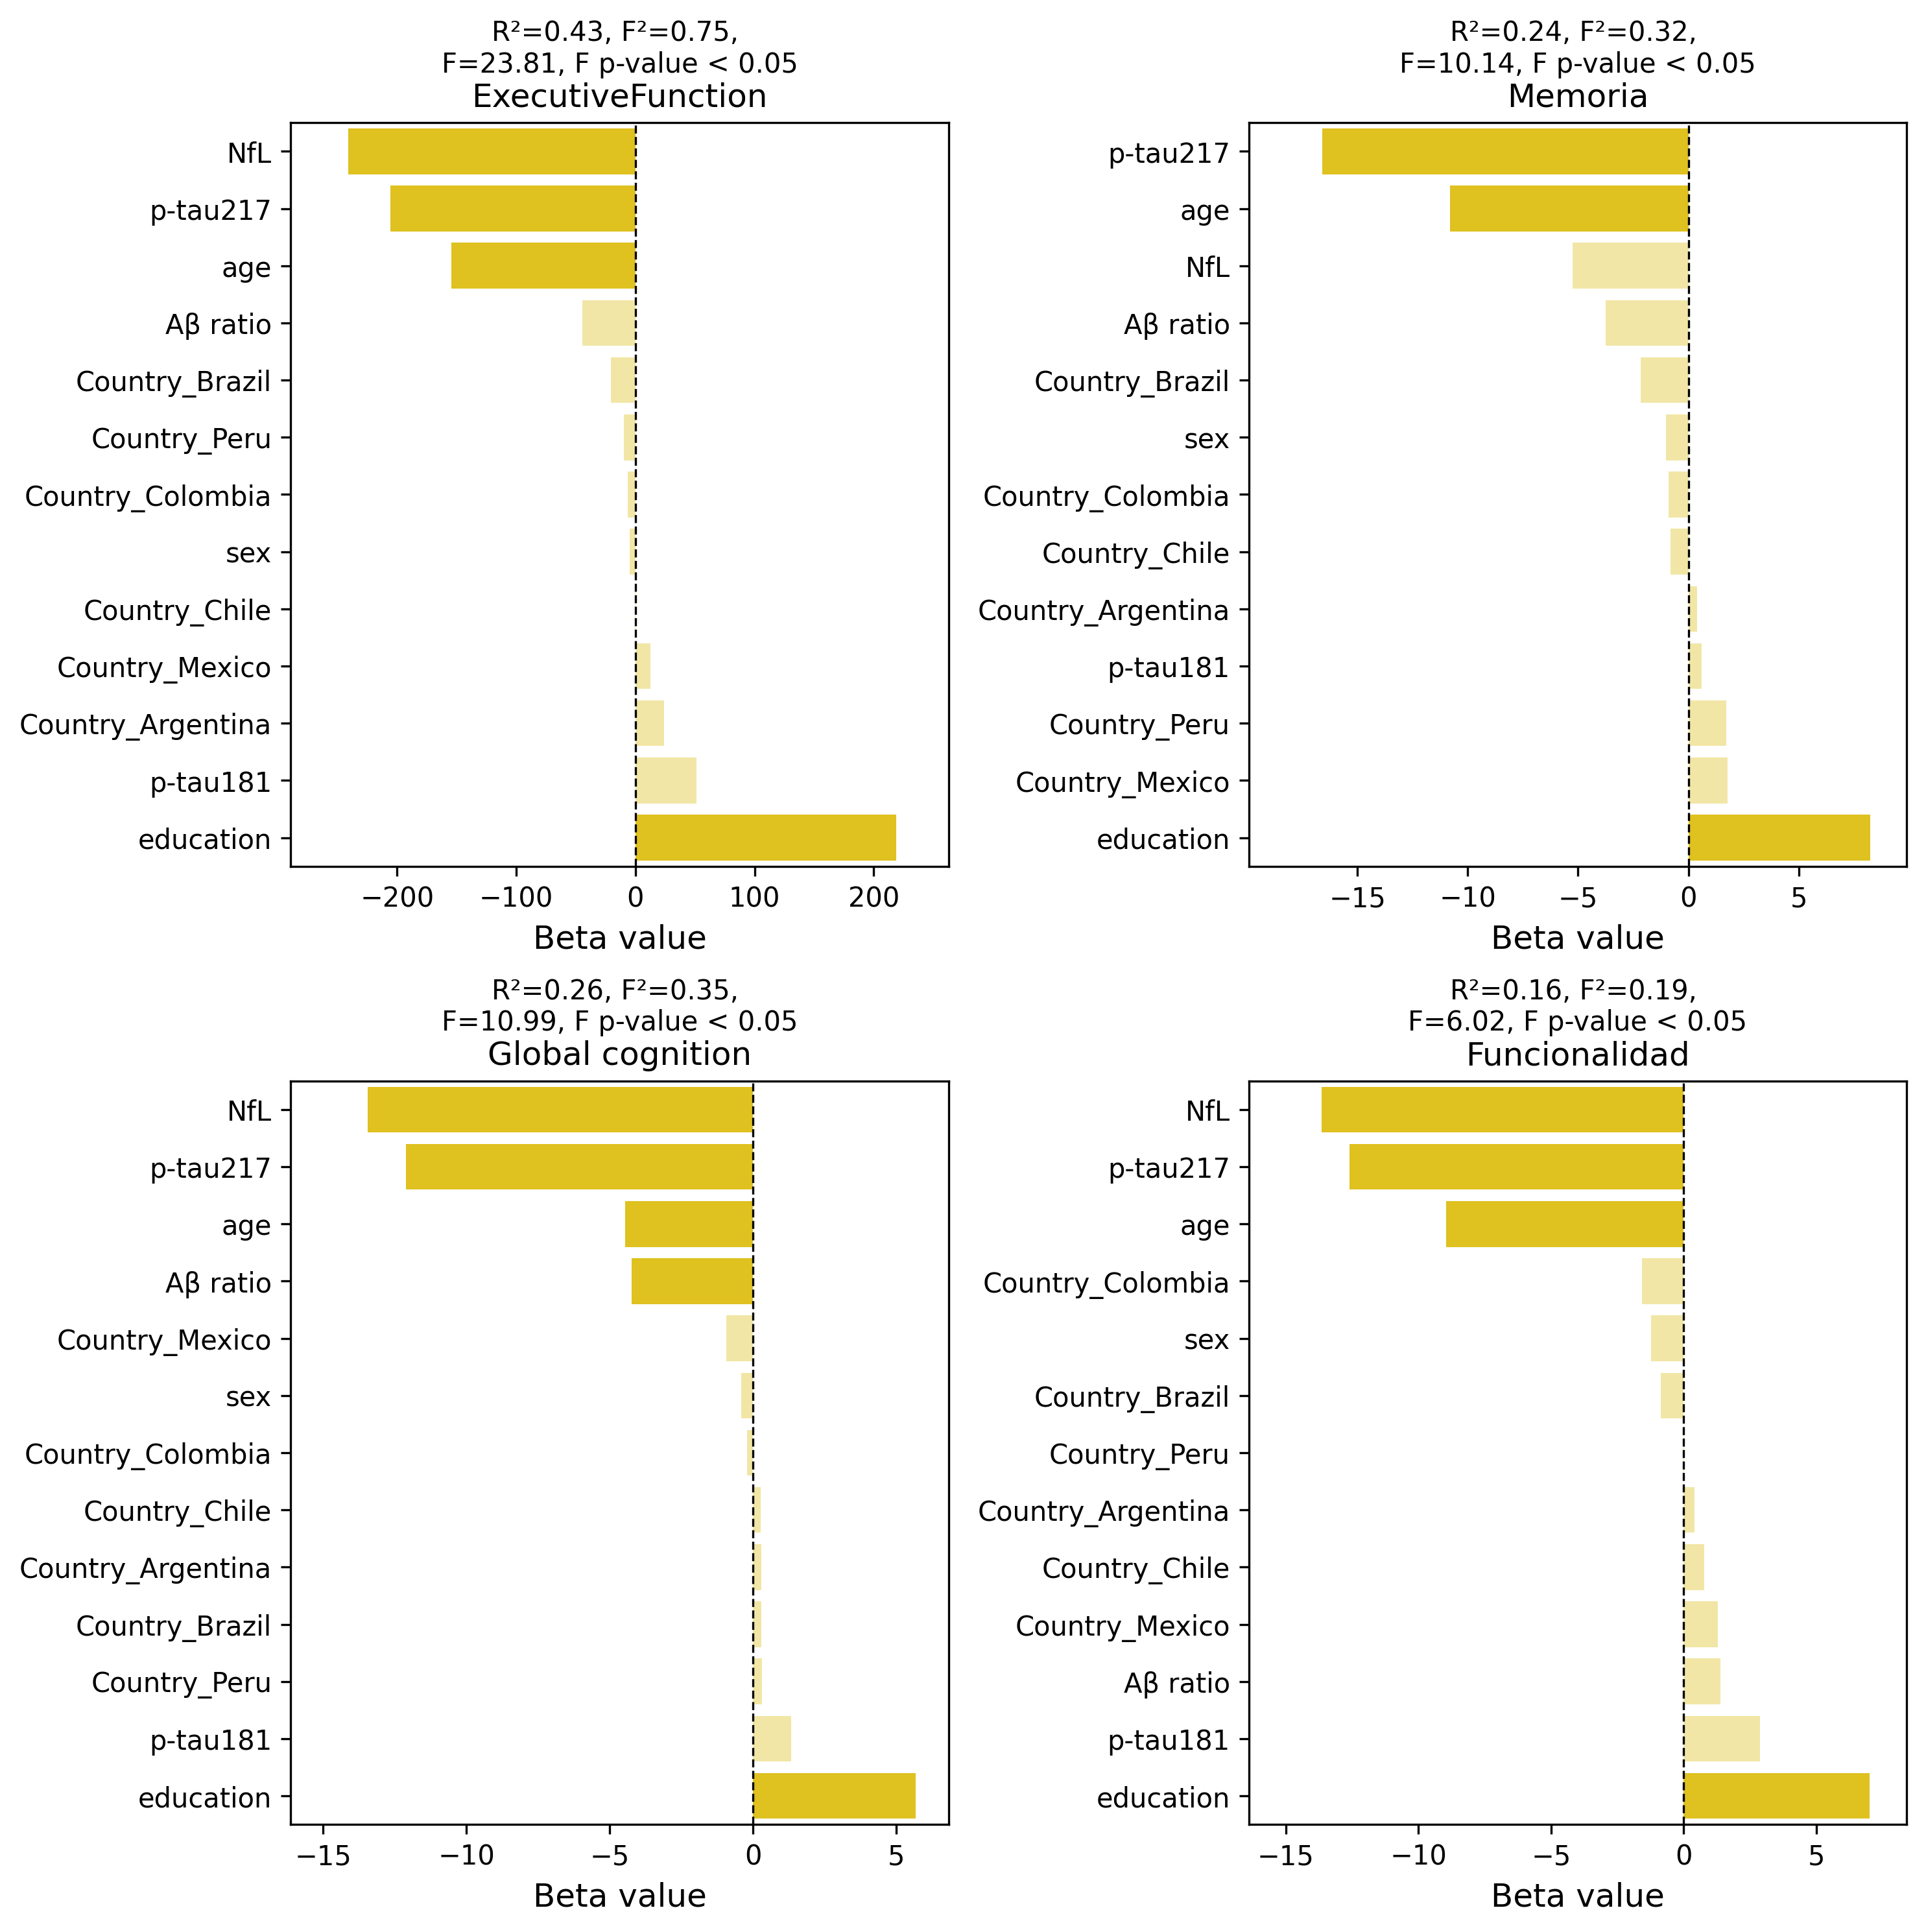

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=300) # Changed subplot layout to 2x2
axes = axes.flatten()

# Define interest_vars outside the loop, including the additional variables
interest_vars_analysis_adjusted = ['Aβ ratio', 'NfL', 'p-tau181', 'p-tau217', 'sex', 'age', 'education'] + list(df_all_dummies_adjusted.columns)

#for obj_var in  ['Memoria', 'ExecutiveFunction', 'Global cognition', 'Funcionalidad']:
for i, obj_var in enumerate(['ExecutiveFunction', 'Memoria',  'Global cognition', 'Funcionalidad']):
    X_  = df_all_adjusted[interest_vars_analysis_adjusted]
    y   = df_all_adjusted[obj_var]

    from skopt import BayesSearchCV

    X_train, X_test, y_train, y_test = train_test_split(X_, y, train_size=0.80, test_size=.20, random_state=0)

    scaler = MinMaxScaler(feature_range=(0.05, 0.95))
    scaling_data = scaler.fit_transform(X_train)
    X_s = pd.DataFrame(scaling_data, columns= X_train.columns, index = X_train.index)
    X_train =  X_s.copy()

    scaler = MinMaxScaler(feature_range=(0.05, 0.95))
    scaling_data = scaler.fit_transform(X_test)
    X_s = pd.DataFrame(scaling_data, columns= X_test.columns, index = X_test.index)
    X_test =  X_s.copy()



    opt_Ridge = BayesSearchCV(
        Ridge(),
        {
            'alpha': ( 0.0001, 0.01, 0.001),
            'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
            'max_iter': (1000, 10000, 100000, 1000000),
            #'tol:' : (1e-6, 1e-3, 1e+1),
            #'n_estimators': (100, 1000),

        },
        n_iter=10,
        cv=3
    )

    opt_Ridge.fit(X_train, y_train)

    print('Ridge')
    print("val. score: %s" % opt_Ridge.best_score_)
    print("test score: %s" % opt_Ridge.score(X_test, y_test))
    print("best parameters: %s" % str(opt_Ridge.best_params_))
    print('---------------------------------------------\n')


    [coef_df_Ridge, r_squared_Ridge, results_labels_df_Ridge] = Regression_Linear(X_, y, 1, 10, n_splits = 5, model = Ridge(**opt_Ridge.best_params_))
    coef_df_Ridge

    coef_df_Ridge.to_excel("Regresion_CN_FTD_adjusted_ALL" + obj_var + ".xlsx")

    df_betas = coef_df_Ridge.iloc[1:, [0, 3]].sort_values(by='Estimate mean', ascending=True)  # Selecting only 'Estimate mean' column and sorting by 'Estimate mean'

    df_betas['label'] = df_betas.index


    ax = axes[i]
    sns.barplot(x='Estimate mean', y='label', data=df_betas, orient='h', ax=ax, palette=np.where(df_betas['p value'] < 0.05, '#FFD700', '#FFEE99')) # Color based on significance (purple tones)


    ax.set_xlabel('Beta value', fontsize=12)
    ax.set_ylabel('')
    ax.set_title(obj_var, fontsize=12)
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        pass


    # Add a vertical line at x=0
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)

    # Adjust x-axis limits to accommodate labels and zero line
    min_beta = df_betas['Estimate mean'].min()
    max_beta = df_betas['Estimate mean'].max()
    ax.set_xlim(min(min_beta, 0) - abs(min_beta)*0.2, max(max_beta, 0) + abs(max_beta)*0.2)


    # Add R², F², and F values at the top of each subplot
    f_pvalue_text = f"F p-value < 0.05" if coef_df_Ridge.loc['_intercept', 'F-p_value'] < 0.05 else f"F p-value >= 0.05"
    ax.text(0.5, 1.1, f"R²={r_squared_Ridge:.2f}, F²={coef_df_Ridge.loc['_intercept', 'F2']:.2f}, \nF={coef_df_Ridge.loc['_intercept', 'F']:.2f}, {f_pvalue_text}",
            ha='center', va='center', fontsize=10, transform=ax.transAxes)


    print(obj_var, df_betas.iloc[0,0])

# Remove any unused subplots
for j in range(len(['Memoria', 'ExecutiveFunction', 'Global cognition', 'Funcionalidad']), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout, save and show the figure
plt.tight_layout()
plt.savefig("Regression_CN_FTD_adjusted_ALLL.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
# @title CN + AD + FTD Analysis - Covariating by countries
df_all = df.copy()
df_all.diagnosis.value_counts()

,count
diagnosis,
CN,186
AD,148
FTD,93


In [ ]:
biomarker_vars = ['Aβ ratio', 'NfL', 'p-tau181', 'p-tau217']

df_all[biomarker_vars] = df_all[biomarker_vars].astype(float)

# Include 'Country' in the list of interest variables and create dummy variables
df_all_dummies = pd.get_dummies(df_all['Country'], prefix='Country')

# Concatenate the original DataFrame (excluding the original 'Country' column) with the dummy variables
df_all = pd.concat([df_all.drop(columns=['Country']), df_all_dummies], axis=1)

# Combine biomarker variables and country dummy variables into interest_vars
interest_vars = biomarker_vars + list(df_all_dummies.columns)

df_all.dropna(inplace=True, subset= interest_vars + ['ExecutiveFunction', 'Memoria',  'Global cognition', 'Funcionalidad'])

df_all.reset_index(inplace=True, drop = True)
df_all.shape

(427, 261)

Ridge
val. score: 0.08672601891646163
test score: -0.39823456407900415
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 1000000), ('solver', 'lsqr')])
---------------------------------------------

ExecutiveFunction -376.1752687362872
Ridge
val. score: 0.13962834919947278
test score: -0.11223546962696451
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 1000), ('solver', 'auto')])
---------------------------------------------

Memoria -15.947164062869826
Ridge
val. score: 0.19102898537569743
test score: -0.5778944040577179
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 1000), ('solver', 'sparse_cg')])
---------------------------------------------

Global cognition -17.12844206861921
Ridge
val. score: 0.03447283092818435
test score: 0.01074326190633268
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 1000), ('solver', 'saga')])
---------------------------------------------

Funcionalidad -20.06474162904702


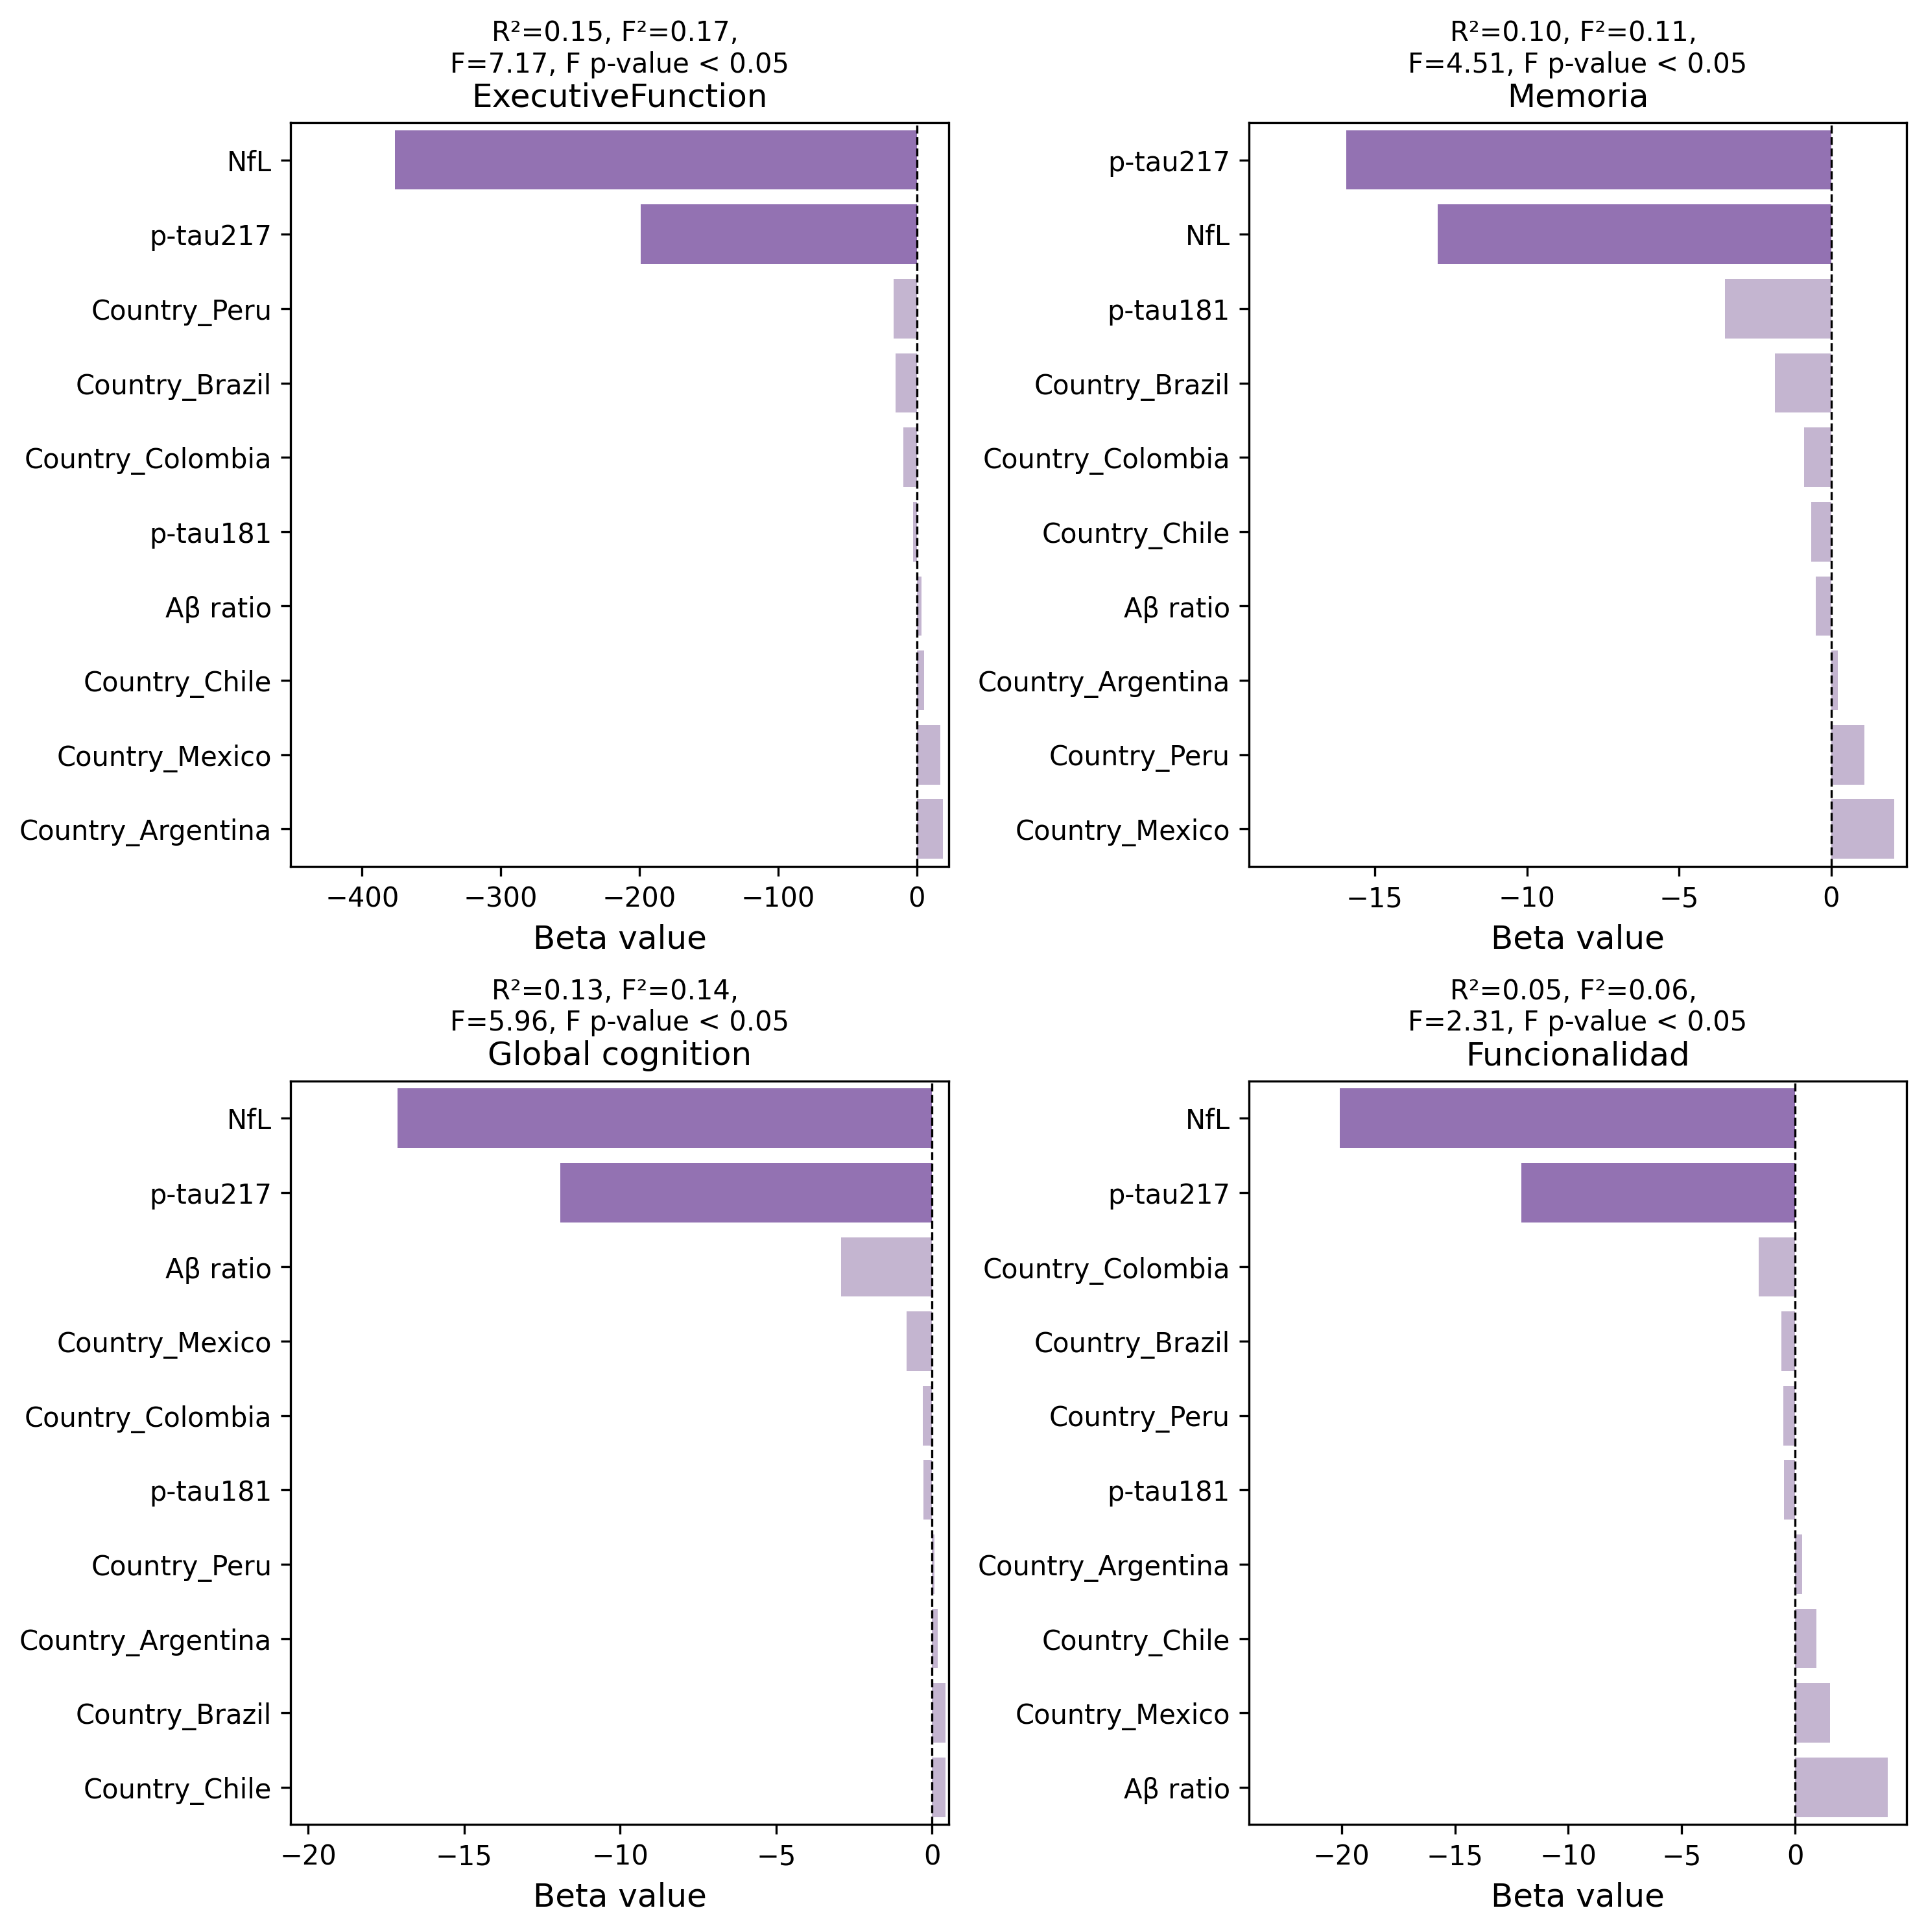

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=300) # Changed subplot layout to 2x2
axes = axes.flatten()

# Define interest_vars outside the loop
interest_vars_analysis = ['Aβ ratio', 'NfL', 'p-tau181', 'p-tau217'] + list(df_all_dummies.columns)

#for obj_var in  ['Memoria', 'ExecutiveFunction', 'Global cognition', 'Funcionalidad']:
for i, obj_var in enumerate(['ExecutiveFunction', 'Memoria',  'Global cognition', 'Funcionalidad']):
    X_  = df_all[interest_vars_analysis]
    y   = df_all[obj_var]

    from skopt import BayesSearchCV

    X_train, X_test, y_train, y_test = train_test_split(X_, y, train_size=0.80, test_size=.20, random_state=0)

    scaler = MinMaxScaler(feature_range=(0.05, 0.95))
    scaling_data = scaler.fit_transform(X_train)
    X_s = pd.DataFrame(scaling_data, columns= X_train.columns, index = X_train.index)
    X_train =  X_s.copy()

    scaler = MinMaxScaler(feature_range=(0.05, 0.95))
    scaling_data = scaler.fit_transform(X_test)
    X_s = pd.DataFrame(scaling_data, columns= X_test.columns, index = X_test.index)
    X_test =  X_s.copy()



    opt_Ridge = BayesSearchCV(
        Ridge(),
        {
            'alpha': ( 0.0001, 0.01, 0.001),
            'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
            'max_iter': (1000, 10000, 100000, 1000000),
            #'tol:' : (1e-6, 1e-3, 1e+1),
            #'n_estimators': (100, 1000),

        },
        n_iter=10,
        cv=3
    )

    opt_Ridge.fit(X_train, y_train)

    print('Ridge')
    print("val. score: %s" % opt_Ridge.best_score_)
    print("test score: %s" % opt_Ridge.score(X_test, y_test))
    print("best parameters: %s" % str(opt_Ridge.best_params_))
    print('---------------------------------------------\n')


    [coef_df_Ridge, r_squared_Ridge, results_labels_df_Ridge] = Regression_Linear(X_, y, 1, 10, n_splits = 5, model = Ridge(**opt_Ridge.best_params_))
    coef_df_Ridge

    coef_df_Ridge.to_excel("Regresion_CN_AD_FTD" + obj_var + ".xlsx")

    df_betas = coef_df_Ridge.iloc[1:, [0, 3]].sort_values(by='Estimate mean', ascending=True)  # Selecting only 'Estimate mean' column and sorting by 'Estimate mean'

    df_betas['label'] = df_betas.index


    ax = axes[i]
    sns.barplot(x='Estimate mean', y='label', data=df_betas, orient='h', ax=ax, palette=np.where(df_betas['p value'] < 0.05, '#9467bd', '#c5b0d5')) # Color based on significance (purple tones)


    ax.set_xlabel('Beta value', fontsize=12)
    ax.set_ylabel('')
    ax.set_title(obj_var, fontsize=12)
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        pass


    # Add a vertical line at x=0
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)

    # Adjust x-axis limits to accommodate labels and zero line
    min_beta = df_betas['Estimate mean'].min()
    max_beta = df_betas['Estimate mean'].max()
    ax.set_xlim(min(min_beta, 0) - abs(min_beta)*0.2, max(max_beta, 0) + abs(max_beta)*0.2)


    # Add R², F², and F values at the top of each subplot
    f_pvalue_text = f"F p-value < 0.05" if coef_df_Ridge.loc['_intercept', 'F-p_value'] < 0.05 else f"F p-value >= 0.05"
    ax.text(0.5, 1.1, f"R²={r_squared_Ridge:.2f}, F²={coef_df_Ridge.loc['_intercept', 'F2']:.2f}, \nF={coef_df_Ridge.loc['_intercept', 'F']:.2f}, {f_pvalue_text}",
            ha='center', va='center', fontsize=10, transform=ax.transAxes)


    print(obj_var, df_betas.iloc[0,0])

# Remove any unused subplots
for j in range(len(['Memoria', 'ExecutiveFunction', 'Global cognition', 'Funcionalidad']), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout, save and show the figure
plt.tight_layout()
plt.savefig("Regression_CN_AD_FTD.pdf", format="pdf", bbox_inches="tight")
plt.show()

## CN + AD + FTD Analysis - Covariating by countries, sex, age and education

In [ ]:
df_all_adjusted = df.copy() # Create a new dataframe for the adjusted analysis

biomarker_vars = ['Aβ ratio', 'NfL', 'p-tau181', 'p-tau217']
# Add sex, age, and education to the list of variables
additional_vars = ['sex', 'age', 'education']

df_all_adjusted[biomarker_vars] = df_all_adjusted[biomarker_vars].astype(float)
# Ensure additional variables are also in float format if necessary, or handle appropriately
df_all_adjusted[additional_vars] = df_all_adjusted[additional_vars].astype(float)


# Include 'Country' in the list of interest variables and create dummy variables
df_all_dummies_adjusted = pd.get_dummies(df_all_adjusted['Country'], prefix='Country')

# Concatenate the original DataFrame (excluding the original 'Country' column) with the dummy variables
df_all_adjusted = pd.concat([df_all_adjusted.drop(columns=['Country']), df_all_dummies_adjusted], axis=1)

# Combine biomarker variables, additional variables, and country dummy variables into interest_vars
interest_vars_adjusted = biomarker_vars + additional_vars + list(df_all_dummies_adjusted.columns)

df_all_adjusted.dropna(inplace=True, subset= interest_vars_adjusted + ['ExecutiveFunction', 'Memoria',  'Global cognition', 'Funcionalidad'])

df_all_adjusted.reset_index(inplace=True, drop = True)
df_all_adjusted.shape

(427, 261)

Ridge
val. score: 0.33717181374626487
test score: 0.2847663095067894
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 1000000), ('solver', 'lsqr')])
---------------------------------------------

ExecutiveFunction -240.94908345252674
Ridge
val. score: 0.23065296539695904
test score: 0.2099536741542869
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 1000000), ('solver', 'lsqr')])
---------------------------------------------

Memoria -16.565109819223245
Ridge
val. score: 0.29897540907389725
test score: -0.18395359299986525
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 10000), ('solver', 'saga')])
---------------------------------------------

Global cognition -13.437349689310205
Ridge
val. score: 0.10154255616113439
test score: 0.20036698340975445
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 10000), ('solver', 'lsqr')])
---------------------------------------------

Funcionalidad -13.65390103093625


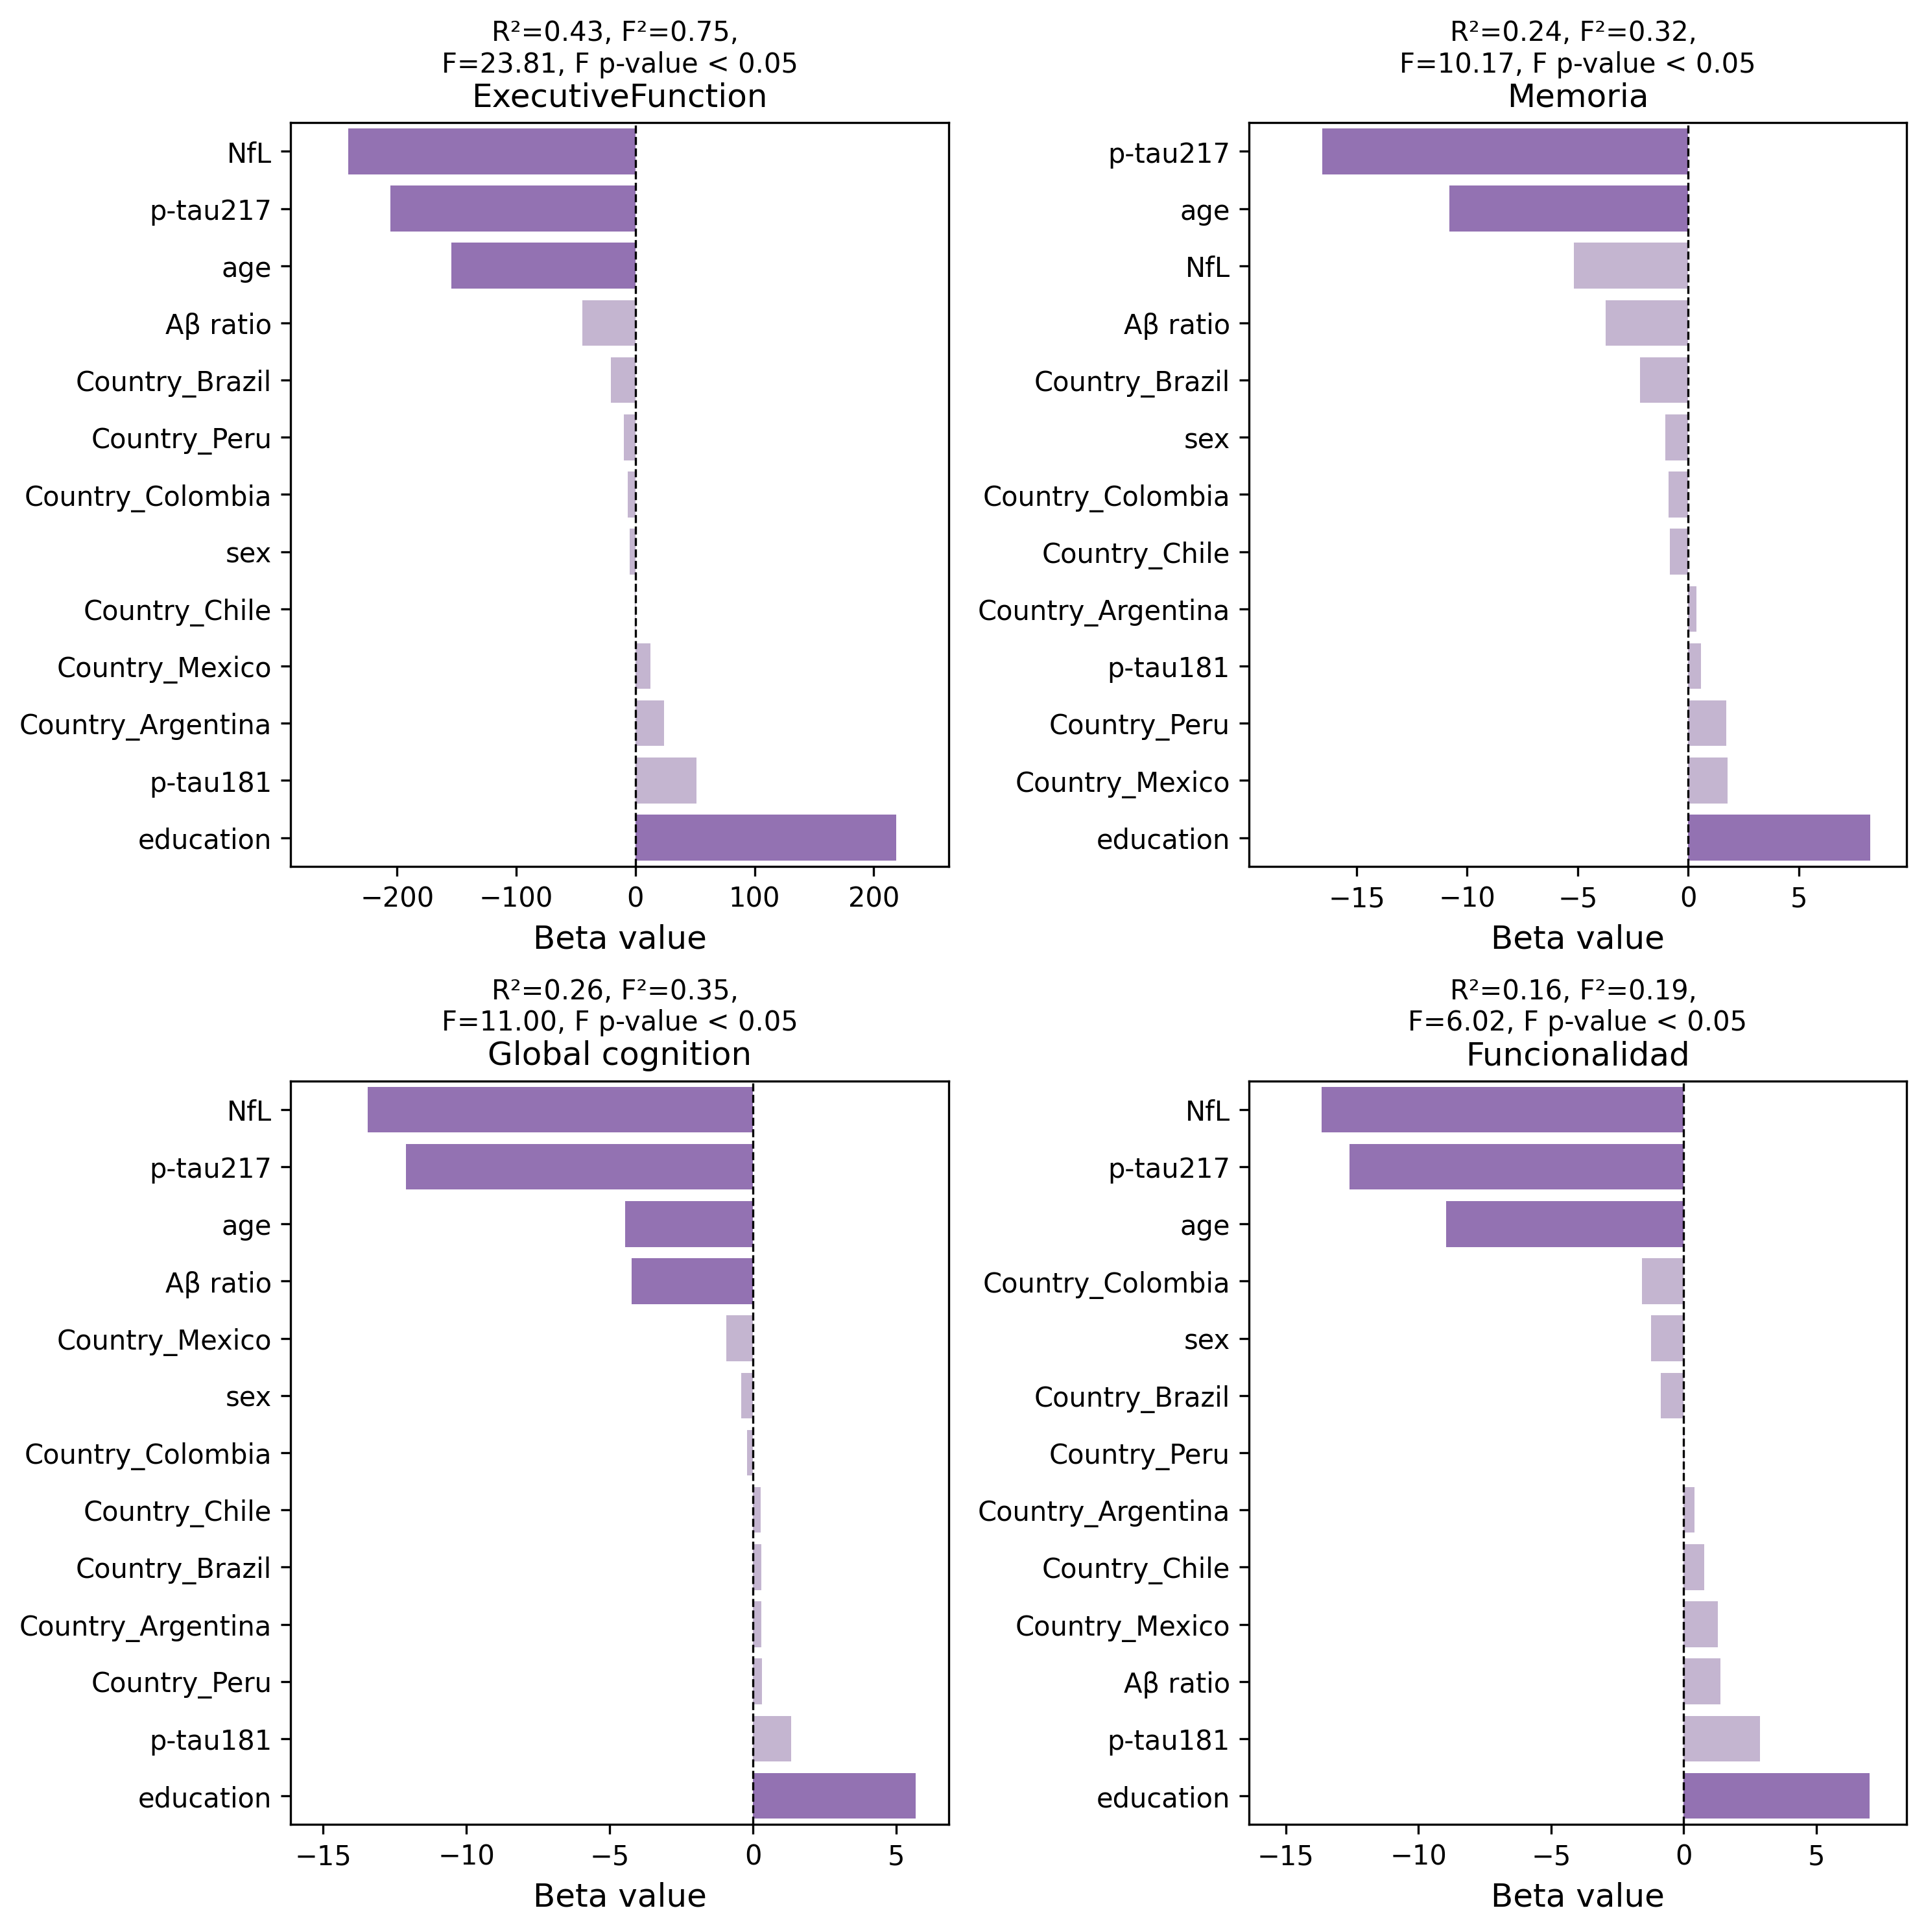

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=300) # Changed subplot layout to 2x2
axes = axes.flatten()

# Define interest_vars outside the loop, including the additional variables
interest_vars_analysis_adjusted = ['Aβ ratio', 'NfL', 'p-tau181', 'p-tau217', 'sex', 'age', 'education'] + list(df_all_dummies_adjusted.columns)

#for obj_var in  ['Memoria', 'ExecutiveFunction', 'Global cognition', 'Funcionalidad']:
for i, obj_var in enumerate(['ExecutiveFunction', 'Memoria',  'Global cognition', 'Funcionalidad']):
    X_  = df_all_adjusted[interest_vars_analysis_adjusted]
    y   = df_all_adjusted[obj_var]

    from skopt import BayesSearchCV

    X_train, X_test, y_train, y_test = train_test_split(X_, y, train_size=0.80, test_size=.20, random_state=0)

    scaler = MinMaxScaler(feature_range=(0.05, 0.95))
    scaling_data = scaler.fit_transform(X_train)
    X_s = pd.DataFrame(scaling_data, columns= X_train.columns, index = X_train.index)
    X_train =  X_s.copy()

    scaler = MinMaxScaler(feature_range=(0.05, 0.95))
    scaling_data = scaler.fit_transform(X_test)
    X_s = pd.DataFrame(scaling_data, columns= X_test.columns, index = X_test.index)
    X_test =  X_s.copy()



    opt_Ridge = BayesSearchCV(
        Ridge(),
        {
            'alpha': ( 0.0001, 0.01, 0.001),
            'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
            'max_iter': (1000, 10000, 100000, 1000000),
            #'tol:' : (1e-6, 1e-3, 1e+1),
            #'n_estimators': (100, 1000),

        },
        n_iter=10,
        cv=3
    )

    opt_Ridge.fit(X_train, y_train)

    print('Ridge')
    print("val. score: %s" % opt_Ridge.best_score_)
    print("test score: %s" % opt_Ridge.score(X_test, y_test))
    print("best parameters: %s" % str(opt_Ridge.best_params_))
    print('---------------------------------------------\n')


    [coef_df_Ridge, r_squared_Ridge, results_labels_df_Ridge] = Regression_Linear(X_, y, 1, 10, n_splits = 5, model = Ridge(**opt_Ridge.best_params_))
    coef_df_Ridge

    coef_df_Ridge.to_excel("Regresion_CN_AD_FTD_adjusted_" + obj_var + ".xlsx")

    df_betas = coef_df_Ridge.iloc[1:, [0, 3]].sort_values(by='Estimate mean', ascending=True)  # Selecting only 'Estimate mean' column and sorting by 'Estimate mean'

    df_betas['label'] = df_betas.index


    ax = axes[i]
    sns.barplot(x='Estimate mean', y='label', data=df_betas, orient='h', ax=ax, palette=np.where(df_betas['p value'] < 0.05, '#9467bd', '#c5b0d5')) # Color based on significance (purple tones)


    ax.set_xlabel('Beta value', fontsize=12)
    ax.set_ylabel('')
    ax.set_title(obj_var, fontsize=12)
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        pass


    # Add a vertical line at x=0
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)

    # Adjust x-axis limits to accommodate labels and zero line
    min_beta = df_betas['Estimate mean'].min()
    max_beta = df_betas['Estimate mean'].max()
    ax.set_xlim(min(min_beta, 0) - abs(min_beta)*0.2, max(max_beta, 0) + abs(max_beta)*0.2)


    # Add R², F², and F values at the top of each subplot
    f_pvalue_text = f"F p-value < 0.05" if coef_df_Ridge.loc['_intercept', 'F-p_value'] < 0.05 else f"F p-value >= 0.05"
    ax.text(0.5, 1.1, f"R²={r_squared_Ridge:.2f}, F²={coef_df_Ridge.loc['_intercept', 'F2']:.2f}, \nF={coef_df_Ridge.loc['_intercept', 'F']:.2f}, {f_pvalue_text}",
            ha='center', va='center', fontsize=10, transform=ax.transAxes)


    print(obj_var, df_betas.iloc[0,0])

# Remove any unused subplots
for j in range(len(['Memoria', 'ExecutiveFunction', 'Global cognition', 'Funcionalidad']), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout, save and show the figure
plt.tight_layout()
plt.savefig("Regression_CN_AD_FTD_adjusted.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
# @title CN + AD matcheados covariate country, age, sex, ed
df

df2= pd.read_csv('matched_data_with_ids_CN_AD.csv')

# Identify columns to drop from df2 before merging to prevent suffix issues
# Assuming 'record_id' is the only column that should be in both dataframes and used for merging
cols_to_drop_from_df2 = ['diagnosis', 'age', 'sex', 'education', 'distance', 'weights', 'subclass'] # These columns have _y suffix

df_matched_ad = pd.merge(df, df2.drop(columns=cols_to_drop_from_df2), on='record_id', how='inner')

df_matched_ad['diagnosis'].value_counts()

df = df_matched_ad

,record_id,site,Country,cdr_date,cdr_examiner,cdr_means,cdr_memory,cdr_orient,cdr_prblm,cdr_cmnaff,...,p-tau217,sex,age,education,diagnosis,mmse_educ,Memoria,ExecutiveFunction,Global cognition,Funcionalidad
0,AF023,Avila,Mexico,2021-08-28,DDuron,1.0,0.0,0.0,0.0,0.0,...,0.194,1.0,72.0,6.0,CN,168.0,11.0,0.0,28.0,33.0
1,AF025,Avila,Mexico,2021-08-29,DDuron,1.0,0.0,0.0,0.0,0.0,...,0.112,2.0,75.0,16.0,CN,464.0,11.0,103.0,29.0,33.0
2,AF045,Avila,Mexico,2021-12-01,DDuron,1.0,0.0,0.0,0.0,0.0,...,0.185,2.0,62.0,18.0,CN,540.0,11.0,0.0,30.0,33.0
3,AF061,Avila,Mexico,2021-10-26,DDuron,1.0,0.0,0.0,0.0,0.0,...,0.112,1.0,61.0,20.0,CN,560.0,9.0,52.0,28.0,33.0
4,AF081,Avila,Mexico,2022-03-09,DDuron,1.0,0.0,0.0,0.0,0.0,...,0.117,2.0,64.0,16.0,CN,464.0,14.0,200.0,29.0,33.0
5,AF097,Avila,Mexico,2022-03-22,DDuron,1.0,0.0,0.0,0.0,0.0,...,0.086,2.0,67.0,17.0,CN,510.0,14.0,228.0,30.0,33.0
6,AF133,Avila,Mexico,2022-04-22,DDuron,1.0,0.0,0.0,0.0,0.0,...,0.078,1.0,64.0,13.0,CN,364.0,13.0,215.0,28.0,33.0
7,AF135,Avila,Mexico,2022-04-22,DDuron,1.0,0.0,0.0,0.0,0.0,...,0.059,1.0,66.0,12.0,CN,312.0,10.0,210.0,26.0,33.0
8,AF145,Avila,Mexico,2022-05-04,DDuron,1.0,0.0,0.0,0.0,0.0,...,0.105,1.0,51.0,11.0,CN,308.0,20.0,212.0,28.0,33.0
9,BE00184,Behrens,Chile,2022-01-13,MIBehrens,1.0,0.0,0.0,0.0,0.0,...,0.262,2.0,78.0,12.0,CN,360.0,9.0,150.0,30.0,32.0


In [ ]:
# @title CN + FTD - Covariating countries, age,sex, ed (Fixed)
df_all_adjusted = df.copy() # Create a new dataframe for the adjusted analysis from the original df



# Filter the dataframe to include only CN and FTD diagnoses
df_all_adjusted = df_all_adjusted[df_all_adjusted['diagnosis'].isin(['CN', 'FTD'])].copy()


biomarker_vars = ['Aβ ratio', 'NfL', 'p-tau181', 'p-tau217']
# Add sex, age, and education to the list of variables
additional_vars = ['sex', 'age', 'education']

df_all_adjusted[biomarker_vars] = df_all_adjusted[biomarker_vars].astype(float)
# Ensure additional variables are also in float format if necessary, or handle appropriately
df_all_adjusted[additional_vars] = df_all_adjusted[additional_vars].astype(float)


# Include 'Country' in the list of interest variables and create dummy variables
df_all_dummies_adjusted = pd.get_dummies(df_all_adjusted['Country'], prefix='Country')

# Concatenate the original DataFrame (excluding the original 'Country' column) with the dummy variables
df_all_adjusted = pd.concat([df_all_adjusted.drop(columns=['Country']), df_all_dummies_adjusted], axis=1)

# Combine biomarker variables, additional variables, and country dummy variables into interest_vars
interest_vars_adjusted = biomarker_vars + additional_vars + list(df_all_dummies_adjusted.columns)

df_all_adjusted.dropna(inplace=True, subset= interest_vars_adjusted + ['ExecutiveFunction', 'Memoria',  'Global cognition', 'Funcionalidad'])

df_all_adjusted.reset_index(inplace=True, drop = True)
df_all_adjusted.shape

,record_id,site,cdr_date,cdr_examiner,cdr_means,cdr_memory,cdr_orient,cdr_prblm,cdr_cmnaff,cdr_hobby,...,Memoria,ExecutiveFunction,Global cognition,Funcionalidad,Country_Argentina,Country_Brazil,Country_Chile,Country_Colombia,Country_Mexico,Country_Peru
0,AF023,Avila,2021-08-28,DDuron,1.0,0.0,0.0,0.0,0.0,0.0,...,11.0,0.0,28.0,33.0,False,False,False,False,True,False
1,AF025,Avila,2021-08-29,DDuron,1.0,0.0,0.0,0.0,0.0,0.0,...,11.0,103.0,29.0,33.0,False,False,False,False,True,False
2,AF033,Avila,2021-11-15,DDuron,1.0,0.0,0.0,0.0,0.0,0.0,...,18.0,231.0,28.0,33.0,False,False,False,False,True,False
3,AF039,Avila,2021-11-24,DDuron,1.0,0.0,0.0,0.0,0.0,0.0,...,12.0,239.0,28.0,33.0,False,False,False,False,True,False
4,AF045,Avila,2021-12-01,DDuron,1.0,0.0,0.0,0.0,0.0,0.0,...,11.0,0.0,30.0,33.0,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,RE041,NaN,2023-07-28 00:00:00,LASaraiva,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,211.0,26.0,20.0,False,True,False,False,False,False
275,RE049,NaN,2023-12-07 00:00:00,LASaraiva,1.0,0.5,0.0,1.0,1.0,2.0,...,15.0,0.0,25.0,17.0,False,True,False,False,False,False
276,RE054,NaN,2023-11-24 00:00:00,LASaraiva,1.0,0.5,0.5,1.0,1.0,1.0,...,5.0,0.0,27.0,23.0,False,True,False,False,False,False
277,RE067,NaN,2024-03-22 00:00:00,LASaraiva,1.0,1.0,0.5,0.5,0.5,0.5,...,11.0,70.0,25.0,30.0,False,True,False,False,False,False


Ridge
val. score: 0.33234711212354395
test score: 0.41568013763700074
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 1000000), ('solver', 'auto')])
---------------------------------------------

ExecutiveFunction -268.5172574811155
Ridge
val. score: 0.1132278354290422
test score: -0.11403936805817261
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 10000), ('solver', 'lsqr')])
---------------------------------------------

Memoria -13.752359711863793
Ridge
val. score: 0.10384175867852101
test score: 0.2366793134943015
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 1000), ('solver', 'lsqr')])
---------------------------------------------

Global cognition -14.96801707629831
Ridge
val. score: 0.09381422203298317
test score: 0.12351048113386065
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 1000000), ('solver', 'saga')])
---------------------------------------------

Funcionalidad -20.418737296496808


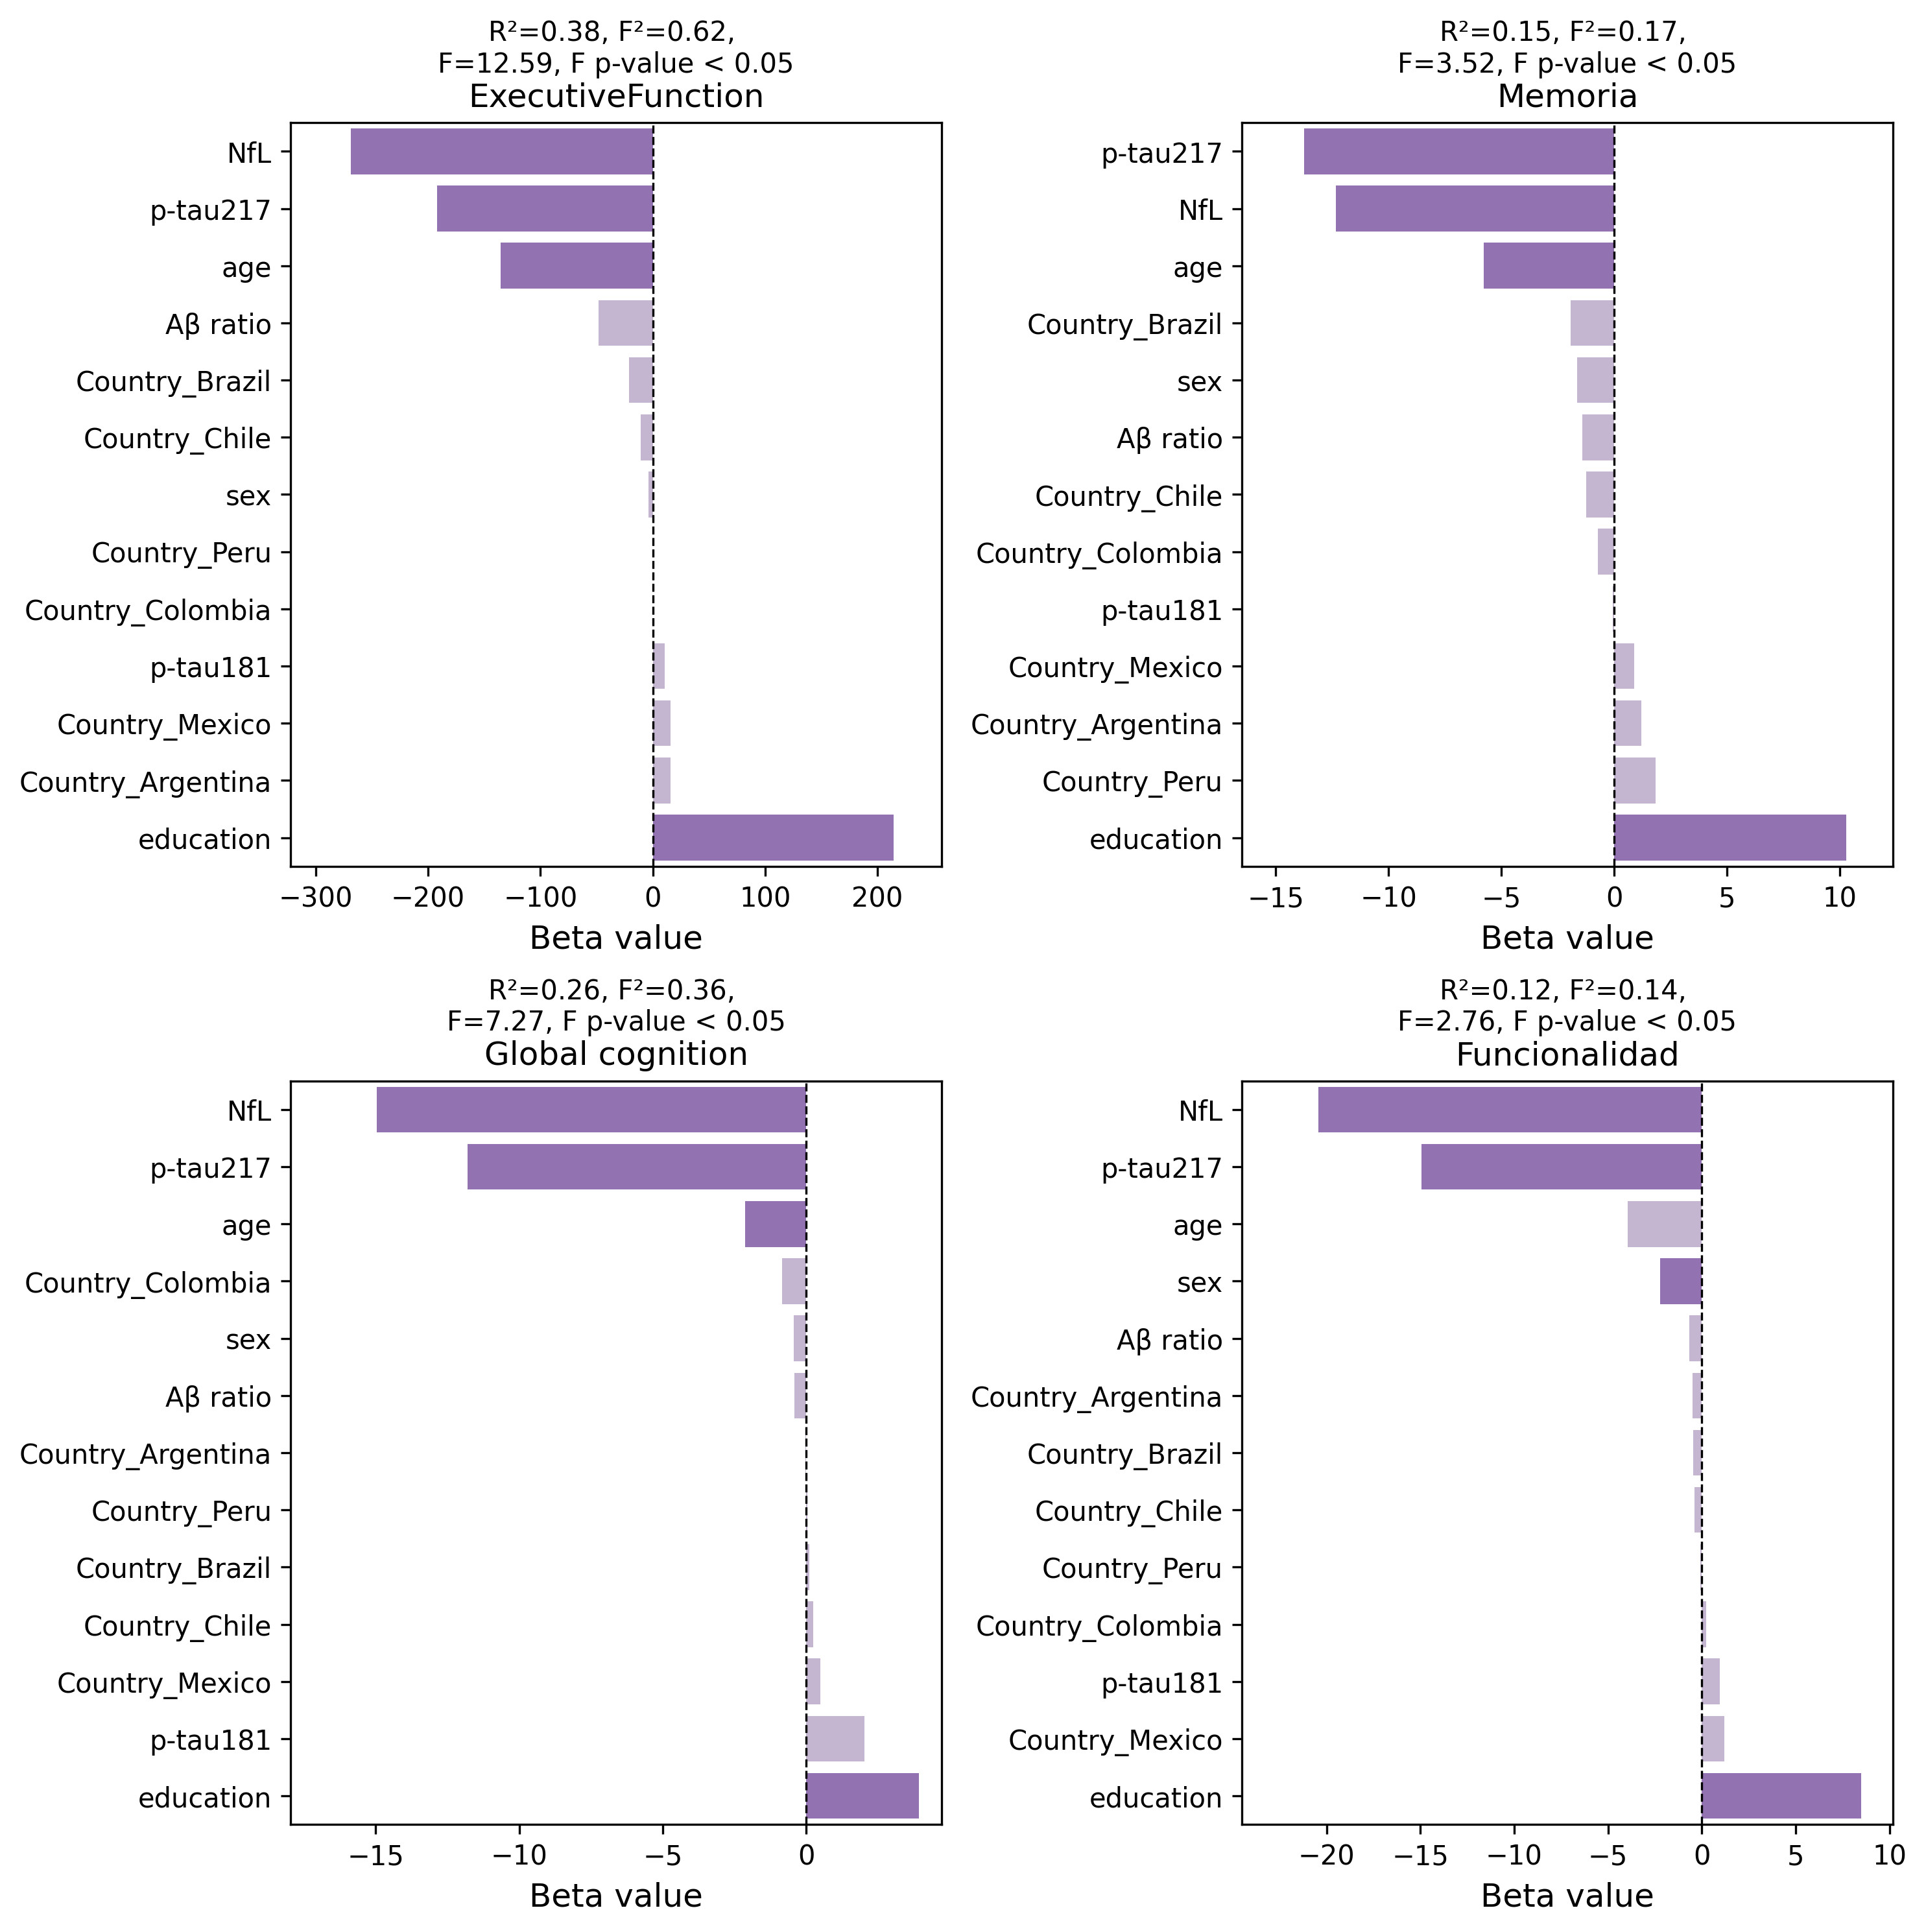

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=300) # Changed subplot layout to 2x2
axes = axes.flatten()

# Define interest_vars outside the loop, including the additional variables
interest_vars_analysis_adjusted = ['Aβ ratio', 'NfL', 'p-tau181', 'p-tau217', 'sex', 'age', 'education'] + list(df_all_dummies_adjusted.columns)

#for obj_var in  ['Memoria', 'ExecutiveFunction', 'Global cognition', 'Funcionalidad']:
for i, obj_var in enumerate(['ExecutiveFunction', 'Memoria',  'Global cognition', 'Funcionalidad']):
    X_  = df_all_adjusted[interest_vars_analysis_adjusted]
    y   = df_all_adjusted[obj_var]

    from skopt import BayesSearchCV

    X_train, X_test, y_train, y_test = train_test_split(X_, y, train_size=0.80, test_size=.20, random_state=0)

    scaler = MinMaxScaler(feature_range=(0.05, 0.95))
    scaling_data = scaler.fit_transform(X_train)
    X_s = pd.DataFrame(scaling_data, columns= X_train.columns, index = X_train.index)
    X_train =  X_s.copy()

    scaler = MinMaxScaler(feature_range=(0.05, 0.95))
    scaling_data = scaler.fit_transform(X_test)
    X_s = pd.DataFrame(scaling_data, columns= X_test.columns, index = X_test.index)
    X_test =  X_s.copy()



    opt_Ridge = BayesSearchCV(
        Ridge(),
        {
            'alpha': ( 0.0001, 0.01, 0.001),
            'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
            'max_iter': (1000, 10000, 100000, 1000000),
            #'tol:' : (1e-6, 1e-3, 1e+1),
            #'n_estimators': (100, 1000),

        },
        n_iter=10,
        cv=3
    )

    opt_Ridge.fit(X_train, y_train)

    print('Ridge')
    print("val. score: %s" % opt_Ridge.best_score_)
    print("test score: %s" % opt_Ridge.score(X_test, y_test))
    print("best parameters: %s" % str(opt_Ridge.best_params_))
    print('---------------------------------------------\n')


    [coef_df_Ridge, r_squared_Ridge, results_labels_df_Ridge] = Regression_Linear(X_, y, 1, 10, n_splits = 5, model = Ridge(**opt_Ridge.best_params_))
    coef_df_Ridge

    coef_df_Ridge.to_excel("Regresion_CN_AD_FTD_adjusted_" + obj_var + ".xlsx")

    df_betas = coef_df_Ridge.iloc[1:, [0, 3]].sort_values(by='Estimate mean', ascending=True)  # Selecting only 'Estimate mean' column and sorting by 'Estimate mean'

    df_betas['label'] = df_betas.index


    ax = axes[i]
    sns.barplot(x='Estimate mean', y='label', data=df_betas, orient='h', ax=ax, palette=np.where(df_betas['p value'] < 0.05, '#9467bd', '#c5b0d5')) # Color based on significance (purple tones)


    ax.set_xlabel('Beta value', fontsize=12)
    ax.set_ylabel('')
    ax.set_title(obj_var, fontsize=12)
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        pass


    # Add a vertical line at x=0
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)

    # Adjust x-axis limits to accommodate labels and zero line
    min_beta = df_betas['Estimate mean'].min()
    max_beta = df_betas['Estimate mean'].max()
    ax.set_xlim(min(min_beta, 0) - abs(min_beta)*0.2, max(max_beta, 0) + abs(max_beta)*0.2)


    # Add R², F², and F values at the top of each subplot
    f_pvalue_text = f"F p-value < 0.05" if coef_df_Ridge.loc['_intercept', 'F-p_value'] < 0.05 else f"F p-value >= 0.05"
    ax.text(0.5, 1.1, f"R²={r_squared_Ridge:.2f}, F²={coef_df_Ridge.loc['_intercept', 'F2']:.2f}, \nF={coef_df_Ridge.loc['_intercept', 'F']:.2f}, {f_pvalue_text}",
            ha='center', va='center', fontsize=10, transform=ax.transAxes)


    print(obj_var, df_betas.iloc[0,0])

# Remove any unused subplots
for j in range(len(['Memoria', 'ExecutiveFunction', 'Global cognition', 'Funcionalidad']), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout, save and show the figure
plt.tight_layout()
plt.savefig("Regression_CN_AD_matched_adjusted.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
# @title CN + FTD matcheados covariate country, age, sex, ed
df

df2= pd.read_csv('matched_data_with_ids_CN_FTD.csv')

# Identify columns to drop from df2 before merging to prevent suffix issues
# Assuming 'record_id' is the only column that should be in both dataframes and used for merging
cols_to_drop_from_df2 = ['diagnosis', 'age', 'sex', 'education', 'distance', 'weights', 'subclass'] # These columns have _y suffix

df_matched_ftd = pd.merge(df, df2.drop(columns=cols_to_drop_from_df2), on='record_id', how='inner')

df_matched_ftd['diagnosis'].value_counts()

df = df_matched_ftd

df.diagnosis.value_counts()



,count
diagnosis,
FTD,57
CN,56


In [ ]:
df_all_adjusted = df.copy() # Create a new dataframe for the adjusted analysis

biomarker_vars = ['Aβ ratio', 'NfL', 'p-tau181', 'p-tau217']
# Add sex, age, and education to the list of variables
additional_vars = ['sex', 'age', 'education']

df_all_adjusted[biomarker_vars] = df_all_adjusted[biomarker_vars].astype(float)
# Ensure additional variables are also in float format if necessary, or handle appropriately
df_all_adjusted[additional_vars] = df_all_adjusted[additional_vars].astype(float)


# Include 'Country' in the list of interest variables and create dummy variables
df_all_dummies_adjusted = pd.get_dummies(df_all_adjusted['Country'], prefix='Country')

# Concatenate the original DataFrame (excluding the original 'Country' column) with the dummy variables
df_all_adjusted = pd.concat([df_all_adjusted.drop(columns=['Country']), df_all_dummies_adjusted], axis=1)

# Combine biomarker variables, additional variables, and country dummy variables into interest_vars
interest_vars_adjusted = biomarker_vars + additional_vars + list(df_all_dummies_adjusted.columns)

df_all_adjusted.dropna(inplace=True, subset= interest_vars_adjusted + ['ExecutiveFunction', 'Memoria',  'Global cognition', 'Funcionalidad'])

df_all_adjusted.reset_index(inplace=True, drop = True)
df_all_adjusted.shape

(113, 260)

Ridge
val. score: 0.14483678718825435
test score: -0.35290664028289753
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 1000), ('solver', 'lsqr')])
---------------------------------------------

ExecutiveFunction -236.3553111726158
Ridge
val. score: -0.3317159256775251
test score: -0.11788142289063419
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 1000), ('solver', 'sparse_cg')])
---------------------------------------------

Memoria -14.284402863183846
Ridge
val. score: -0.55119279639546
test score: 0.010516366485494921
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 100000), ('solver', 'sag')])
---------------------------------------------

Global cognition -10.262605647285945
Ridge
val. score: -0.5467337579812409
test score: -0.16251560206680415
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 1000), ('solver', 'sag')])
---------------------------------------------

Funcionalidad -16.422703839992273


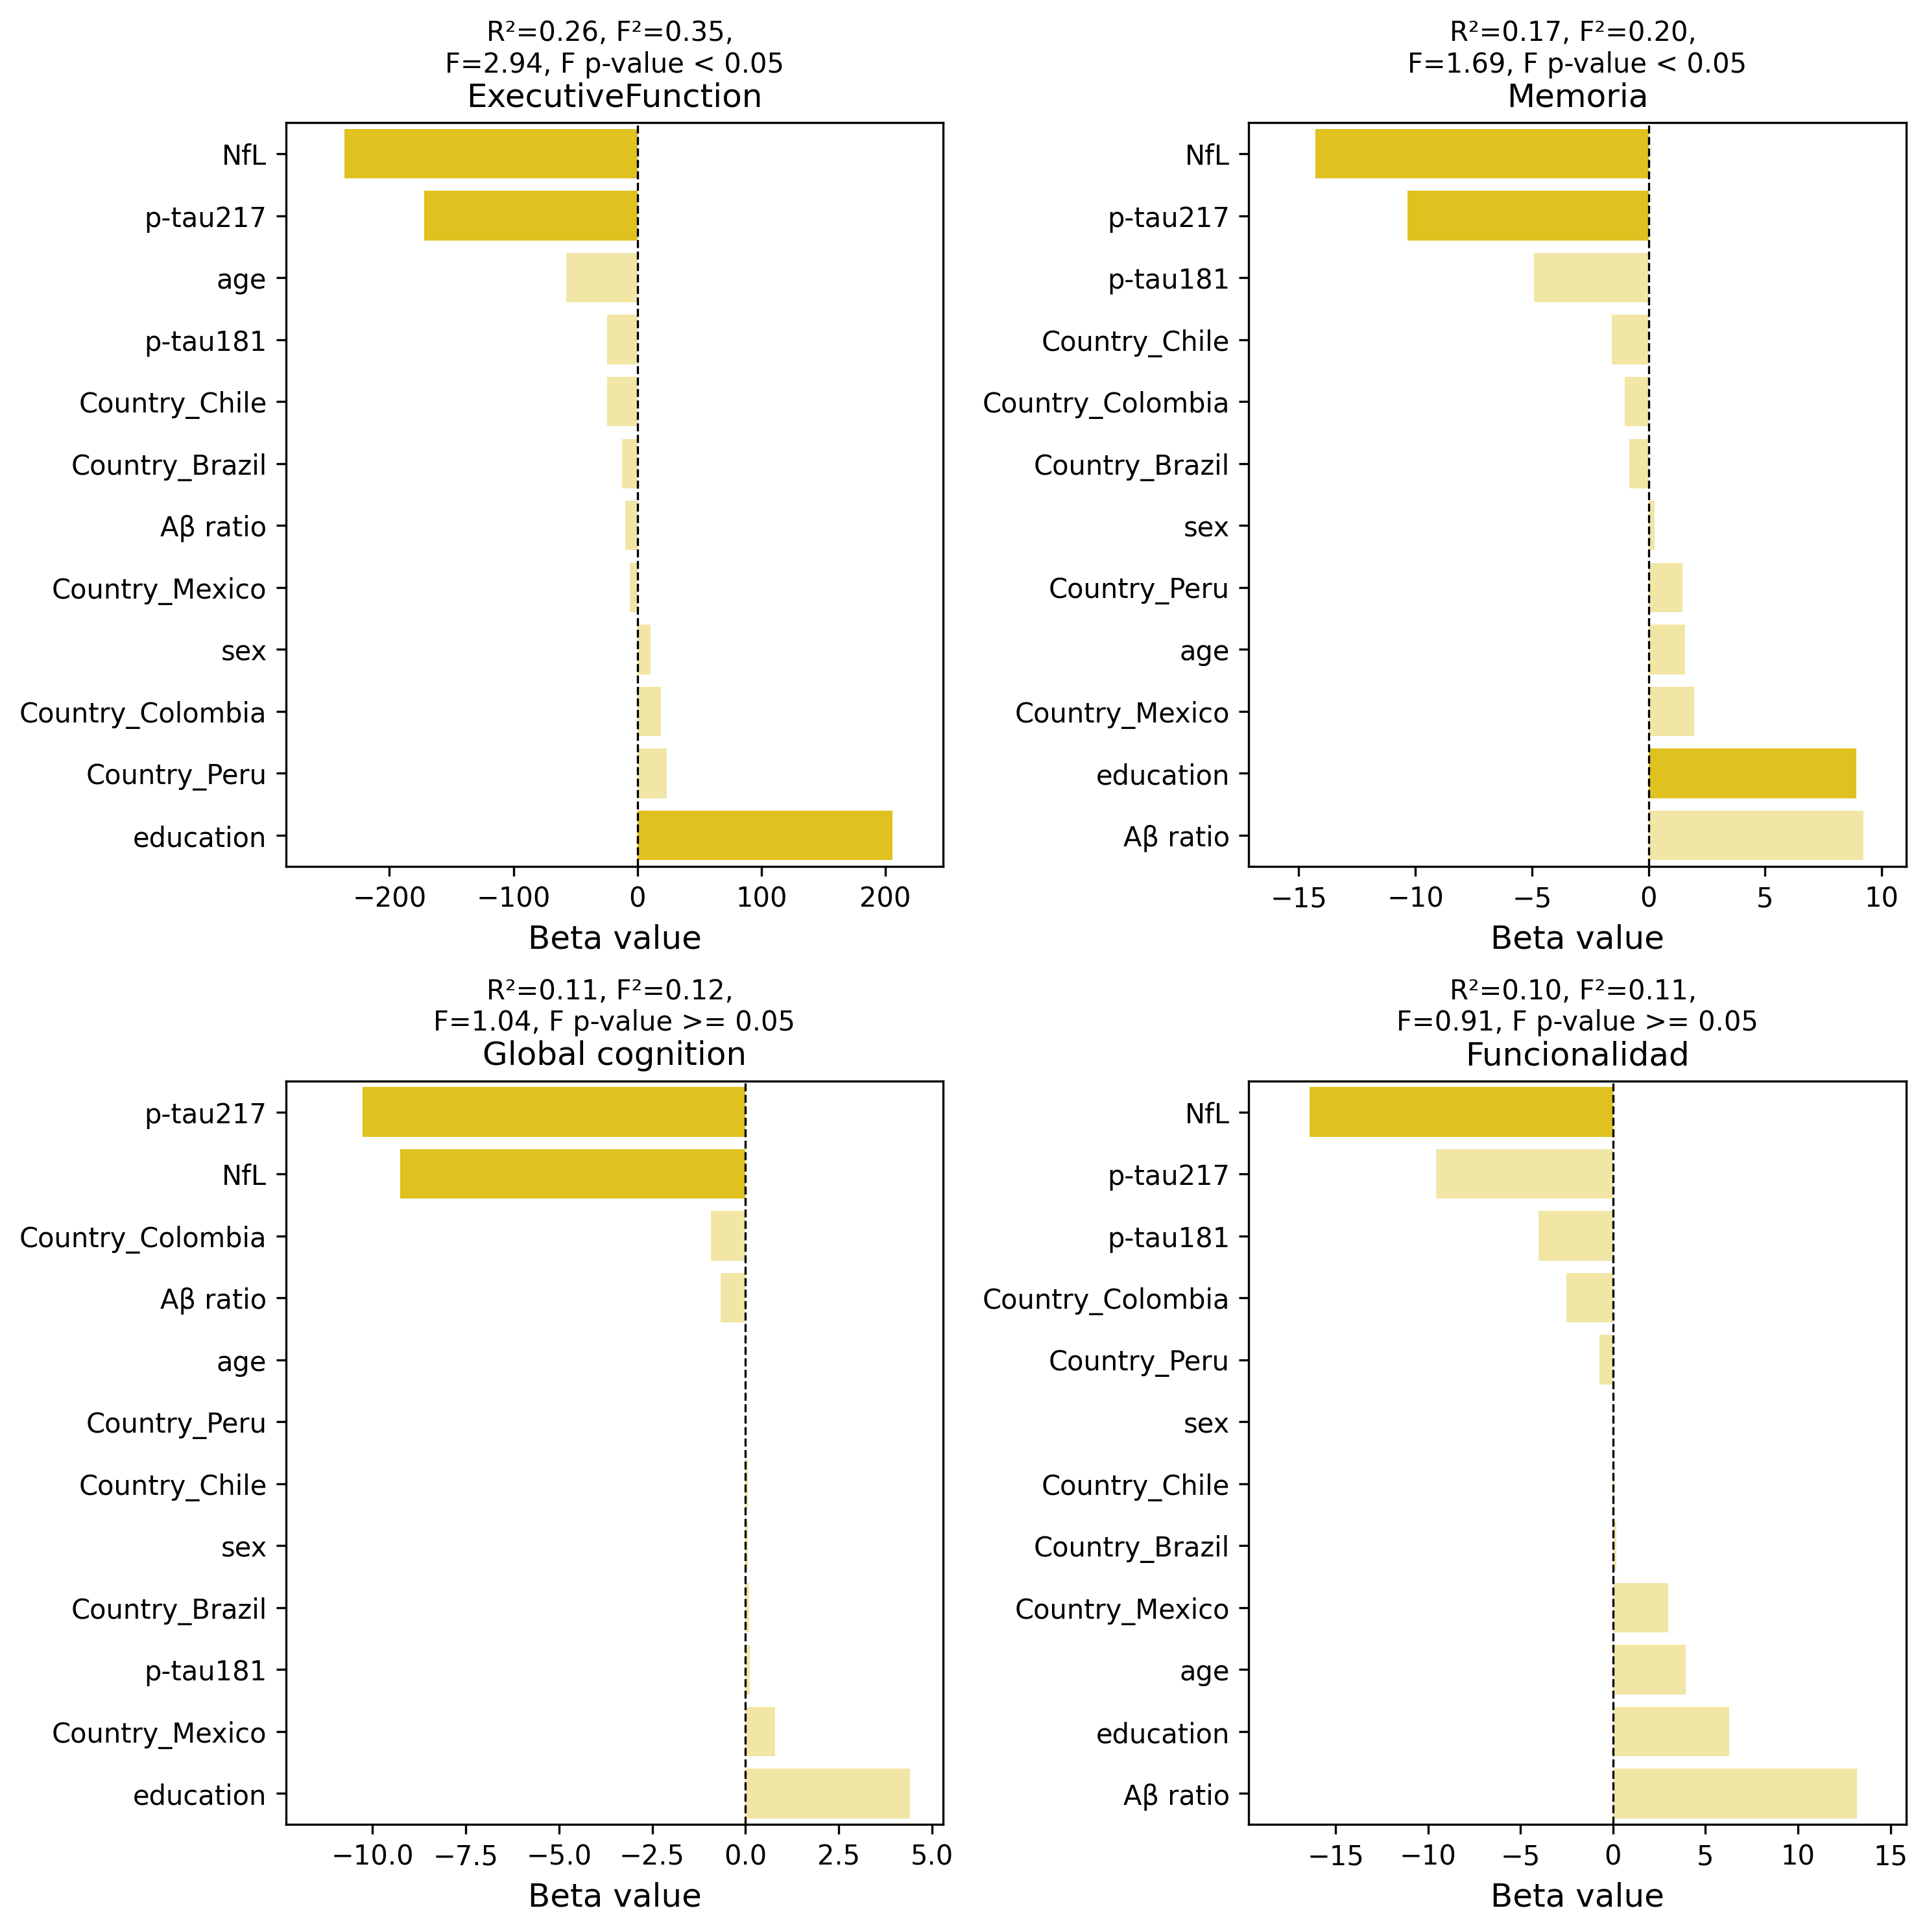

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=300) # Changed subplot layout to 2x2
axes = axes.flatten()

# Define interest_vars outside the loop, including the additional variables
interest_vars_analysis_adjusted = ['Aβ ratio', 'NfL', 'p-tau181', 'p-tau217', 'sex', 'age', 'education'] + list(df_all_dummies_adjusted.columns)

#for obj_var in  ['Memoria', 'ExecutiveFunction', 'Global cognition', 'Funcionalidad']:
for i, obj_var in enumerate(['ExecutiveFunction', 'Memoria',  'Global cognition', 'Funcionalidad']):
    X_  = df_all_adjusted[interest_vars_analysis_adjusted]
    y   = df_all_adjusted[obj_var]

    from skopt import BayesSearchCV

    X_train, X_test, y_train, y_test = train_test_split(X_, y, train_size=0.80, test_size=.20, random_state=0)

    scaler = MinMaxScaler(feature_range=(0.05, 0.95))
    scaling_data = scaler.fit_transform(X_train)
    X_s = pd.DataFrame(scaling_data, columns= X_train.columns, index = X_train.index)
    X_train =  X_s.copy()

    scaler = MinMaxScaler(feature_range=(0.05, 0.95))
    scaling_data = scaler.fit_transform(X_test)
    X_s = pd.DataFrame(scaling_data, columns= X_test.columns, index = X_test.index)
    X_test =  X_s.copy()



    opt_Ridge = BayesSearchCV(
        Ridge(),
        {
            'alpha': ( 0.0001, 0.01, 0.001),
            'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
            'max_iter': (1000, 10000, 100000, 1000000),
            #'tol:' : (1e-6, 1e-3, 1e+1),
            #'n_estimators': (100, 1000),

        },
        n_iter=10,
        cv=3
    )

    opt_Ridge.fit(X_train, y_train)

    print('Ridge')
    print("val. score: %s" % opt_Ridge.best_score_)
    print("test score: %s" % opt_Ridge.score(X_test, y_test))
    print("best parameters: %s" % str(opt_Ridge.best_params_))
    print('---------------------------------------------\n')


    [coef_df_Ridge, r_squared_Ridge, results_labels_df_Ridge] = Regression_Linear(X_, y, 1, 10, n_splits = 5, model = Ridge(**opt_Ridge.best_params_))
    coef_df_Ridge

    coef_df_Ridge.to_excel("Regresion_CN_FTD_matched_adjusted_" + obj_var + ".xlsx")

    df_betas = coef_df_Ridge.iloc[1:, [0, 3]].sort_values(by='Estimate mean', ascending=True)  # Selecting only 'Estimate mean' column and sorting by 'Estimate mean'

    df_betas['label'] = df_betas.index


    ax = axes[i]
    sns.barplot(x='Estimate mean', y='label', data=df_betas, orient='h', ax=ax, palette=np.where(df_betas['p value'] < 0.05, '#FFD700', '#FFEE99')) # Color based on significance (purple tones)


    ax.set_xlabel('Beta value', fontsize=12)
    ax.set_ylabel('')
    ax.set_title(obj_var, fontsize=12)
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        pass


    # Add a vertical line at x=0
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)

    # Adjust x-axis limits to accommodate labels and zero line
    min_beta = df_betas['Estimate mean'].min()
    max_beta = df_betas['Estimate mean'].max()
    ax.set_xlim(min(min_beta, 0) - abs(min_beta)*0.2, max(max_beta, 0) + abs(max_beta)*0.2)


    # Add R², F², and F values at the top of each subplot
    f_pvalue_text = f"F p-value < 0.05" if coef_df_Ridge.loc['_intercept', 'F-p_value'] < 0.05 else f"F p-value >= 0.05"
    ax.text(0.5, 1.1, f"R²={r_squared_Ridge:.2f}, F²={coef_df_Ridge.loc['_intercept', 'F2']:.2f}, \nF={coef_df_Ridge.loc['_intercept', 'F']:.2f}, {f_pvalue_text}",
            ha='center', va='center', fontsize=10, transform=ax.transAxes)


    print(obj_var, df_betas.iloc[0,0])

# Remove any unused subplots
for j in range(len(['Memoria', 'ExecutiveFunction', 'Global cognition', 'Funcionalidad']), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout, save and show the figure
plt.tight_layout()
plt.savefig("Regression_CN_FTD_matched_adjusted.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
# @title Cn + AD + FTD covariating countries, age, sex, education

df

df2= pd.read_excel('merged_matched_unique.xlsx')


df_matched_ftd = pd.merge(df, df2, on='record_id', how='inner')

df_matched_ftd['diagnosis'].value_counts()

df = df_matched_ftd

df.diagnosis.value_counts()


,count
diagnosis,
CN,93
AD,85
FTD,57


In [ ]:
df_all_adjusted = df.copy() # Create a new dataframe for the adjusted analysis

biomarker_vars = ['Aβ ratio', 'NfL', 'p-tau181', 'p-tau217']
# Add sex, age, and education to the list of variables
additional_vars = ['sex', 'age', 'education']

df_all_adjusted[biomarker_vars] = df_all_adjusted[biomarker_vars].astype(float)
# Ensure additional variables are also in float format if necessary, or handle appropriately
df_all_adjusted[additional_vars] = df_all_adjusted[additional_vars].astype(float)


# Include 'Country' in the list of interest variables and create dummy variables
df_all_dummies_adjusted = pd.get_dummies(df_all_adjusted['Country'], prefix='Country')

# Concatenate the original DataFrame (excluding the original 'Country' column) with the dummy variables
df_all_adjusted = pd.concat([df_all_adjusted.drop(columns=['Country']), df_all_dummies_adjusted], axis=1)

# Combine biomarker variables, additional variables, and country dummy variables into interest_vars
interest_vars_adjusted = biomarker_vars + additional_vars + list(df_all_dummies_adjusted.columns)

df_all_adjusted.dropna(inplace=True, subset= interest_vars_adjusted + ['ExecutiveFunction', 'Memoria',  'Global cognition', 'Funcionalidad'])

df_all_adjusted.reset_index(inplace=True, drop = True)
df_all_adjusted.shape

(235, 262)

Ridge
val. score: 0.29174659779138773
test score: 0.27553332766236716
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 100000), ('solver', 'lsqr')])
---------------------------------------------

ExecutiveFunction -187.8707240531015
Ridge
val. score: 0.1852796784905997
test score: 0.16941192168030483
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 1000), ('solver', 'sparse_cg')])
---------------------------------------------

Memoria -14.594248700475651
Ridge
val. score: 0.2627019058962578
test score: 0.40467292874032945
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 1000000), ('solver', 'saga')])
---------------------------------------------

Global cognition -10.621257331328582
Ridge
val. score: 0.11741314080553271
test score: -0.026227676727696103
best parameters: OrderedDict([('alpha', 0.01), ('max_iter', 10000), ('solver', 'sparse_cg')])
---------------------------------------------

Funcionalidad -12.307468717058018


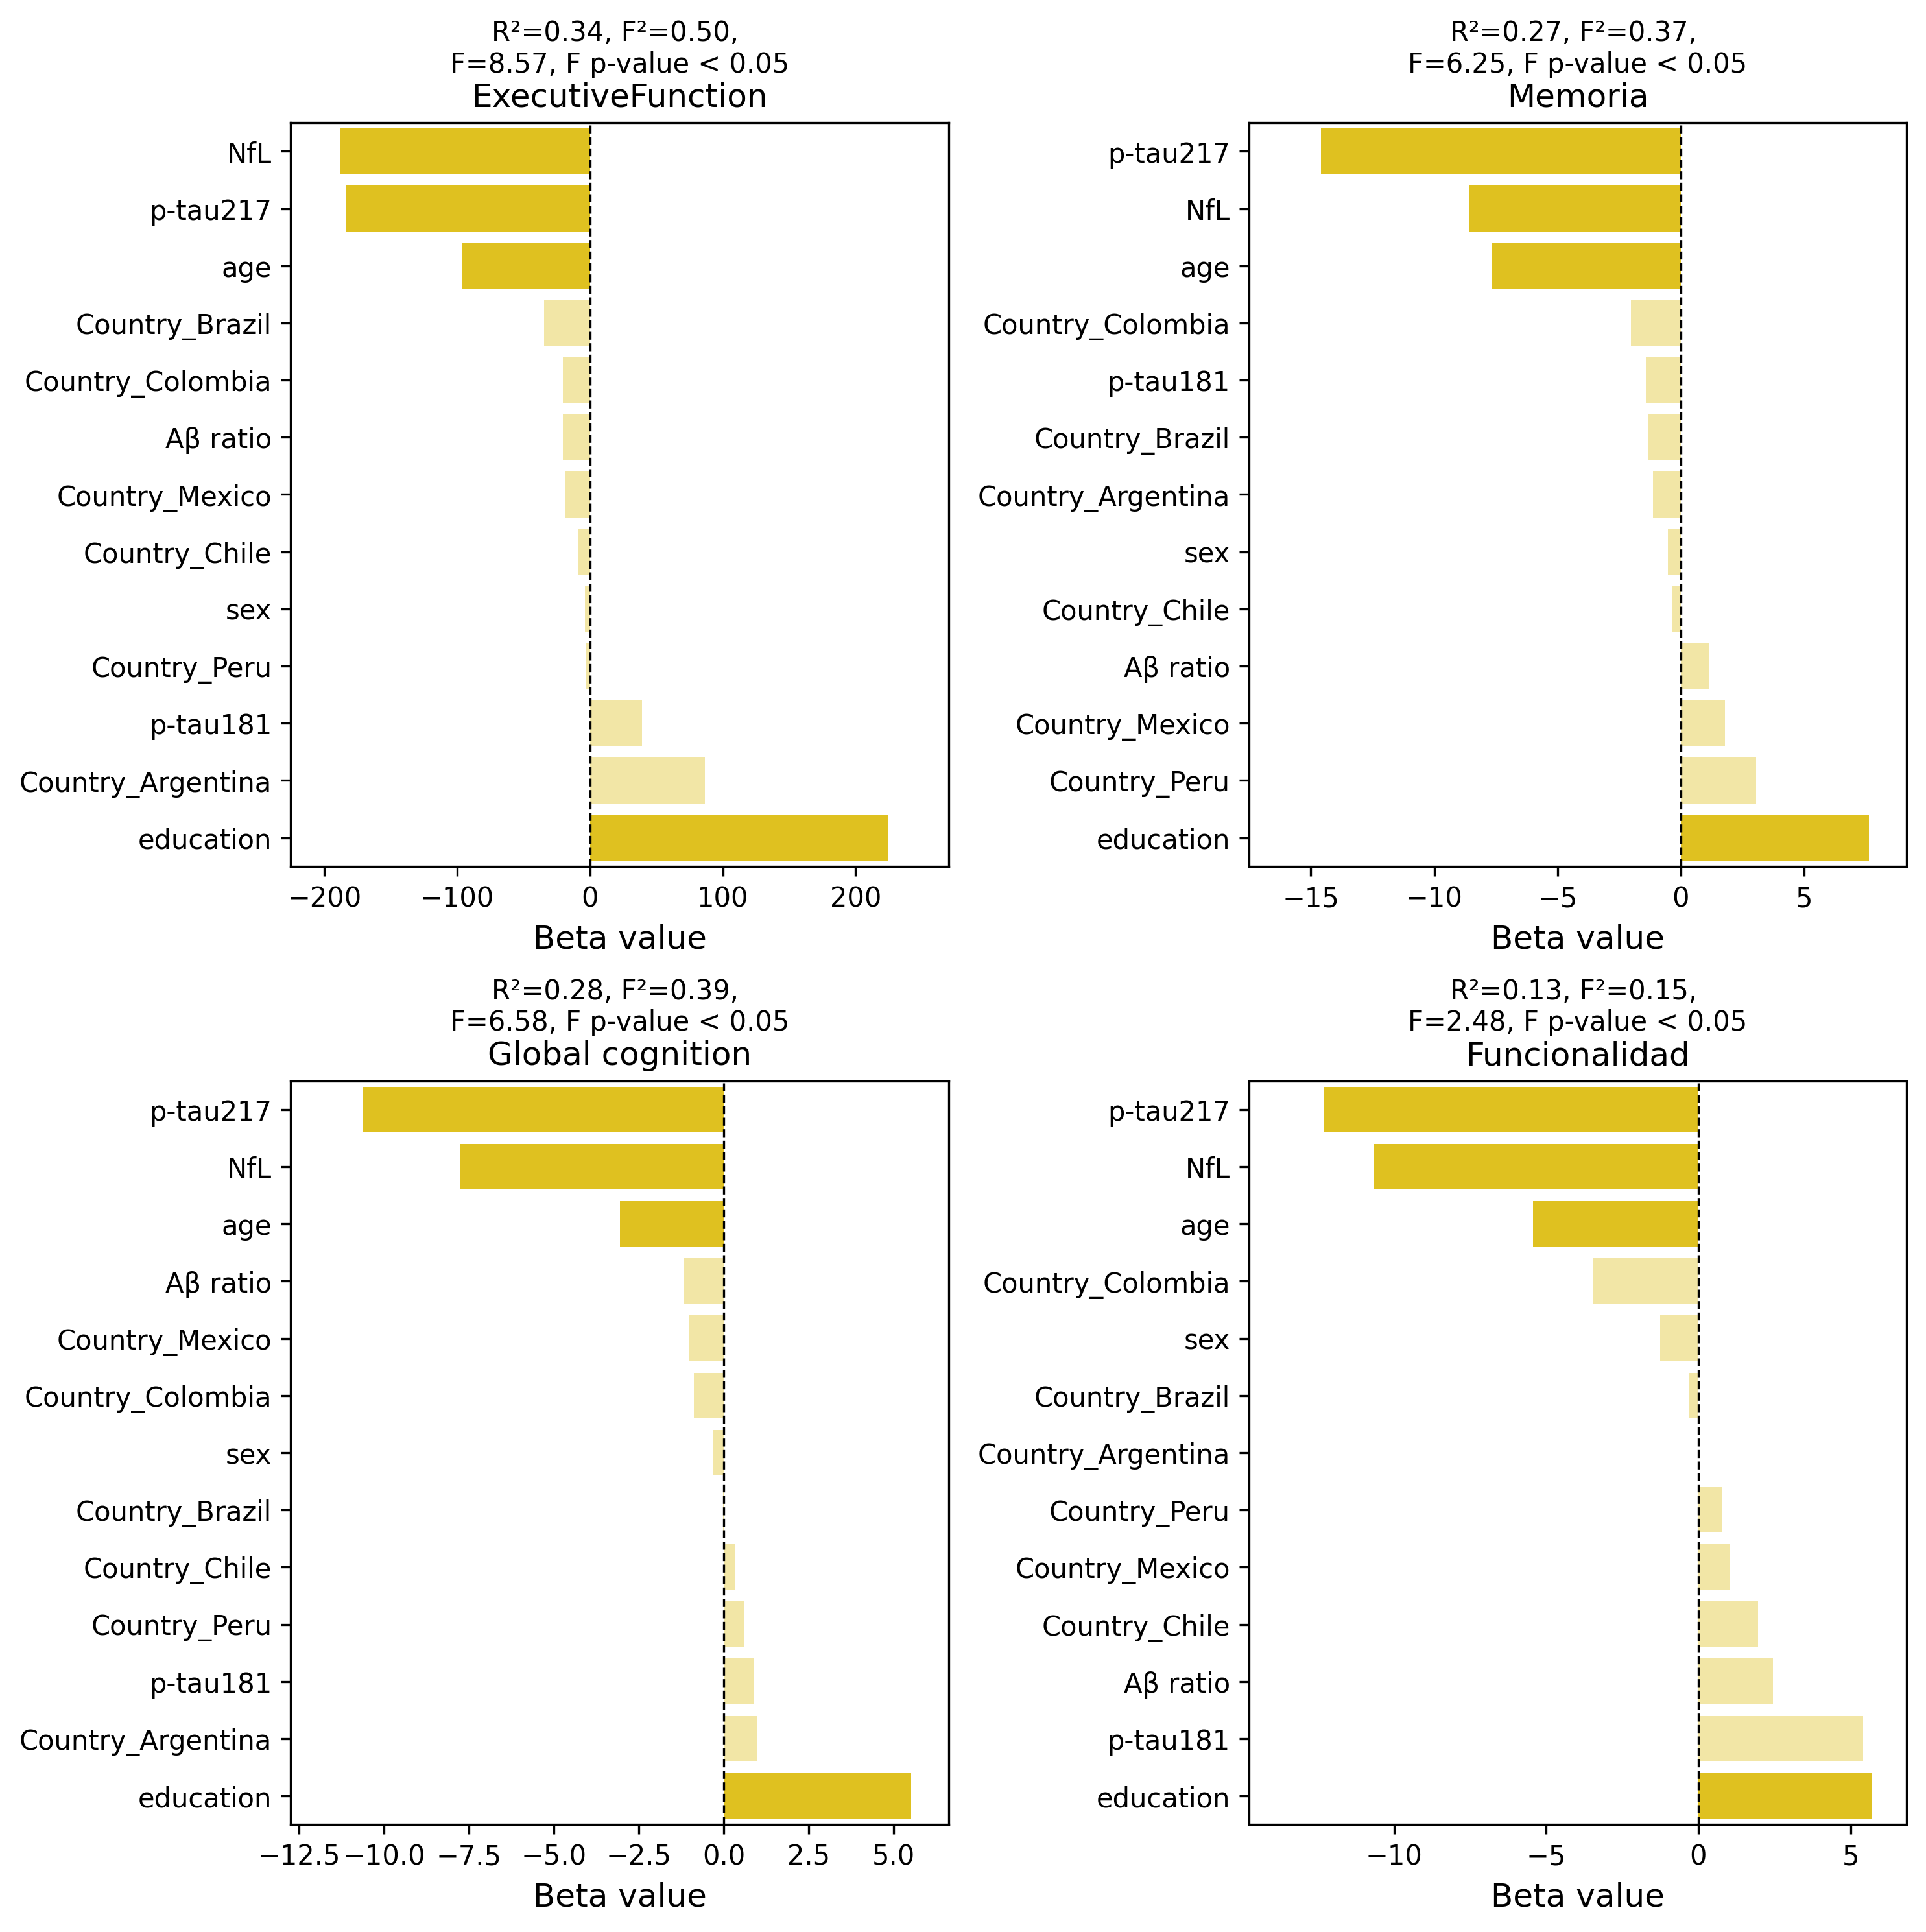

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=300) # Changed subplot layout to 2x2
axes = axes.flatten()

# Define interest_vars outside the loop, including the additional variables
interest_vars_analysis_adjusted = ['Aβ ratio', 'NfL', 'p-tau181', 'p-tau217', 'sex', 'age', 'education'] + list(df_all_dummies_adjusted.columns)

#for obj_var in  ['Memoria', 'ExecutiveFunction', 'Global cognition', 'Funcionalidad']:
for i, obj_var in enumerate(['ExecutiveFunction', 'Memoria',  'Global cognition', 'Funcionalidad']):
    X_  = df_all_adjusted[interest_vars_analysis_adjusted]
    y   = df_all_adjusted[obj_var]

    from skopt import BayesSearchCV

    X_train, X_test, y_train, y_test = train_test_split(X_, y, train_size=0.80, test_size=.20, random_state=0)

    scaler = MinMaxScaler(feature_range=(0.05, 0.95))
    scaling_data = scaler.fit_transform(X_train)
    X_s = pd.DataFrame(scaling_data, columns= X_train.columns, index = X_train.index)
    X_train =  X_s.copy()

    scaler = MinMaxScaler(feature_range=(0.05, 0.95))
    scaling_data = scaler.fit_transform(X_test)
    X_s = pd.DataFrame(scaling_data, columns= X_test.columns, index = X_test.index)
    X_test =  X_s.copy()



    opt_Ridge = BayesSearchCV(
        Ridge(),
        {
            'alpha': ( 0.0001, 0.01, 0.001),
            'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
            'max_iter': (1000, 10000, 100000, 1000000),
            #'tol:' : (1e-6, 1e-3, 1e+1),
            #'n_estimators': (100, 1000),

        },
        n_iter=10,
        cv=3
    )

    opt_Ridge.fit(X_train, y_train)

    print('Ridge')
    print("val. score: %s" % opt_Ridge.best_score_)
    print("test score: %s" % opt_Ridge.score(X_test, y_test))
    print("best parameters: %s" % str(opt_Ridge.best_params_))
    print('---------------------------------------------\n')


    [coef_df_Ridge, r_squared_Ridge, results_labels_df_Ridge] = Regression_Linear(X_, y, 1, 10, n_splits = 5, model = Ridge(**opt_Ridge.best_params_))
    coef_df_Ridge

    coef_df_Ridge.to_excel("Regresion_CN_AD_FTD_matched_adjusted_" + obj_var + ".xlsx")

    df_betas = coef_df_Ridge.iloc[1:, [0, 3]].sort_values(by='Estimate mean', ascending=True)  # Selecting only 'Estimate mean' column and sorting by 'Estimate mean'

    df_betas['label'] = df_betas.index


    ax = axes[i]
    sns.barplot(x='Estimate mean', y='label', data=df_betas, orient='h', ax=ax, palette=np.where(df_betas['p value'] < 0.05, '#FFD700', '#FFEE99')) # Color based on significance (purple tones)


    ax.set_xlabel('Beta value', fontsize=12)
    ax.set_ylabel('')
    ax.set_title(obj_var, fontsize=12)
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        pass


    # Add a vertical line at x=0
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)

    # Adjust x-axis limits to accommodate labels and zero line
    min_beta = df_betas['Estimate mean'].min()
    max_beta = df_betas['Estimate mean'].max()
    ax.set_xlim(min(min_beta, 0) - abs(min_beta)*0.2, max(max_beta, 0) + abs(max_beta)*0.2)


    # Add R², F², and F values at the top of each subplot
    f_pvalue_text = f"F p-value < 0.05" if coef_df_Ridge.loc['_intercept', 'F-p_value'] < 0.05 else f"F p-value >= 0.05"
    ax.text(0.5, 1.1, f"R²={r_squared_Ridge:.2f}, F²={coef_df_Ridge.loc['_intercept', 'F2']:.2f}, \nF={coef_df_Ridge.loc['_intercept', 'F']:.2f}, {f_pvalue_text}",
            ha='center', va='center', fontsize=10, transform=ax.transAxes)


    print(obj_var, df_betas.iloc[0,0])

# Remove any unused subplots
for j in range(len(['Memoria', 'ExecutiveFunction', 'Global cognition', 'Funcionalidad']), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout, save and show the figure
plt.tight_layout()
plt.savefig("Regression_CN_AD_FTD_matched_adjusted.pdf", format="pdf", bbox_inches="tight")
plt.show()